<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg" align="left" width="45%">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Trabajo Final de Master</p>
<p style="margin: 0; text-align:right;">2024-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Notebook No. 2 - Estudiante: Carlos Alberto Agudelo Moncada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
    <strong>Resumen de la Implementación:</strong> 


Este notebook desarrolla un análisis predictivo y de dimensionamiento de capacidad para estimar la cantidad de kioskos requeridos en función de la demanda de órdenes. El objetivo principal es responder preguntas de negocio relacionadas con la capacidad necesaria para atender órdenes provenientes del canal Kiosk, órdenes combinadas de Kiosk + In-Store Cashier y escenarios de migración total donde todas las órdenes, independientemente del canal original, serían atendidas por kioskos.

El análisis inicia con la carga, limpieza y exploración del dataset, incluyendo revisión de nulos, duplicados, variables temporales, distribución de canales, comportamiento horario de la demanda, tiempos de atención y detección de outliers. Posteriormente, se construyen variables derivadas y datasets agregados por fecha, hora y canal para analizar la demanda horaria y la carga operativa.

Las principales preguntas de negocio abordadas son:

1. ¿Cuántos kioskos se requieren para satisfacer las órdenes actuales del canal Kiosk?
2. ¿Cuántos kioskos se requieren para atender las órdenes actuales de Kiosk + In-Store Cashier?
3. ¿Qué ocurre si todas las órdenes de todos los canales se atienden mediante kioskos?
4. ¿Cómo cambia el requerimiento de kioskos ante escenarios de crecimiento de demanda?
5. ¿Cuántos kioskos se necesitarían en una predicción calendarizada futura, por ejemplo para enero de 2026?

Para responder estas preguntas se aplica un enfoque híbrido que combina Machine Learning con un modelo determinístico de capacidad operativa. Primero se entrenó un modelo de regresión para predecir el tiempo de atención de una orden, usando como variable objetivo `fulfillment_time_min`. Para este modelo se compararon técnicas como Linear Regression, Random Forest Regressor y Gradient Boosting Regressor, siendo Gradient Boosting Regressor el mejor modelo según MAE.

Luego se construye un modelo de predicción de demanda horaria, utilizando como variable objetivo `total_orders`, construida a partir de la agrupación de órdenes por fecha, hora y canal. En este caso se compararon Linear Regression, Poisson Regressor, Random Forest Regressor y Gradient Boosting Regressor. El mejor desempeño fue obtenido por Random Forest Regressor, con alta capacidad para explicar la variabilidad de la demanda horaria.

Adicionalmente, se desarrolló un escenario donde todas las órdenes se simulan como atendidas por kiosko. Para este escenario se utilizaron modelos de demanda agregada y se compararon nuevamente técnicas como Linear Regression, Poisson Regressor, Random Forest Regressor y Gradient Boosting Regressor. El mejor resultado fue obtenido por Gradient Boosting Regressor.

Finalmente, se construyó una extensión de predicción futura calendarizada. Para este caso se entrenó un modelo operativo simple basado únicamente en variables disponibles antes de la operación: mes, día de la semana, indicador de fin de semana, hora y canal. Este enfoque permite generar predicciones futuras sin depender de variables agregadas que no se conocerían anticipadamente, como ticket promedio o tamaño promedio del carrito.

</div>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/carlosagudelomoncada/restarurant-order/starbucks_customer_ordering_patterns.csv


# 1. IMPORTS & CONFIGURACIÓN

In [2]:
# =========================================================
# 1. IMPORTS Y CONFIGURACIÓN
# =========================================================

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades
import os
import warnings

# Configuración general
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.4f}'.format)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 2. CARGA DEL DATASET

In [3]:
# =========================================================
# 2. CARGA DEL DATASET
# =========================================================

# Ruta del archivo en Kaggle
file_path = "/kaggle/input/datasets/carlosagudelomoncada/restarurant-order/starbucks_customer_ordering_patterns.csv"

# Valida si el archivo existe en la ruta definida
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset cargado correctamente.")
else:
    print("No se encontró el archivo en la ruta especificada.")
    print("Archivos disponibles en /kaggle/input:")
    
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for filename in filenames:
            print(os.path.join(dirname, filename))

Dataset cargado correctamente.


# 3. INSPECCIÓN INICIAL DEL DATASET

In [4]:
# =========================================================
# 3. INSPECCIÓN INICIAL DEL DATASET
# =========================================================

# Dimensiones del dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

print("\nPrimeras 5 filas:")
display(df.head())

print("\nÚltimas 5 filas:")
display(df.tail())

print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo_dato"))

print("\nInformación general:")
df.info()

Dimensiones del dataset:
Filas: 100,000
Columnas: 20

Primeras 5 filas:


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.4800,8.2000,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.5200,5.4000,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.3200,4.9000,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.5500,3.5000,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.2400,4.1000,Frappuccino,False,False,3



Últimas 5 filas:


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
99995,CUST_09857,ORD_00099996,2025-09-17,17:08,Wed,Mobile App,STR_016,Suburban,Northeast,45-54,Non-binary,True,4,0,15.1800,3.2000,Frappuccino,False,True,4
99996,CUST_09970,ORD_00099997,2024-08-03,08:07,Sat,Drive-Thru,STR_409,Rural,Southwest,35-44,Prefer not to say,True,5,2,16.7100,5.5000,Espresso,False,False,3
99997,CUST_04417,ORD_00099998,2025-01-11,16:05,Sat,In-Store Cashier,STR_191,Suburban,Northeast,55+,Female,False,3,0,9.1200,3.3000,Espresso,False,False,1
99998,CUST_07997,ORD_00099999,2025-10-23,18:32,Thu,Mobile App,STR_210,Rural,Southeast,18-24,Female,True,5,1,18.0200,1.9000,Other,False,False,2
99999,CUST_07625,ORD_00100000,2024-09-01,13:18,Sun,In-Store Cashier,STR_217,Rural,West,55+,Female,False,1,0,5.2900,3.1000,Brewed Coffee,True,False,5



Columnas disponibles:
['customer_id', 'order_id', 'order_date', 'order_time', 'day_of_week', 'order_channel', 'store_id', 'store_location_type', 'region', 'customer_age_group', 'customer_gender', 'is_rewards_member', 'cart_size', 'num_customizations', 'total_spend', 'fulfillment_time_min', 'drink_category', 'has_food_item', 'order_ahead', 'customer_satisfaction']

Tipos de datos:


,tipo_dato
customer_id,object
order_id,object
order_date,object
order_time,object
day_of_week,object
order_channel,object
store_id,object
store_location_type,object
region,object
customer_age_group,object



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   order_id               100000 non-null  object 
 2   order_date             100000 non-null  object 
 3   order_time             100000 non-null  object 
 4   day_of_week            100000 non-null  object 
 5   order_channel          100000 non-null  object 
 6   store_id               100000 non-null  object 
 7   store_location_type    100000 non-null  object 
 8   region                 100000 non-null  object 
 9   customer_age_group     100000 non-null  object 
 10  customer_gender        100000 non-null  object 
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend    

<div class="alert alert-block alert-info">
    <strong>Observaciones iniciales:</strong> 
    
Filas: 100,000.

Columnas: 20.

No se observan nulos.

order_date y order_time están como object, por lo tanto luego se convertiran a datetime.

fulfillment_time_min existe y será clave para el modelo de duración/capacidad.

order_channel existe y será clave para los escenarios Kiosk y Kiosk + In-Store Cashier.
</div>

# 4. REVISIÓN DE NULOS, DUPLICADOS & VALORES ÚNICOS

In [5]:
# =========================================================
# 4. REVISIÓN DE NULOS, DUPLICADOS Y VALORES ÚNICOS
# =========================================================

# ---------------------------------------------------------
# 4.1 Revisión de valores nulos
# ---------------------------------------------------------

nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="nulos", ascending=False)

print("Valores nulos por variable:")
display(nulos)

# ---------------------------------------------------------
# 4.2 Revisión de registros duplicados completos
# ---------------------------------------------------------

duplicados_completos = df.duplicated().sum()

print("\nRegistros duplicados completos:")
print(f"{duplicados_completos:,}")

# ---------------------------------------------------------
# 4.3 Revisión de duplicados por order_id
# ---------------------------------------------------------

duplicados_order_id = df["order_id"].duplicated().sum()

print("\norder_id duplicados:")
print(f"{duplicados_order_id:,}")

# ---------------------------------------------------------
# 4.4 Cantidad de valores únicos por variable
# ---------------------------------------------------------

valores_unicos = pd.DataFrame({
    "valores_unicos": df.nunique(),
    "tipo_dato": df.dtypes
}).sort_values(by="valores_unicos", ascending=False)

print("\nValores únicos por variable:")
display(valores_unicos)

# ---------------------------------------------------------
# 4.5 Revisión específica de variables categóricas principales
# ---------------------------------------------------------

categorical_cols = [
    "day_of_week",
    "order_channel",
    "store_location_type",
    "region",
    "customer_age_group",
    "customer_gender",
    "drink_category"
]

for col in categorical_cols:
    print("\n" + "="*60)
    print(f"Distribución de la variable: {col}")
    print("="*60)
    display(df[col].value_counts(dropna=False).to_frame("conteo"))
    display((df[col].value_counts(normalize=True, dropna=False) * 100).to_frame("porcentaje"))

Valores nulos por variable:


,nulos,porcentaje_nulos
customer_id,0,0.0000
order_id,0,0.0000
order_date,0,0.0000
order_time,0,0.0000
day_of_week,0,0.0000
order_channel,0,0.0000
store_id,0,0.0000
store_location_type,0,0.0000
region,0,0.0000
customer_age_group,0,0.0000



Registros duplicados completos:
0

order_id duplicados:
0

Valores únicos por variable:


,valores_unicos,tipo_dato
order_id,100000,object
customer_id,14988,object
total_spend,3137,float64
order_time,1440,object
order_date,730,object
store_id,500,object
fulfillment_time_min,102,float64
cart_size,10,int64
num_customizations,9,int64
day_of_week,7,object



Distribución de la variable: day_of_week


...

,conteo
customer_gender,
Female,45306
Male,44767
Non-binary,5058
Prefer not to say,4869


,porcentaje
customer_gender,
Female,45.3060
Male,44.7670
Non-binary,5.0580
Prefer not to say,4.8690



Distribución de la variable: drink_category


,conteo
drink_category,
Refresher,16808
Tea,16723
Espresso,16711
Frappuccino,16670
Other,16547
Brewed Coffee,16541


,porcentaje
drink_category,
Refresher,16.8080
Tea,16.7230
Espresso,16.7110
Frappuccino,16.6700
Other,16.5470
Brewed Coffee,16.5410


<div class="alert alert-block alert-info">
    <strong>Resultados:</strong> 

No hay valores nulos.
No hay registros duplicados completos.
No hay order_id duplicados.
El dataset tiene 500 tiendas.
El dataset cubre 730 fechas diferentes.
El canal Kiosk representa el 7.42% de las órdenes.
El canal In-Store Cashier representa el 22.06% de las órdenes.
El escenario Kiosk + In-Store Cashier representa el 29.48% de las órdenes.

Tenemos 2 escenarios definidos inicialmente
Escenario 1: Kiosk = 7,420 órdenes
Escenario 2: Kiosk + In-Store Cashier = 29,483 órdenes
    
</div>

# 5. ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS

In [6]:
# =========================================================
# 5. ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS
# =========================================================

# ---------------------------------------------------------
# 5.1 Identificación de variables numéricas
# ---------------------------------------------------------

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variables numéricas identificadas:")
print(numeric_cols)

# ---------------------------------------------------------
# 5.2 Estadísticas descriptivas generales
# ---------------------------------------------------------

print("\nEstadísticas descriptivas generales:")
display(df[numeric_cols].describe().T)

# ---------------------------------------------------------
# 5.3 Estadísticas adicionales: mediana, asimetría y curtosis
# ---------------------------------------------------------

stats_extra = pd.DataFrame({
    "media": df[numeric_cols].mean(),
    "mediana": df[numeric_cols].median(),
    "desviacion_std": df[numeric_cols].std(),
    "minimo": df[numeric_cols].min(),
    "maximo": df[numeric_cols].max(),
    "asimetria": df[numeric_cols].skew(),
    "curtosis": df[numeric_cols].kurtosis()
})

print("\nEstadísticas adicionales:")
display(stats_extra)

# ---------------------------------------------------------
# 5.4 Estadísticas por canal de orden
# ---------------------------------------------------------

print("\nEstadísticas numéricas por canal de orden:")
display(
    df.groupby("order_channel")[numeric_cols]
    .agg(["count", "mean", "median", "min", "max", "std"])
)

# ---------------------------------------------------------
# 5.5 Comparación específica de variables clave por canal
# ---------------------------------------------------------

variables_clave = [
    "cart_size",
    "num_customizations",
    "total_spend",
    "fulfillment_time_min",
    "customer_satisfaction"
]

resumen_por_canal = (
    df.groupby("order_channel")[variables_clave]
    .mean()
    .sort_values(by="fulfillment_time_min", ascending=False)
)

print("\nPromedio de variables clave por canal:")
display(resumen_por_canal)

Variables numéricas identificadas:
['cart_size', 'num_customizations', 'total_spend', 'fulfillment_time_min', 'customer_satisfaction']

Estadísticas descriptivas generales:


,count,mean,std,min,25%,50%,75%,max
cart_size,"100,000.0000",3.7415,1.6978,1.0000,3.0000,4.0000,5.0000,10.0000
num_customizations,"100,000.0000",1.8108,1.4628,0.0000,1.0000,2.0000,3.0000,8.0000
total_spend,"100,000.0000",14.8668,5.5068,3.5100,10.8375,14.1700,18.1800,40.3100
fulfillment_time_min,"100,000.0000",4.5461,1.5503,1.0000,3.4000,4.4000,5.5000,11.2000
customer_satisfaction,"100,000.0000",3.6875,1.1841,1.0000,3.0000,4.0000,5.0000,5.0000



Estadísticas adicionales:


,media,mediana,desviacion_std,minimo,maximo,asimetria,curtosis
cart_size,3.7415,4.0000,1.6978,1.0000,10.0000,0.6323,0.2952
num_customizations,1.8108,2.0000,1.4628,0.0000,8.0000,0.8860,0.7432
total_spend,14.8668,14.1700,5.5068,3.5100,40.3100,0.6701,0.3775
fulfillment_time_min,4.5461,4.4000,1.5503,1.0000,11.2000,0.3638,-0.0183
customer_satisfaction,3.6875,4.0000,1.1841,1.0000,5.0000,-0.7051,-0.3945



Estadísticas numéricas por canal de orden:


cart_size                              num_customizations  \
                     count   mean median min max    std              count   
order_channel                                                                
Drive-Thru           27996 3.3978 3.0000   1  10 1.5555              27996   
In-Store Cashier     22063 3.4066 3.0000   1  10 1.5531              22063   
Kiosk                 7420 3.3980 3.0000   1  10 1.5482               7420   
Mobile App           42521 4.2015 4.0000   1  10 1.7743              42521   

                                              total_spend                  \
                   mean median min max    std       count    mean  median   
order_channel                                                               
Drive-Thru       1.3009 1.0000   0   8 1.1387       27996 12.4801 12.0800   
In-Store Cashier 1.3064 1.0000   0   7 1.1465       22063 12.5100 12.1100   
Kiosk            1.2999 1.0000   0   7 1.1357        7420 12.4886 12.0800   
Mobile App       2.4973 2.0000   0   8 1.5658       42521 18.0760 17.6400   

                                       fulfillment_time_min                \
                    min     max    std                count   mean median   
order_channel                                                               
Drive-Thru       3.5100 32.0000 4.1558                27996 5.8040 5.8000   
In-Store Cashier 3.5100 31.2000 4.1595                22063 3.2038 3.2000   
Kiosk            3.5100 31.9600 4.1327                 7420 4.0138 4.0000   
Mobile App       4.0300 40.3100 5.4837                42521 4.5072 4.5000   

                                       customer_satisfaction                \
                    min     max    std                 count   mean median   
order_channel                                                                
Drive-Thru       2.0000 11.2000 1.4965                 27996 3.4435 4.0000   
In-Store Cashier 1.0000  7.0000 0.9879                 22063 3.7002 4.0000   
Kiosk            1.5000  7.9000 1.0832                  7420 3.5980 4.0000   
Mobile App       1.5000  9.2000 1.1996                 42521 3.8573 4.0000   

                                 
                 min max    std  
order_channel                    
Drive-Thru         1   5 1.2857  
In-Store Cashier   1   5 1.1024  
Kiosk              1   5 1.0662  
Mobile App         1   5 1.1449


Promedio de variables clave por canal:


,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
order_channel,,,,,
Drive-Thru,3.3978,1.3009,12.4801,5.8040,3.4435
Mobile App,4.2015,2.4973,18.0760,4.5072,3.8573
Kiosk,3.3980,1.2999,12.4886,4.0138,3.5980
In-Store Cashier,3.4066,1.3064,12.5100,3.2038,3.7002


<div class="alert alert-block alert-info">
    <strong>Conslusiones de la sección o punto 5:</strong> 

El tiempo promedio general de atención es 4.55 minutos.
    
El canal con mayor tiempo promedio es Drive-Thru: 5.80 minutos.

Mobile App tiene 4.51 minutos.

Kiosk tiene 4.01 minutos.

In-Store Cashier tiene 3.20 minutos.
</div>

# 6. CONVERSIÓN DE FECHAS Y VARIABLES TEMPORALES

In [7]:
# =========================================================
# 6. CONVERSIÓN DE FECHAS Y VARIABLES TEMPORALES
# =========================================================

# ---------------------------------------------------------
# 6.1 Crear una copia de trabajo
# ---------------------------------------------------------

df_clean = df.copy()

# ---------------------------------------------------------
# 6.2 Convertir order_date a formato fecha
# ---------------------------------------------------------

df_clean["order_date"] = pd.to_datetime(df_clean["order_date"], errors="coerce")

# ---------------------------------------------------------
# 6.3 Crear variable datetime combinando fecha y hora
# ---------------------------------------------------------

df_clean["order_datetime"] = pd.to_datetime(
    df_clean["order_date"].astype(str) + " " + df_clean["order_time"].astype(str),
    errors="coerce"
)

# ---------------------------------------------------------
# 6.4 Crear variables temporales derivadas
# ---------------------------------------------------------

df_clean["order_year"] = df_clean["order_datetime"].dt.year
df_clean["order_month"] = df_clean["order_datetime"].dt.month

# Día del mes, no confundir con día de la semana
df_clean["order_day"] = df_clean["order_datetime"].dt.day

# Hora y minuto de la orden
df_clean["order_hour"] = df_clean["order_datetime"].dt.hour
df_clean["order_minute"] = df_clean["order_datetime"].dt.minute

# Día de la semana derivado desde la fecha
df_clean["order_dayofweek_num"] = df_clean["order_datetime"].dt.dayofweek
df_clean["order_day_name"] = df_clean["order_datetime"].dt.day_name()

# Indicador de fin de semana
df_clean["is_weekend"] = df_clean["order_dayofweek_num"].isin([5, 6]).astype(int)

# Variables adicionales para análisis temporal
df_clean["order_week"] = df_clean["order_datetime"].dt.isocalendar().week.astype(int)
df_clean["order_quarter"] = df_clean["order_datetime"].dt.quarter
df_clean["order_date_only"] = df_clean["order_datetime"].dt.date

# ---------------------------------------------------------
# 6.5 Validar consistencia entre day_of_week original y fecha real
# ---------------------------------------------------------

day_name_map = {
    "Monday": "Mon",
    "Tuesday": "Tue",
    "Wednesday": "Wed",
    "Thursday": "Thu",
    "Friday": "Fri",
    "Saturday": "Sat",
    "Sunday": "Sun"
}

df_clean["order_day_abbr_from_date"] = df_clean["order_day_name"].map(day_name_map)

df_clean["day_of_week_match"] = (
    df_clean["day_of_week"] == df_clean["order_day_abbr_from_date"]
)

# ---------------------------------------------------------
# 6.6 Validaciones
# ---------------------------------------------------------

print("Validación de fechas y variables temporales:")
print("="*60)

print("Valores nulos en order_date después de conversión:")
print(df_clean["order_date"].isnull().sum())

print("\nValores nulos en order_datetime después de conversión:")
print(df_clean["order_datetime"].isnull().sum())

print("\nRango de fechas:")
print("Fecha mínima:", df_clean["order_datetime"].min())
print("Fecha máxima:", df_clean["order_datetime"].max())

print("\nCoincidencia entre day_of_week original y fecha real:")
display(df_clean["day_of_week_match"].value_counts().to_frame("conteo"))

print("\nPorcentaje de coincidencia:")
display(
    (df_clean["day_of_week_match"].value_counts(normalize=True) * 100)
    .to_frame("porcentaje")
)

print("\nEjemplo de variables temporales creadas:")
temporal_cols = [
    "order_datetime",
    "day_of_week",
    "order_day_name",
    "order_day_abbr_from_date",
    "day_of_week_match",
    "order_year",
    "order_month",
    "order_day",
    "order_hour",
    "order_minute",
    "order_dayofweek_num",
    "is_weekend",
    "order_week",
    "order_quarter",
    "order_date_only"
]

display(df_clean[temporal_cols].head())

print("\nDistribución de órdenes por año:")
display(df_clean["order_year"].value_counts().sort_index().to_frame("conteo"))

print("\nDistribución de órdenes por hora:")
display(df_clean["order_hour"].value_counts().sort_index().to_frame("conteo"))

Validación de fechas y variables temporales:
Valores nulos en order_date después de conversión:
0

Valores nulos en order_datetime después de conversión:
0

Rango de fechas:
Fecha mínima: 2024-01-01 00:02:00
Fecha máxima: 2025-12-30 23:48:00

Coincidencia entre day_of_week original y fecha real:


,conteo
day_of_week_match,
True,100000



Porcentaje de coincidencia:


,porcentaje
day_of_week_match,
True,100.0000



Ejemplo de variables temporales creadas:


,order_datetime,day_of_week,order_day_name,order_day_abbr_from_date,day_of_week_match,order_year,order_month,order_day,order_hour,order_minute,order_dayofweek_num,is_weekend,order_week,order_quarter,order_date_only
0,2024-03-25 08:47:00,Mon,Monday,Mon,True,2024,3,25,8,47,0,0,13,1,2024-03-25
1,2025-07-18 08:02:00,Fri,Friday,Fri,True,2025,7,18,8,2,4,0,29,3,2025-07-18
2,2025-01-15 05:40:00,Wed,Wednesday,Wed,True,2025,1,15,5,40,2,0,3,1,2025-01-15
3,2024-07-30 15:10:00,Tue,Tuesday,Tue,True,2024,7,30,15,10,1,0,31,3,2024-07-30
4,2024-06-18 07:38:00,Tue,Tuesday,Tue,True,2024,6,18,7,38,1,0,25,2,2024-06-18



Distribución de órdenes por año:


,conteo
order_year,
2024,49932
2025,50068



Distribución de órdenes por hora:


,conteo
order_hour,
0,406
1,400
2,409
3,429
4,841
5,2031
6,8171
7,10208
8,8112


<div class="alert alert-block alert-info">
    <strong>Resultados:</strong>
    
No hay errores en fechas.

El dataset cubre desde 2024-01-01 hasta 2025-12-30.

La variable original day_of_week coincide 100% con la fecha real.

Tenemos dos años casi balanceados: 2024 y 2025.

La demanda tiene picos claros entre 6:00 a.m. y 8:00 a.m., y otro bloque relevante entre 11:00 a.m. y 17:00 p.m.
</div>


# 7. EDA BÁSICO DE CANALES Y DEMANDA TEMPORAL

Distribución de órdenes por canal:


,order_channel,total_orders,percentage
0,Mobile App,42521,42.5210
1,Drive-Thru,27996,27.9960
2,In-Store Cashier,22063,22.0630
3,Kiosk,7420,7.4200


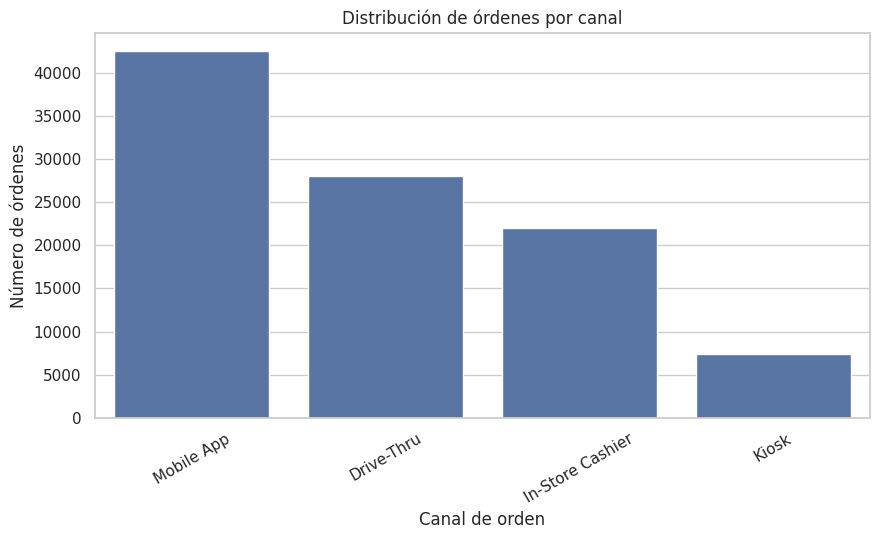

Distribución de órdenes por hora:


,order_hour,total_orders
0,0,406
1,1,400
2,2,409
3,3,429
4,4,841
5,5,2031
6,6,8171
7,7,10208
8,8,8112
9,9,6151


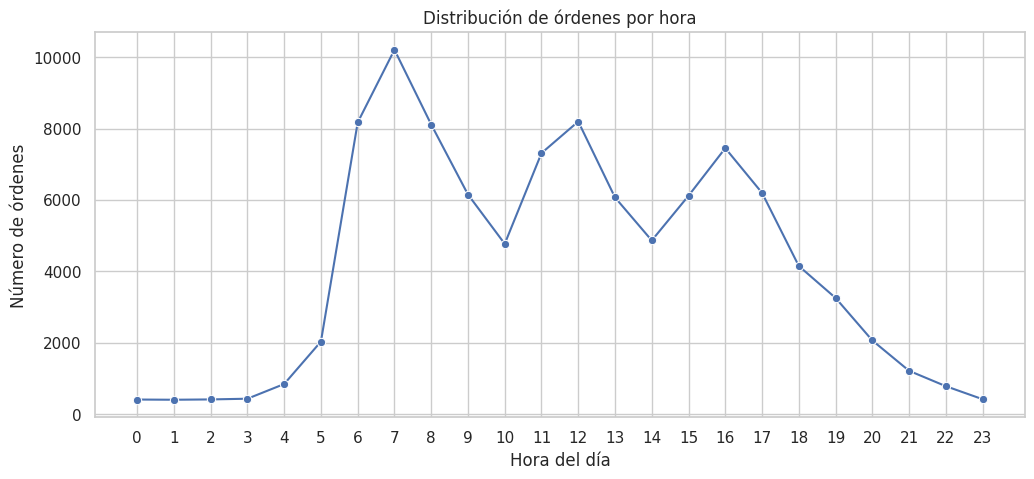

Distribución de órdenes por día de la semana:


,day_of_week,total_orders
0,Mon,14386
1,Tue,14385
2,Wed,14120
3,Thu,14214
4,Fri,14277
5,Sat,14443
6,Sun,14175


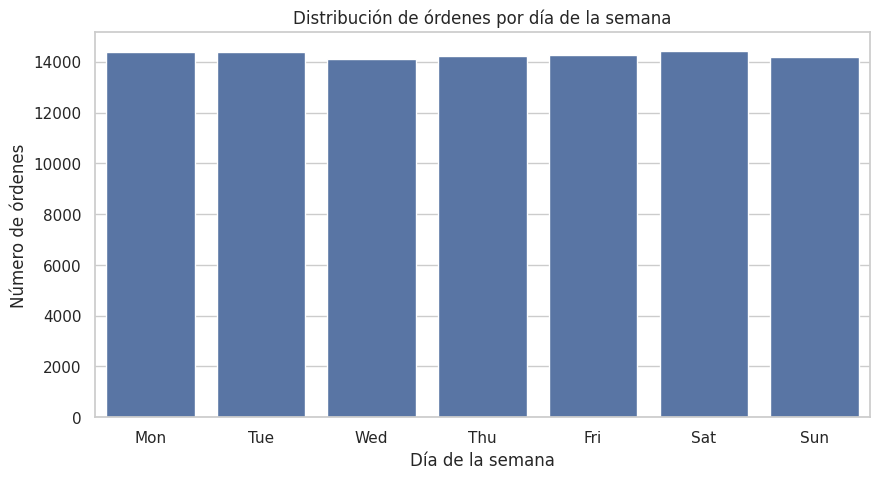

Distribución de órdenes por mes:


,order_month,total_orders
0,1,8509
1,2,7893
2,3,8572
3,4,8193
4,5,8502
5,6,8292
6,7,8480
7,8,8347
8,9,8191
9,10,8578


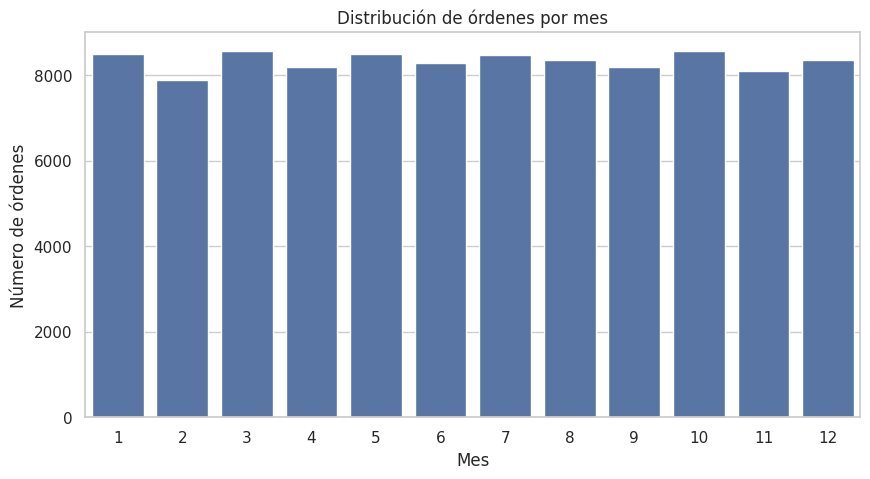

Distribución de órdenes por canal y hora:


,order_channel,order_hour,total_orders
0,Drive-Thru,0,108
1,Drive-Thru,1,101
2,Drive-Thru,2,125
3,Drive-Thru,3,101
4,Drive-Thru,4,241
5,Drive-Thru,5,561
6,Drive-Thru,6,2315
7,Drive-Thru,7,2857
8,Drive-Thru,8,2273
9,Drive-Thru,9,1745


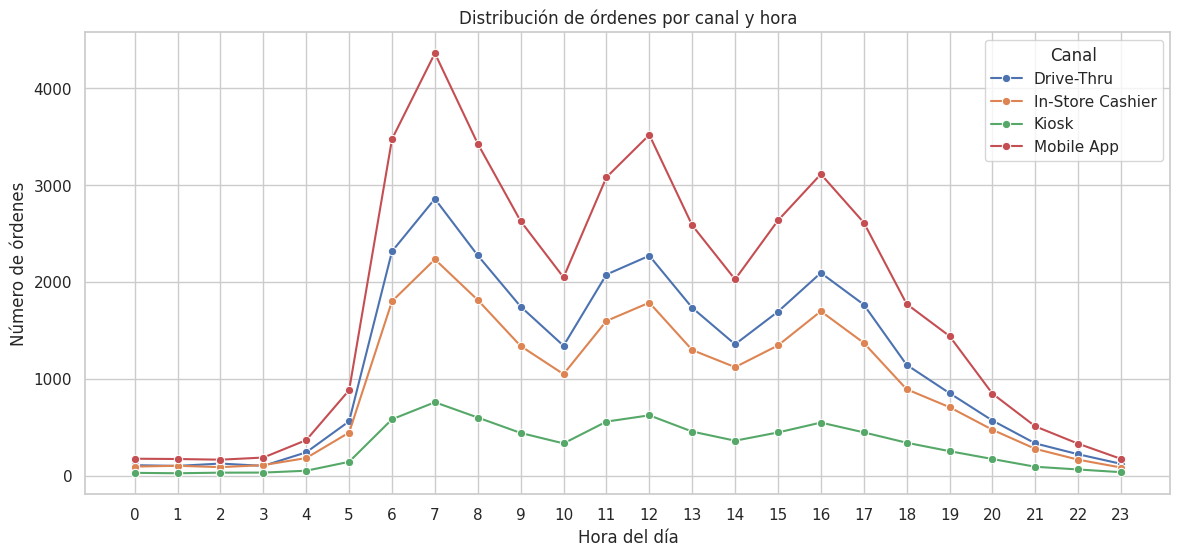

Órdenes de canales foco: Kiosk e In-Store Cashier


,order_channel,total_orders,percentage_over_total_dataset
0,In-Store Cashier,22063,22.0630
1,Kiosk,7420,7.4200


Órdenes por hora para canales foco:


,order_channel,order_hour,total_orders
0,In-Store Cashier,0,94
1,In-Store Cashier,1,102
2,In-Store Cashier,2,88
3,In-Store Cashier,3,109
4,In-Store Cashier,4,182
5,In-Store Cashier,5,445
6,In-Store Cashier,6,1800
7,In-Store Cashier,7,2233
8,In-Store Cashier,8,1813
9,In-Store Cashier,9,1338


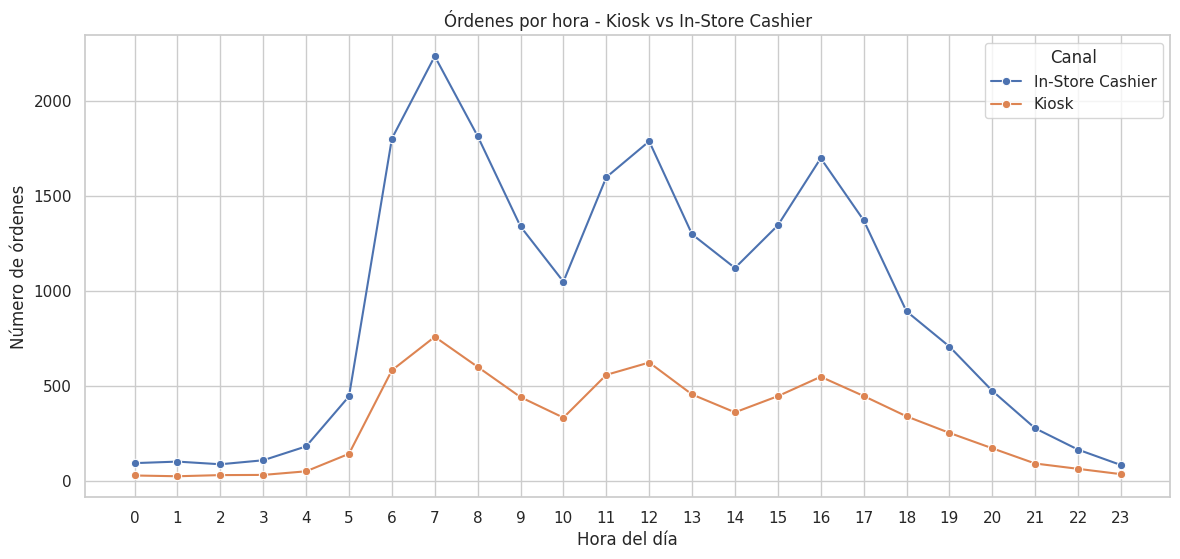

In [8]:
# =========================================================
# 7. EDA BÁSICO DE CANALES Y DEMANDA TEMPORAL
# =========================================================

# ---------------------------------------------------------
# 7.1 Distribución de órdenes por canal
# ---------------------------------------------------------

orders_by_channel = (
    df_clean["order_channel"]
    .value_counts()
    .reset_index()
)

orders_by_channel.columns = ["order_channel", "total_orders"]
orders_by_channel["percentage"] = (
    orders_by_channel["total_orders"] / orders_by_channel["total_orders"].sum()
) * 100

print("Distribución de órdenes por canal:")
display(orders_by_channel)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=orders_by_channel,
    x="order_channel",
    y="total_orders"
)
plt.title("Distribución de órdenes por canal")
plt.xlabel("Canal de orden")
plt.ylabel("Número de órdenes")
plt.xticks(rotation=30)
plt.show()

# ---------------------------------------------------------
# 7.2 Distribución de órdenes por hora
# ---------------------------------------------------------

orders_by_hour = (
    df_clean.groupby("order_hour")
    .agg(total_orders=("order_id", "count"))
    .reset_index()
)

print("Distribución de órdenes por hora:")
display(orders_by_hour)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=orders_by_hour,
    x="order_hour",
    y="total_orders",
    marker="o"
)
plt.title("Distribución de órdenes por hora")
plt.xlabel("Hora del día")
plt.ylabel("Número de órdenes")
plt.xticks(range(0, 24))
plt.show()

# ---------------------------------------------------------
# 7.3 Distribución de órdenes por día de la semana
# ---------------------------------------------------------

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

orders_by_day = (
    df_clean.groupby("day_of_week")
    .agg(total_orders=("order_id", "count"))
    .reindex(day_order)
    .reset_index()
)

print("Distribución de órdenes por día de la semana:")
display(orders_by_day)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=orders_by_day,
    x="day_of_week",
    y="total_orders",
    order=day_order
)
plt.title("Distribución de órdenes por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Número de órdenes")
plt.show()

# ---------------------------------------------------------
# 7.4 Distribución de órdenes por mes
# ---------------------------------------------------------

orders_by_month = (
    df_clean.groupby("order_month")
    .agg(total_orders=("order_id", "count"))
    .reset_index()
)

print("Distribución de órdenes por mes:")
display(orders_by_month)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=orders_by_month,
    x="order_month",
    y="total_orders"
)
plt.title("Distribución de órdenes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de órdenes")
plt.show()

# ---------------------------------------------------------
# 7.5 Distribución de órdenes por canal y hora
# ---------------------------------------------------------

orders_by_channel_hour = (
    df_clean.groupby(["order_channel", "order_hour"])
    .agg(total_orders=("order_id", "count"))
    .reset_index()
)

print("Distribución de órdenes por canal y hora:")
display(orders_by_channel_hour.head(20))

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=orders_by_channel_hour,
    x="order_hour",
    y="total_orders",
    hue="order_channel",
    marker="o"
)
plt.title("Distribución de órdenes por canal y hora")
plt.xlabel("Hora del día")
plt.ylabel("Número de órdenes")
plt.xticks(range(0, 24))
plt.legend(title="Canal")
plt.show()

# ---------------------------------------------------------
# 7.6 Foco en canales relevantes para dimensionamiento
# ---------------------------------------------------------

channels_focus = ["Kiosk", "In-Store Cashier"]

df_focus = df_clean[df_clean["order_channel"].isin(channels_focus)].copy()

orders_focus = (
    df_focus.groupby("order_channel")
    .agg(total_orders=("order_id", "count"))
    .reset_index()
)

orders_focus["percentage_over_total_dataset"] = (
    orders_focus["total_orders"] / len(df_clean)
) * 100

print("Órdenes de canales foco: Kiosk e In-Store Cashier")
display(orders_focus)

orders_focus_hour = (
    df_focus.groupby(["order_channel", "order_hour"])
    .agg(total_orders=("order_id", "count"))
    .reset_index()
)

print("Órdenes por hora para canales foco:")
display(orders_focus_hour)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=orders_focus_hour,
    x="order_hour",
    y="total_orders",
    hue="order_channel",
    marker="o"
)
plt.title("Órdenes por hora - Kiosk vs In-Store Cashier")
plt.xlabel("Hora del día")
plt.ylabel("Número de órdenes")
plt.xticks(range(0, 24))
plt.legend(title="Canal")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Interpretación de los resultado:</strong> 

El canal con mayor volumen es Mobile App, seguido de Drive-Thru, luego In-Store Cashier y finalmente Kiosk.

Para nuestro objetivo, lo más relevante es:

Kiosk: 7,420 órdenes

In-Store Cashier: 22,063 órdenes

Kiosk + In-Store Cashier: 29,483 órdenes
    
</div>


# 8. EDA DEL TIEMPO DE ATENCIÓN

Estadísticas generales de fulfillment_time_min:


,fulfillment_time_min
count,"100,000.0000"
mean,4.5461
std,1.5503
min,1.0000
25%,3.4000
50%,4.4000
75%,5.5000
max,11.2000


Tiempo de atención por canal:


,order_channel,total_orders,avg_fulfillment_time,median_fulfillment_time,min_fulfillment_time,max_fulfillment_time,std_fulfillment_time
0,Drive-Thru,27996,5.8040,5.8000,2.0000,11.2000,1.4965
3,Mobile App,42521,4.5072,4.5000,1.5000,9.2000,1.1996
2,Kiosk,7420,4.0138,4.0000,1.5000,7.9000,1.0832
1,In-Store Cashier,22063,3.2038,3.2000,1.0000,7.0000,0.9879


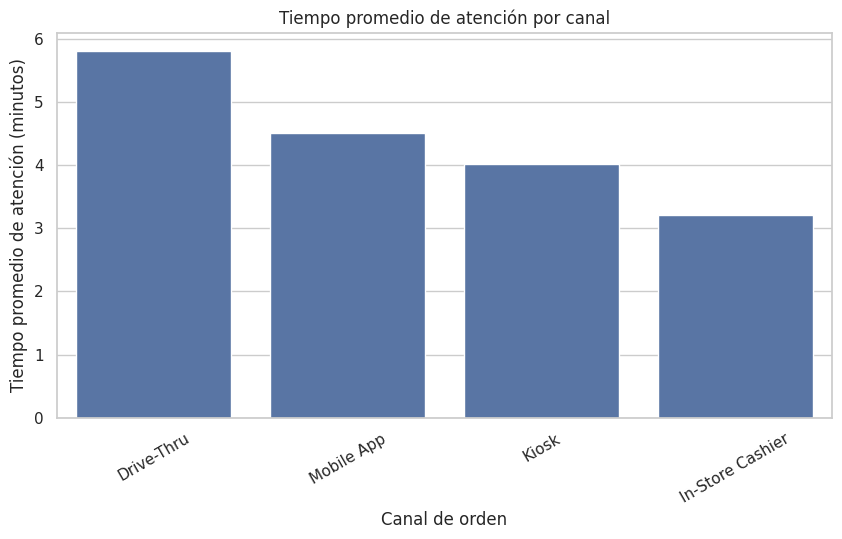

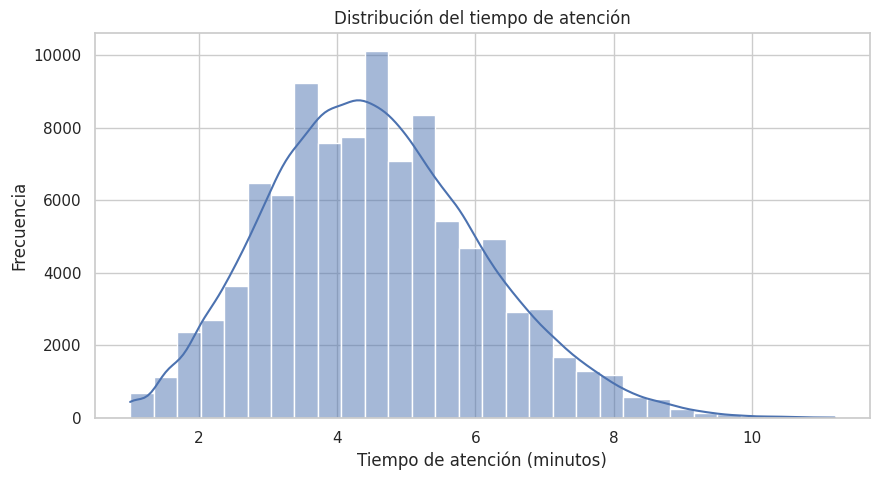

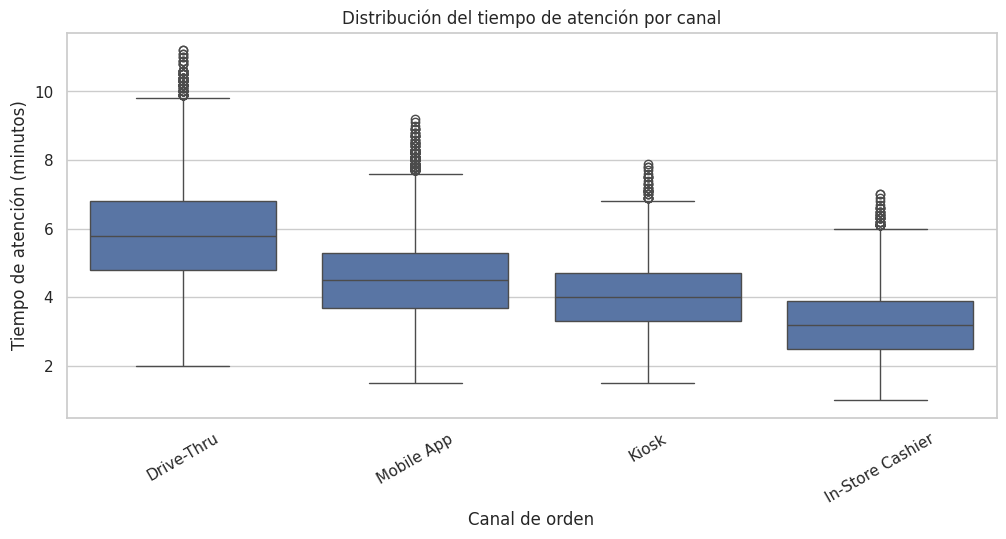

Tiempo promedio de atención por canal y hora:


,order_channel,order_hour,total_orders,avg_fulfillment_time
0,Drive-Thru,0,108,5.7824
1,Drive-Thru,1,101,5.6257
2,Drive-Thru,2,125,5.7208
3,Drive-Thru,3,101,5.9208
4,Drive-Thru,4,241,5.9241
5,Drive-Thru,5,561,5.7950
6,Drive-Thru,6,2315,5.7992
7,Drive-Thru,7,2857,5.7870
8,Drive-Thru,8,2273,5.8393
9,Drive-Thru,9,1745,5.7402


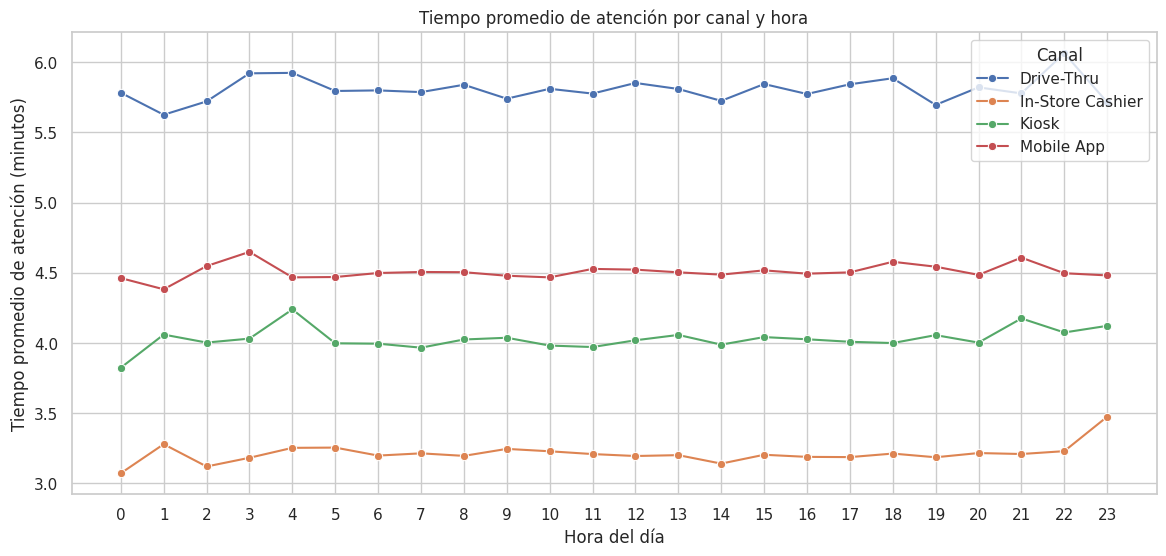

Tiempo y carga total para Kiosk e In-Store Cashier:


,order_channel,total_orders,avg_fulfillment_time,median_fulfillment_time,total_workload_min
0,In-Store Cashier,22063,3.2038,3.2000,"70,685.9000"
1,Kiosk,7420,4.0138,4.0000,"29,782.1000"


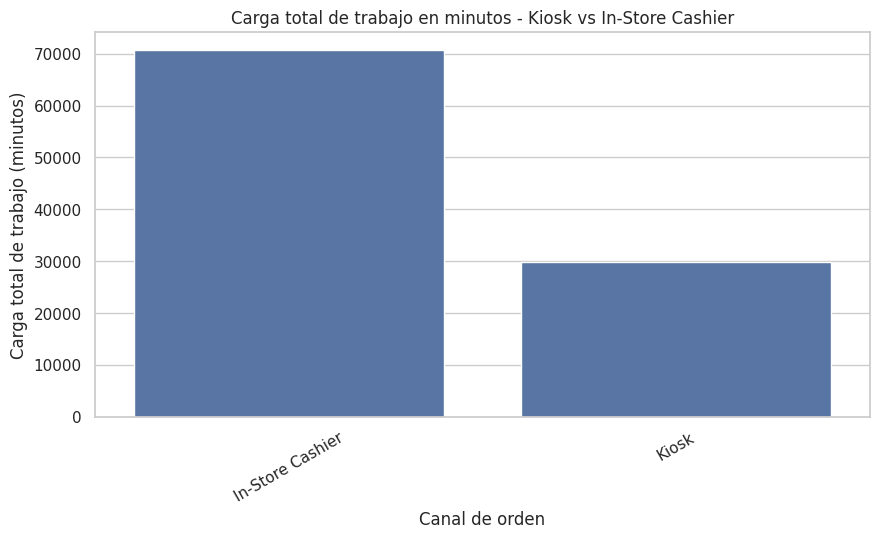

In [9]:
# =========================================================
# 8. EDA DEL TIEMPO DE ATENCIÓN
# =========================================================

# ---------------------------------------------------------
# 8.1 Estadísticas generales de fulfillment_time_min
# ---------------------------------------------------------

print("Estadísticas generales de fulfillment_time_min:")
display(df_clean["fulfillment_time_min"].describe().to_frame("fulfillment_time_min"))

# ---------------------------------------------------------
# 8.2 Tiempo promedio de atención por canal
# ---------------------------------------------------------

time_by_channel = (
    df_clean.groupby("order_channel")
    .agg(
        total_orders=("order_id", "count"),
        avg_fulfillment_time=("fulfillment_time_min", "mean"),
        median_fulfillment_time=("fulfillment_time_min", "median"),
        min_fulfillment_time=("fulfillment_time_min", "min"),
        max_fulfillment_time=("fulfillment_time_min", "max"),
        std_fulfillment_time=("fulfillment_time_min", "std")
    )
    .reset_index()
    .sort_values(by="avg_fulfillment_time", ascending=False)
)

print("Tiempo de atención por canal:")
display(time_by_channel)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=time_by_channel,
    x="order_channel",
    y="avg_fulfillment_time"
)
plt.title("Tiempo promedio de atención por canal")
plt.xlabel("Canal de orden")
plt.ylabel("Tiempo promedio de atención (minutos)")
plt.xticks(rotation=30)
plt.show()

# ---------------------------------------------------------
# 8.3 Distribución del tiempo de atención
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_clean,
    x="fulfillment_time_min",
    bins=30,
    kde=True
)
plt.title("Distribución del tiempo de atención")
plt.xlabel("Tiempo de atención (minutos)")
plt.ylabel("Frecuencia")
plt.show()

# ---------------------------------------------------------
# 8.4 Boxplot del tiempo de atención por canal
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_clean,
    x="order_channel",
    y="fulfillment_time_min"
)
plt.title("Distribución del tiempo de atención por canal")
plt.xlabel("Canal de orden")
plt.ylabel("Tiempo de atención (minutos)")
plt.xticks(rotation=30)
plt.show()

# ---------------------------------------------------------
# 8.5 Tiempo promedio de atención por hora y canal
# ---------------------------------------------------------

time_by_channel_hour = (
    df_clean.groupby(["order_channel", "order_hour"])
    .agg(
        total_orders=("order_id", "count"),
        avg_fulfillment_time=("fulfillment_time_min", "mean")
    )
    .reset_index()
)

print("Tiempo promedio de atención por canal y hora:")
display(time_by_channel_hour.head(30))

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=time_by_channel_hour,
    x="order_hour",
    y="avg_fulfillment_time",
    hue="order_channel",
    marker="o"
)
plt.title("Tiempo promedio de atención por canal y hora")
plt.xlabel("Hora del día")
plt.ylabel("Tiempo promedio de atención (minutos)")
plt.xticks(range(0, 24))
plt.legend(title="Canal")
plt.show()

# ---------------------------------------------------------
# 8.6 Foco en Kiosk e In-Store Cashier
# ---------------------------------------------------------

time_focus = (
    df_focus.groupby("order_channel")
    .agg(
        total_orders=("order_id", "count"),
        avg_fulfillment_time=("fulfillment_time_min", "mean"),
        median_fulfillment_time=("fulfillment_time_min", "median"),
        total_workload_min=("fulfillment_time_min", "sum")
    )
    .reset_index()
)

print("Tiempo y carga total para Kiosk e In-Store Cashier:")
display(time_focus)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=time_focus,
    x="order_channel",
    y="total_workload_min"
)
plt.title("Carga total de trabajo en minutos - Kiosk vs In-Store Cashier")
plt.xlabel("Canal de orden")
plt.ylabel("Carga total de trabajo (minutos)")
plt.xticks(rotation=30)
plt.show()

<div class="alert alert-block alert-info">
    <strong>Interpretación de los resultados:</strong> 

El tiempo promedio general es: 4.55 minutos por orden.

Por canal:
| Canal            | Tiempo promedio |
| ---------------- | --------------: |
| Drive-Thru       |        5.80 min |
| Mobile App       |        4.51 min |
| Kiosk            |        4.01 min |
| In-Store Cashier |        3.20 min |


</div>

# 9. DETECCIÓN DE OUTLIERS EN VARIABLES NUMÉRICAS

Resumen de outliers por variable usando método IQR:


,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
0,cart_size,3.0000,5.0000,2.0000,0.0000,8.0000,900,0.9000
1,num_customizations,1.0000,3.0000,2.0000,-2.0000,6.0000,609,0.6090
2,total_spend,10.8375,18.1800,7.3425,-0.1762,29.1937,1415,1.4150
3,fulfillment_time_min,3.4000,5.5000,2.1000,0.2500,8.6500,811,0.8110
4,customer_satisfaction,3.0000,5.0000,2.0000,0.0000,8.0000,0,0.0000


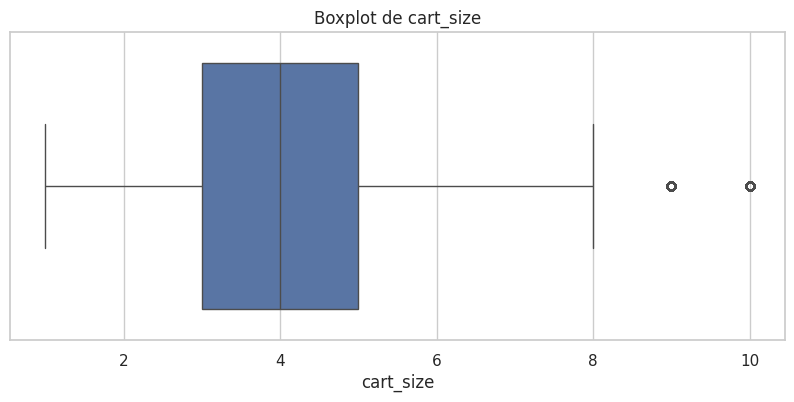

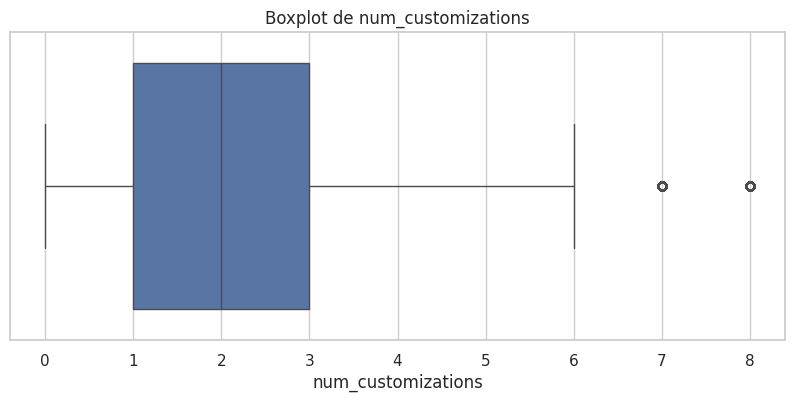

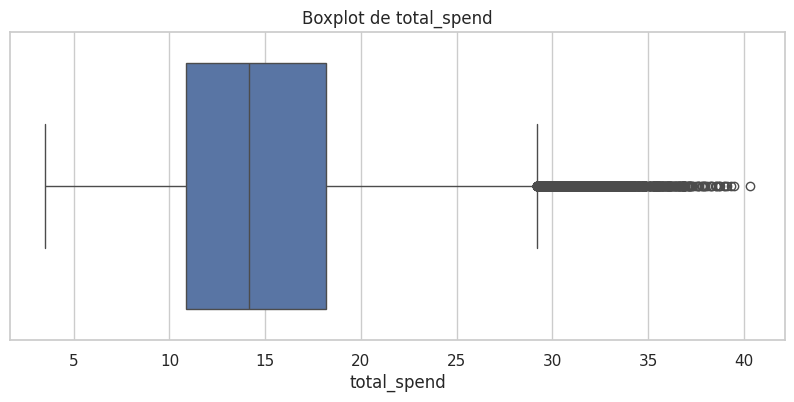

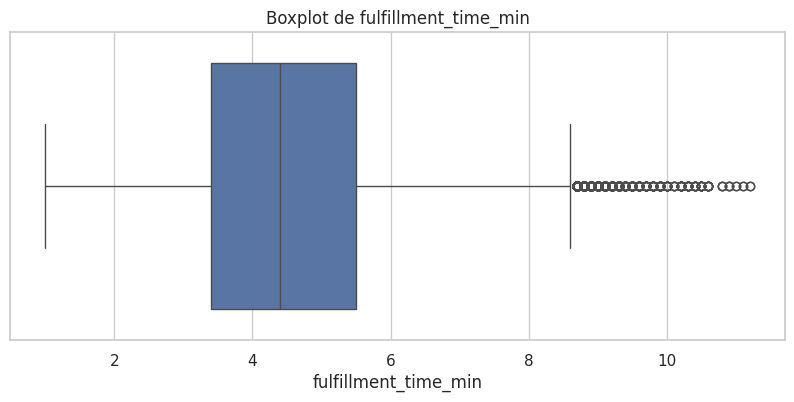

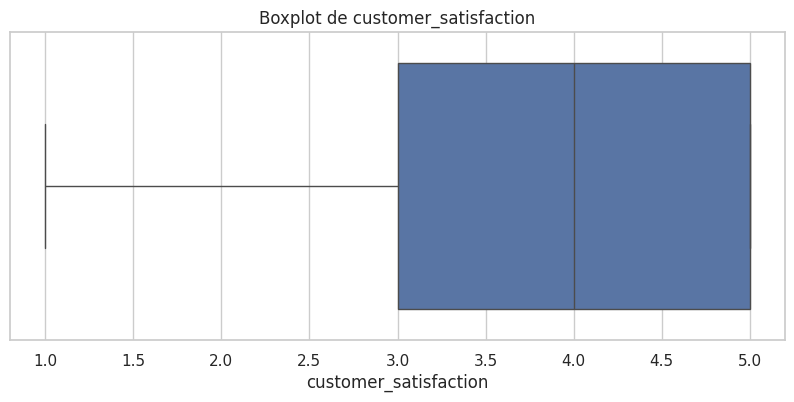


Outliers detectados en: total_spend
Límite inferior: -0.1762
Límite superior: 29.1937
Cantidad de outliers: 1,415
Porcentaje de outliers: 1.4150%


,order_id,order_channel,store_id,order_datetime,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead
34,ORD_00000035,Mobile App,STR_287,2025-06-16 08:28:00,10,3,36.0500,3.9000,Brewed Coffee,True,False
67,ORD_00000068,Mobile App,STR_097,2024-05-31 12:02:00,8,2,30.4200,4.9000,Frappuccino,True,True
324,ORD_00000325,Mobile App,STR_372,2024-06-20 18:13:00,9,2,31.5700,5.2000,Espresso,False,True
562,ORD_00000563,Mobile App,STR_040,2024-12-09 16:27:00,7,4,29.2400,5.0000,Frappuccino,True,True
676,ORD_00000677,Mobile App,STR_146,2024-02-16 14:22:00,8,3,30.7100,5.9000,Espresso,True,True
1086,ORD_00001087,Mobile App,STR_330,2024-11-21 15:40:00,9,5,34.0100,4.3000,Refresher,False,True
1190,ORD_00001191,Mobile App,STR_446,2025-11-09 11:56:00,8,3,30.1700,6.9000,Espresso,False,True
1211,ORD_00001212,Mobile App,STR_015,2024-09-21 16:47:00,8,3,30.4900,5.4000,Espresso,False,False
1535,ORD_00001536,Mobile App,STR_419,2024-01-15 08:27:00,8,3,29.3700,6.2000,Espresso,False,True
1545,ORD_00001546,Mobile App,STR_371,2024-12-03 08:19:00,9,3,30.8500,5.1000,Tea,False,True



Outliers detectados en: fulfillment_time_min
Límite inferior: 0.2500
Límite superior: 8.6500
Cantidad de outliers: 811
Porcentaje de outliers: 0.8110%


,order_id,order_channel,store_id,order_datetime,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead
101,ORD_00000102,Drive-Thru,STR_026,2025-01-24 15:12:00,2,5,11.6000,9.8000,Frappuccino,False,False
263,ORD_00000264,Drive-Thru,STR_101,2024-05-20 19:18:00,1,2,7.7100,8.9000,Tea,False,False
270,ORD_00000271,Drive-Thru,STR_305,2024-06-12 06:17:00,2,2,10.7900,8.9000,Brewed Coffee,True,False
273,ORD_00000274,Drive-Thru,STR_465,2024-06-27 06:35:00,3,1,12.9200,9.7000,Brewed Coffee,True,False
317,ORD_00000318,Drive-Thru,STR_336,2025-01-20 16:29:00,4,0,13.6500,9.1000,Brewed Coffee,False,False
526,ORD_00000527,Drive-Thru,STR_444,2025-05-23 06:43:00,6,2,19.5700,9.2000,Frappuccino,False,False
548,ORD_00000549,Drive-Thru,STR_216,2024-10-16 09:03:00,4,1,14.5200,9.6000,Brewed Coffee,False,False
556,ORD_00000557,Drive-Thru,STR_005,2024-02-06 13:23:00,3,1,12.0200,8.8000,Frappuccino,False,False
591,ORD_00000592,Drive-Thru,STR_478,2025-08-28 07:13:00,4,0,12.9000,9.0000,Brewed Coffee,True,False
778,ORD_00000779,Drive-Thru,STR_482,2025-08-21 13:13:00,2,0,7.4400,9.4000,Refresher,False,False


In [10]:
# =========================================================
# 9. DETECCIÓN DE OUTLIERS EN VARIABLES NUMÉRICAS
# =========================================================

# ---------------------------------------------------------
# 9.1 Variables numéricas a evaluar
# ---------------------------------------------------------

numeric_cols_outliers = [
    "cart_size",
    "num_customizations",
    "total_spend",
    "fulfillment_time_min",
    "customer_satisfaction"
]

# ---------------------------------------------------------
# 9.2 Función para detectar outliers con método IQR
# ---------------------------------------------------------

def detectar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = dataframe[
        (dataframe[columna] < limite_inferior) |
        (dataframe[columna] > limite_superior)
    ]
    
    return {
        "variable": columna,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": outliers.shape[0],
        "porcentaje_outliers": (outliers.shape[0] / dataframe.shape[0]) * 100
    }

# ---------------------------------------------------------
# 9.3 Calcular outliers por variable
# ---------------------------------------------------------

resultados_outliers = []

for col in numeric_cols_outliers:
    resultados_outliers.append(detectar_outliers_iqr(df_clean, col))

df_outliers = pd.DataFrame(resultados_outliers)

print("Resumen de outliers por variable usando método IQR:")
display(df_outliers)

# ---------------------------------------------------------
# 9.4 Visualización con boxplots
# ---------------------------------------------------------

for col in numeric_cols_outliers:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_clean, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

# ---------------------------------------------------------
# 9.5 Outliers específicos en variables clave para el modelo
# ---------------------------------------------------------

variables_clave_outliers = [
    "total_spend",
    "fulfillment_time_min"
]

for col in variables_clave_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    df_out_col = df_clean[
        (df_clean[col] < limite_inferior) |
        (df_clean[col] > limite_superior)
    ]
    
    print("\n" + "="*60)
    print(f"Outliers detectados en: {col}")
    print("="*60)
    print(f"Límite inferior: {limite_inferior:.4f}")
    print(f"Límite superior: {limite_superior:.4f}")
    print(f"Cantidad de outliers: {df_out_col.shape[0]:,}")
    print(f"Porcentaje de outliers: {(df_out_col.shape[0] / df_clean.shape[0]) * 100:.4f}%")
    
    display(df_out_col[
        [
            "order_id",
            "order_channel",
            "store_id",
            "order_datetime",
            "cart_size",
            "num_customizations",
            "total_spend",
            "fulfillment_time_min",
            "drink_category",
            "has_food_item",
            "order_ahead"
        ]
    ].head(10))

<div class="alert alert-block alert-info">
    <strong>Resumen de los resultados obtenidos:</strong> 

| Variable                | % outliers | Interpretación                                            |
| ----------------------- | ---------: | --------------------------------------------------------- |
| `cart_size`             |      0.90% | Órdenes grandes, pero posibles                            |
| `num_customizations`    |      0.61% | Órdenes con muchas personalizaciones                      |
| `total_spend`           |      1.42% | Tickets altos, principalmente asociados a órdenes grandes |
| `fulfillment_time_min`  |      0.81% | Tiempos altos, principalmente en Drive-Thru               |
| `customer_satisfaction` |      0.00% | Sin outliers                                              |
</div>

<div class="alert alert-block alert-info">
    <strong>Resumen:</strong> 

1. No parecen errores de datos. Parecen casos extremos reales del negocio.

2. No eliminamos los outliers en esta etapa, dado que el objetivo es estimar demanda, duración y capacidad operativa. Los casos extremos representan horas o condiciones de mayor carga. Eliminar estos registros podría subestimar la necesidad de kioskos.
</div>

# 10. LIMPIEZA BÁSICA Y DATASET PREPARADO

In [11]:
# =========================================================
# 10. LIMPIEZA BÁSICA Y DATASET PREPARADO
# =========================================================

# ---------------------------------------------------------
# 10.1 Crear copia definitiva de trabajo
# ---------------------------------------------------------

df_model = df_clean.copy()

# ---------------------------------------------------------
# 10.2 Eliminar columnas auxiliares de validación temporal
# ---------------------------------------------------------

cols_to_drop_aux = [
    "order_day_abbr_from_date",
    "day_of_week_match"
]

df_model = df_model.drop(columns=cols_to_drop_aux, errors="ignore")

# ---------------------------------------------------------
# 10.3 Convertir variables booleanas a enteros
# ---------------------------------------------------------

bool_cols = [
    "is_rewards_member",
    "has_food_item",
    "order_ahead"
]

for col in bool_cols:
    df_model[col] = df_model[col].astype(int)

# ---------------------------------------------------------
# 10.4 Crear variables adicionales útiles para modelado
# ---------------------------------------------------------

# Ticket promedio por producto dentro de la orden
df_model["spend_per_item"] = df_model["total_spend"] / df_model["cart_size"]

# Personalizaciones promedio por producto
df_model["customizations_per_item"] = df_model["num_customizations"] / df_model["cart_size"]

# Indicador de orden con alta personalización
df_model["high_customization_order"] = (
    df_model["num_customizations"] >= df_model["num_customizations"].quantile(0.75)
).astype(int)

# Indicador de orden grande
df_model["large_order"] = (
    df_model["cart_size"] >= df_model["cart_size"].quantile(0.75)
).astype(int)

# Indicador de ticket alto
df_model["high_spend_order"] = (
    df_model["total_spend"] >= df_model["total_spend"].quantile(0.75)
).astype(int)

# ---------------------------------------------------------
# 10.5 Validar tipos de datos finales
# ---------------------------------------------------------

print("Dimensiones del dataset preparado:")
print(f"Filas: {df_model.shape[0]:,}")
print(f"Columnas: {df_model.shape[1]:,}")

print("\nTipos de datos finales:")
display(df_model.dtypes.to_frame("tipo_dato"))

print("\nPrimeras filas del dataset preparado:")
display(df_model.head())

# ---------------------------------------------------------
# 10.6 Validación final de nulos
# ---------------------------------------------------------

nulos_finales = pd.DataFrame({
    "nulos": df_model.isnull().sum(),
    "porcentaje_nulos": (df_model.isnull().sum() / len(df_model)) * 100
}).sort_values(by="nulos", ascending=False)

print("\nNulos después de limpieza básica:")
display(nulos_finales[nulos_finales["nulos"] > 0])

if nulos_finales["nulos"].sum() == 0:
    print("No hay valores nulos en el dataset preparado.")
else:
    print("Existen valores nulos que deben revisarse.")

# ---------------------------------------------------------
# 10.7 Resumen de nuevas variables creadas
# ---------------------------------------------------------

new_features = [
    "spend_per_item",
    "customizations_per_item",
    "high_customization_order",
    "large_order",
    "high_spend_order"
]

print("\nResumen de nuevas variables creadas:")
display(df_model[new_features].describe().T)

Dimensiones del dataset preparado:
Filas: 100,000
Columnas: 37

Tipos de datos finales:


,tipo_dato
customer_id,object
order_id,object
order_date,datetime64[ns]
order_time,object
day_of_week,object
order_channel,object
store_id,object
store_location_type,object
region,object
customer_age_group,object



Primeras filas del dataset preparado:


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction,order_datetime,order_year,order_month,order_day,order_hour,order_minute,order_dayofweek_num,order_day_name,is_weekend,order_week,order_quarter,order_date_only,spend_per_item,customizations_per_item,high_customization_order,large_order,high_spend_order
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,0,5,0,14.4800,8.2000,Refresher,0,0,4,2024-03-25 08:47:00,2024,3,25,8,47,0,Monday,0,13,1,2024-03-25,2.8960,0.0000,0,1,0
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,1,1,3,9.5200,5.4000,Brewed Coffee,0,1,4,2025-07-18 08:02:00,2025,7,18,8,2,4,Friday,0,29,3,2025-07-18,9.5200,3.0000,1,0,0
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,0,2,1,9.3200,4.9000,Brewed Coffee,0,0,5,2025-01-15 05:40:00,2025,1,15,5,40,2,Wednesday,0,3,1,2025-01-15,4.6600,0.5000,0,0,0
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,1,2,1,9.5500,3.5000,Refresher,0,0,4,2024-07-30 15:10:00,2024,7,30,15,10,1,Tuesday,0,31,3,2024-07-30,4.7750,0.5000,0,0,0
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,0,3,1,12.2400,4.1000,Frappuccino,0,0,3,2024-06-18 07:38:00,2024,6,18,7,38,1,Tuesday,0,25,2,2024-06-18,4.0800,0.3333,0,0,0



Nulos después de limpieza básica:


,nulos,porcentaje_nulos


No hay valores nulos en el dataset preparado.

Resumen de nuevas variables creadas:


,count,mean,std,min,25%,50%,75%,max
spend_per_item,"100,000.0000",4.2882,1.2235,2.6210,3.5000,3.9867,4.6900,16.6400
customizations_per_item,"100,000.0000",0.6005,0.6502,0.0000,0.2000,0.5000,0.8000,8.0000
high_customization_order,"100,000.0000",0.2761,0.4470,0.0000,0.0000,0.0000,1.0000,1.0000
large_order,"100,000.0000",0.2948,0.4559,0.0000,0.0000,0.0000,1.0000,1.0000
high_spend_order,"100,000.0000",0.2500,0.4330,0.0000,0.0000,0.0000,1.0000,1.0000


<div class="alert alert-block alert-info">
    <strong>Variables creadas:</strong> 

| Variable                   | Interpretación                                          |
| -------------------------- | ------------------------------------------------------- |
| `spend_per_item`           | Gasto promedio por producto                             |
| `customizations_per_item`  | Nivel de personalización relativo al tamaño de la orden |
| `high_customization_order` | Orden con alta personalización                          |
| `large_order`              | Orden grande                                            |
| `high_spend_order`         | Orden de ticket alto                                    |
    
</div>

# 11. EDA ENFOCADO EN CAPACIDAD OPERATIVA

Registros de canales foco:
Total registros Kiosk + In-Store Cashier: 29,483


,total_orders
order_channel,
In-Store Cashier,22063
Kiosk,7420


Carga operativa por canal:


,order_channel,total_orders,avg_fulfillment_time,median_fulfillment_time,total_workload_min,avg_cart_size,avg_customizations,avg_total_spend,workload_hours
0,In-Store Cashier,22063,3.2038,3.2000,"70,685.9000",3.4066,1.3064,12.5100,"1,178.0983"
1,Kiosk,7420,4.0138,4.0000,"29,782.1000",3.3980,1.2999,12.4886,496.3683


Carga operativa por hora y canal:


,order_channel,order_hour,total_orders,avg_fulfillment_time,total_workload_min,workload_hours
0,In-Store Cashier,0,94,3.0723,288.8000,4.8133
1,In-Store Cashier,1,102,3.2794,334.5000,5.5750
2,In-Store Cashier,2,88,3.1205,274.6000,4.5767
3,In-Store Cashier,3,109,3.1826,346.9000,5.7817
4,In-Store Cashier,4,182,3.2533,592.1000,9.8683
5,In-Store Cashier,5,445,3.2551,"1,448.5000",24.1417
6,In-Store Cashier,6,1800,3.1982,"5,756.7000",95.9450
7,In-Store Cashier,7,2233,3.2142,"7,177.2000",119.6200
8,In-Store Cashier,8,1813,3.1961,"5,794.5000",96.5750
9,In-Store Cashier,9,1338,3.2458,"4,342.9000",72.3817


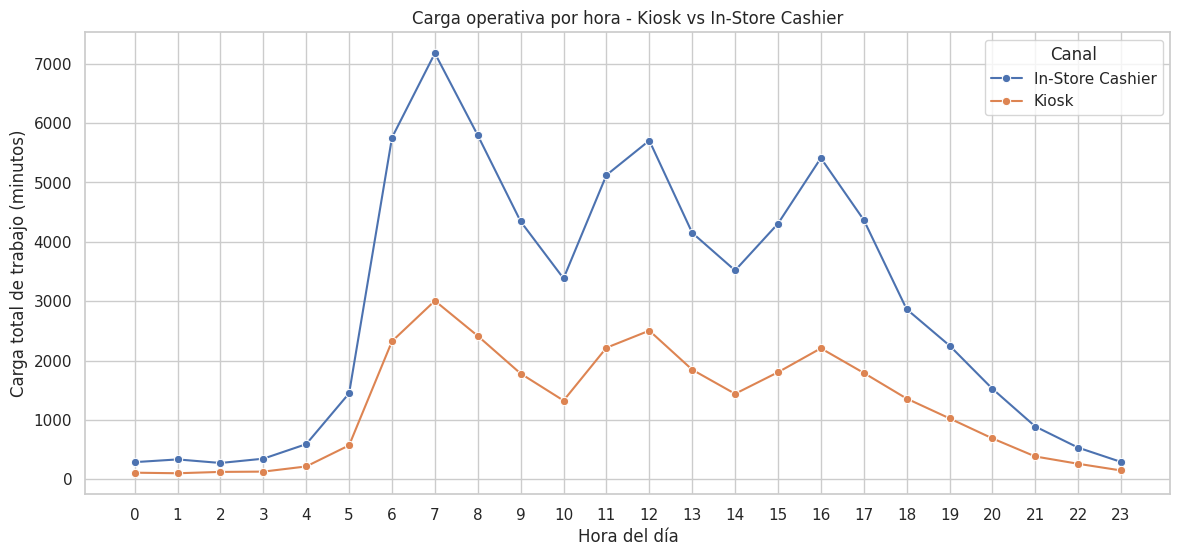

Carga operativa combinada por hora: Kiosk + In-Store Cashier


,order_hour,total_orders,avg_fulfillment_time,total_workload_min,workload_hours
0,0,123,3.2496,399.7000,6.6617
1,1,127,3.4331,436.0000,7.2667
2,2,119,3.3504,398.7000,6.6450
3,3,141,3.3752,475.9000,7.9317
4,4,233,3.4691,808.3000,13.4717
5,5,588,3.4357,"2,020.2000",33.6700
6,6,2382,3.3929,"8,081.9000",134.6983
7,7,2991,3.4049,"10,184.0000",169.7333
8,8,2413,3.4022,"8,209.5000",136.8250
9,9,1779,3.4420,"6,123.4000",102.0567


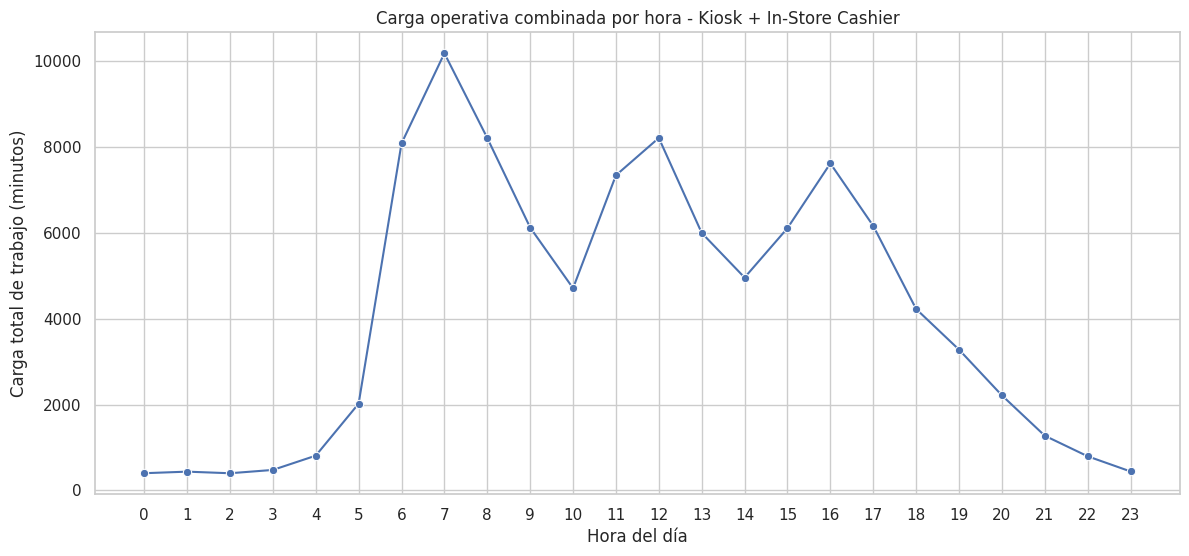

Top 10 horas con mayor carga operativa combinada:


,order_hour,total_orders,avg_fulfillment_time,total_workload_min,workload_hours
7,7,2991,3.4049,"10,184.0000",169.7333
12,12,2409,3.4083,"8,210.6000",136.8433
8,8,2413,3.4022,"8,209.5000",136.8250
6,6,2382,3.3929,"8,081.9000",134.6983
16,16,2245,3.3935,"7,618.3000",126.9717
11,11,2155,3.4064,"7,340.7000",122.3450
17,17,1818,3.3893,"6,161.7000",102.6950
9,9,1779,3.4420,"6,123.4000",102.0567
15,15,1790,3.4128,"6,109.0000",101.8167
13,13,1752,3.4237,"5,998.3000",99.9717


Top 15 tiendas con mayor carga operativa en Kiosk + In-Store Cashier:


,store_id,total_orders,avg_fulfillment_time,total_workload_min,workload_hours
151,STR_152,74,3.7324,276.2000,4.6033
163,STR_164,82,3.3634,275.8000,4.5967
231,STR_232,79,3.4848,275.3000,4.5883
237,STR_238,79,3.4582,273.2000,4.5533
146,STR_147,75,3.5973,269.8000,4.4967
213,STR_214,75,3.5573,266.8000,4.4467
4,STR_005,75,3.5253,264.4000,4.4067
287,STR_288,75,3.5147,263.6000,4.3933
92,STR_093,74,3.5595,263.4000,4.3900
3,STR_004,74,3.5122,259.9000,4.3317


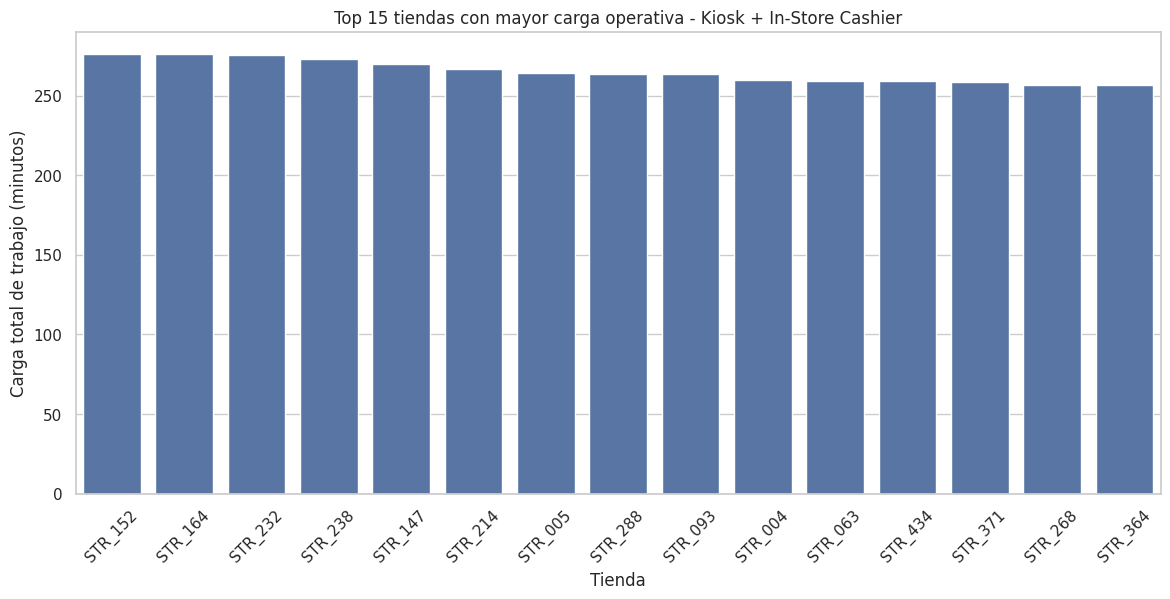

In [12]:
# =========================================================
# 11. EDA ENFOCADO EN CAPACIDAD OPERATIVA
# =========================================================

# ---------------------------------------------------------
# 11.1 Definir canales foco para dimensionamiento
# ---------------------------------------------------------

channels_focus = ["Kiosk", "In-Store Cashier"]

df_capacity_focus = df_model[
    df_model["order_channel"].isin(channels_focus)
].copy()

print("Registros de canales foco:")
print(f"Total registros Kiosk + In-Store Cashier: {df_capacity_focus.shape[0]:,}")

display(
    df_capacity_focus["order_channel"]
    .value_counts()
    .to_frame("total_orders")
)

# ---------------------------------------------------------
# 11.2 Carga total de trabajo por canal
# ---------------------------------------------------------

capacity_by_channel = (
    df_capacity_focus
    .groupby("order_channel")
    .agg(
        total_orders=("order_id", "count"),
        avg_fulfillment_time=("fulfillment_time_min", "mean"),
        median_fulfillment_time=("fulfillment_time_min", "median"),
        total_workload_min=("fulfillment_time_min", "sum"),
        avg_cart_size=("cart_size", "mean"),
        avg_customizations=("num_customizations", "mean"),
        avg_total_spend=("total_spend", "mean")
    )
    .reset_index()
)

capacity_by_channel["workload_hours"] = (
    capacity_by_channel["total_workload_min"] / 60
)

print("Carga operativa por canal:")
display(capacity_by_channel)

# ---------------------------------------------------------
# 11.3 Carga operativa por hora y canal
# ---------------------------------------------------------

capacity_by_hour_channel = (
    df_capacity_focus
    .groupby(["order_channel", "order_hour"])
    .agg(
        total_orders=("order_id", "count"),
        avg_fulfillment_time=("fulfillment_time_min", "mean"),
        total_workload_min=("fulfillment_time_min", "sum")
    )
    .reset_index()
)

capacity_by_hour_channel["workload_hours"] = (
    capacity_by_hour_channel["total_workload_min"] / 60
)

print("Carga operativa por hora y canal:")
display(capacity_by_hour_channel)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=capacity_by_hour_channel,
    x="order_hour",
    y="total_workload_min",
    hue="order_channel",
    marker="o"
)
plt.title("Carga operativa por hora - Kiosk vs In-Store Cashier")
plt.xlabel("Hora del día")
plt.ylabel("Carga total de trabajo (minutos)")
plt.xticks(range(0, 24))
plt.legend(title="Canal")
plt.show()

# ---------------------------------------------------------
# 11.4 Escenario combinado: Kiosk + In-Store Cashier
# ---------------------------------------------------------

capacity_combined_hour = (
    df_capacity_focus
    .groupby("order_hour")
    .agg(
        total_orders=("order_id", "count"),
        avg_fulfillment_time=("fulfillment_time_min", "mean"),
        total_workload_min=("fulfillment_time_min", "sum")
    )
    .reset_index()
)

capacity_combined_hour["workload_hours"] = (
    capacity_combined_hour["total_workload_min"] / 60
)

print("Carga operativa combinada por hora: Kiosk + In-Store Cashier")
display(capacity_combined_hour)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=capacity_combined_hour,
    x="order_hour",
    y="total_workload_min",
    marker="o"
)
plt.title("Carga operativa combinada por hora - Kiosk + In-Store Cashier")
plt.xlabel("Hora del día")
plt.ylabel("Carga total de trabajo (minutos)")
plt.xticks(range(0, 24))
plt.show()

# ---------------------------------------------------------
# 11.5 Identificar horas pico por carga operativa
# ---------------------------------------------------------

top_hours_combined = (
    capacity_combined_hour
    .sort_values(by="total_workload_min", ascending=False)
    .head(10)
)

print("Top 10 horas con mayor carga operativa combinada:")
display(top_hours_combined)

# ---------------------------------------------------------
# 11.6 Carga operativa por tienda
# ---------------------------------------------------------

capacity_by_store = (
    df_capacity_focus
    .groupby("store_id")
    .agg(
        total_orders=("order_id", "count"),
        avg_fulfillment_time=("fulfillment_time_min", "mean"),
        total_workload_min=("fulfillment_time_min", "sum")
    )
    .reset_index()
    .sort_values(by="total_workload_min", ascending=False)
)

capacity_by_store["workload_hours"] = capacity_by_store["total_workload_min"] / 60

print("Top 15 tiendas con mayor carga operativa en Kiosk + In-Store Cashier:")
display(capacity_by_store.head(15))

plt.figure(figsize=(14, 6))
sns.barplot(
    data=capacity_by_store.head(15),
    x="store_id",
    y="total_workload_min"
)
plt.title("Top 15 tiendas con mayor carga operativa - Kiosk + In-Store Cashier")
plt.xlabel("Tienda")
plt.ylabel("Carga total de trabajo (minutos)")
plt.xticks(rotation=45)
plt.show()

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong> 
    
En este paso se realizó un análisis exploratorio enfocado en la capacidad operativa de los canales relevantes para el dimensionamiento de kioskos: Kiosk e In-Store Cashier. El objetivo fue pasar de un análisis descriptivo de órdenes a una medición de carga de trabajo, considerando tanto el volumen de órdenes como el tiempo de atención asociado a cada canal.

El análisis muestra que los canales foco concentran 29.483 órdenes en total, distribuidas en 22.063 órdenes de In-Store Cashier y 7.420 órdenes de Kiosk. En términos de carga operativa, In-Store Cashier acumula 70.685,9 minutos de trabajo, equivalentes a 1.178,1 horas, mientras que Kiosk acumula 29.782,1 minutos, equivalentes a 496,4 horas. En conjunto, ambos canales representan una carga total aproximada de 100.468 minutos, es decir, 1.674,5 horas de trabajo operativo.

El tiempo promedio de atención también difiere entre canales. In-Store Cashier presenta un tiempo promedio de 3,20 minutos por orden, mientras que Kiosk presenta un tiempo promedio de 4,01 minutos. Aunque Kiosk tiene menor volumen de órdenes, su tiempo promedio de atención es superior al de caja física.

Al analizar la carga por hora, se observa que la mayor concentración operativa ocurre en la mañana. Para el escenario combinado Kiosk + In-Store Cashier, la hora de mayor carga es las 7:00 a.m., con 2.991 órdenes y 10.184 minutos acumulados en todo el periodo histórico. También se identifican cargas relevantes a las 6:00 a.m., 8:00 a.m., 12:00 p.m., 16:00 p.m. y 11:00 a.m.

Este análisis permitió identificar las horas pico y confirmar que el dimensionamiento de kioskos no debe realizarse únicamente con el volumen total de órdenes, sino considerando la carga operativa por hora. Estos resultados sirven como base para calcular posteriormente la capacidad requerida y estimar el número de kioskos necesarios bajo diferentes escenarios.

</div>

# 12. CONSTRUCCIÓN DEL DATASET DE DEMANDA HORARIA

Dimensiones del dataset de demanda horaria:
Filas: 99,723
Columnas: 26

Primeras filas del dataset de demanda:


,store_id,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend,order_hour,order_channel,store_location_type,region,total_orders,avg_cart_size,avg_num_customizations,avg_total_spend,avg_spend_per_item,avg_customizations_per_item,pct_rewards_member,pct_has_food_item,pct_order_ahead,avg_customer_satisfaction,avg_fulfillment_time_min,total_workload_min,total_workload_hours
0,STR_001,2024-01-13,2024,1,2,13,5,Saturday,1,8,Mobile App,Suburban,Southwest,1,4.0000,2.0000,17.5500,4.3875,0.5000,0.0000,1.0000,0.0000,4.0000,1.7000,1.7000,0.0283
1,STR_001,2024-01-15,2024,1,3,15,0,Monday,0,8,Drive-Thru,Suburban,Southwest,1,3.0000,1.0000,9.5900,3.1967,0.3333,0.0000,0.0000,0.0000,3.0000,5.7000,5.7000,0.0950
2,STR_001,2024-01-15,2024,1,3,15,0,Monday,0,8,Mobile App,Suburban,Southwest,1,1.0000,2.0000,10.1500,10.1500,2.0000,1.0000,1.0000,1.0000,2.0000,5.1000,5.1000,0.0850
3,STR_001,2024-01-18,2024,1,3,18,3,Thursday,0,17,Mobile App,Suburban,Southwest,1,6.0000,4.0000,27.2200,4.5367,0.6667,1.0000,1.0000,1.0000,4.0000,7.0000,7.0000,0.1167
4,STR_001,2024-01-19,2024,1,3,19,4,Friday,0,16,Drive-Thru,Suburban,Southwest,1,3.0000,0.0000,9.9300,3.3100,0.0000,1.0000,0.0000,0.0000,2.0000,5.0000,5.0000,0.0833



Tipos de datos:


,tipo_dato
store_id,object
order_date_only,object
order_year,int32
order_month,int32
order_week,int64
order_day,int32
order_dayofweek_num,int32
order_day_name,object
is_weekend,int64
order_hour,int32



Estadísticas de la variable objetivo total_orders:


,total_orders
count,"99,723.0000"
mean,1.0028
std,0.0526
min,1.0000
25%,1.0000
50%,1.0000
75%,1.0000
max,2.0000



Validación de totales contra dataset original:
Total órdenes en df_model: 100,000
Total órdenes agregadas en df_demand: 100,000

Carga total en minutos en df_model: 454,608.00
Carga total en minutos en df_demand: 454,608.00

Resumen de demanda horaria por canal:


,order_channel,total_orders,avg_orders_per_store_hour,median_orders_per_store_hour,max_orders_per_store_hour,avg_fulfillment_time_min,total_workload_min
3,Mobile App,42521,1.0041,1.0000,2,4.5077,"191,652.3000"
0,Drive-Thru,27996,1.0021,1.0000,2,5.8043,"162,487.7000"
1,In-Store Cashier,22063,1.0018,1.0000,2,3.2041,"70,685.9000"
2,Kiosk,7420,1.0004,1.0000,2,4.0140,"29,782.1000"



Resumen de demanda horaria para canales foco:


,order_channel,total_orders,total_store_hour_records,avg_orders_per_store_hour,median_orders_per_store_hour,p90_orders_per_store_hour,p95_orders_per_store_hour,max_orders_per_store_hour,avg_fulfillment_time_min,total_workload_min
0,In-Store Cashier,22063,22024,1.0018,1.0000,1.0000,1.0000,2,3.2041,"70,685.9000"
1,Kiosk,7420,7417,1.0004,1.0000,1.0000,1.0000,2,4.0140,"29,782.1000"


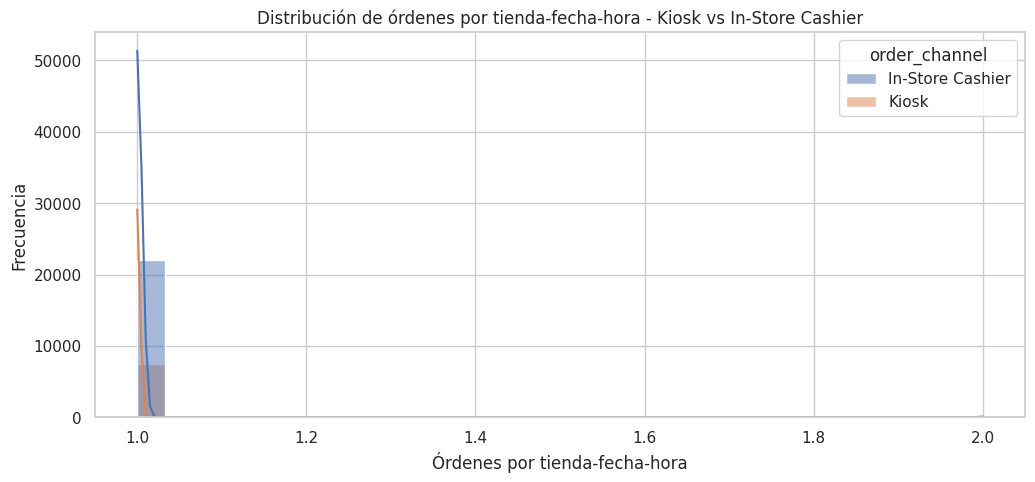

In [13]:
# =========================================================
# 12. CONSTRUCCIÓN DEL DATASET DE DEMANDA HORARIA
# =========================================================

# ---------------------------------------------------------
# 12.1 Agrupar órdenes por tienda, fecha, hora y canal
# ---------------------------------------------------------

df_demand = (
    df_model
    .groupby([
        "store_id",
        "order_date_only",
        "order_year",
        "order_month",
        "order_week",
        "order_day",
        "order_dayofweek_num",
        "order_day_name",
        "is_weekend",
        "order_hour",
        "order_channel",
        "store_location_type",
        "region"
    ])
    .agg(
        total_orders=("order_id", "count"),
        avg_cart_size=("cart_size", "mean"),
        avg_num_customizations=("num_customizations", "mean"),
        avg_total_spend=("total_spend", "mean"),
        avg_spend_per_item=("spend_per_item", "mean"),
        avg_customizations_per_item=("customizations_per_item", "mean"),
        pct_rewards_member=("is_rewards_member", "mean"),
        pct_has_food_item=("has_food_item", "mean"),
        pct_order_ahead=("order_ahead", "mean"),
        avg_customer_satisfaction=("customer_satisfaction", "mean"),
        avg_fulfillment_time_min=("fulfillment_time_min", "mean"),
        total_workload_min=("fulfillment_time_min", "sum")
    )
    .reset_index()
)

# ---------------------------------------------------------
# 12.2 Calcular carga en horas
# ---------------------------------------------------------

df_demand["total_workload_hours"] = df_demand["total_workload_min"] / 60

# ---------------------------------------------------------
# 12.3 Validar dimensiones y estructura
# ---------------------------------------------------------

print("Dimensiones del dataset de demanda horaria:")
print(f"Filas: {df_demand.shape[0]:,}")
print(f"Columnas: {df_demand.shape[1]:,}")

print("\nPrimeras filas del dataset de demanda:")
display(df_demand.head())

print("\nTipos de datos:")
display(df_demand.dtypes.to_frame("tipo_dato"))

# ---------------------------------------------------------
# 12.4 Validar variable objetivo del modelo de demanda
# ---------------------------------------------------------

print("\nEstadísticas de la variable objetivo total_orders:")
display(df_demand["total_orders"].describe().to_frame("total_orders"))

# ---------------------------------------------------------
# 12.5 Validar carga operativa agregada
# ---------------------------------------------------------

print("\nValidación de totales contra dataset original:")
print(f"Total órdenes en df_model: {df_model.shape[0]:,}")
print(f"Total órdenes agregadas en df_demand: {df_demand['total_orders'].sum():,}")

print(f"\nCarga total en minutos en df_model: {df_model['fulfillment_time_min'].sum():,.2f}")
print(f"Carga total en minutos en df_demand: {df_demand['total_workload_min'].sum():,.2f}")

# ---------------------------------------------------------
# 12.6 Resumen por canal desde el dataset de demanda
# ---------------------------------------------------------

demand_summary_channel = (
    df_demand
    .groupby("order_channel")
    .agg(
        total_orders=("total_orders", "sum"),
        avg_orders_per_store_hour=("total_orders", "mean"),
        median_orders_per_store_hour=("total_orders", "median"),
        max_orders_per_store_hour=("total_orders", "max"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean"),
        total_workload_min=("total_workload_min", "sum")
    )
    .reset_index()
    .sort_values(by="total_orders", ascending=False)
)

print("\nResumen de demanda horaria por canal:")
display(demand_summary_channel)

# ---------------------------------------------------------
# 12.7 Foco en Kiosk e In-Store Cashier
# ---------------------------------------------------------

df_demand_focus = df_demand[
    df_demand["order_channel"].isin(["Kiosk", "In-Store Cashier"])
].copy()

demand_focus_summary = (
    df_demand_focus
    .groupby("order_channel")
    .agg(
        total_orders=("total_orders", "sum"),
        total_store_hour_records=("total_orders", "count"),
        avg_orders_per_store_hour=("total_orders", "mean"),
        median_orders_per_store_hour=("total_orders", "median"),
        p90_orders_per_store_hour=("total_orders", lambda x: x.quantile(0.90)),
        p95_orders_per_store_hour=("total_orders", lambda x: x.quantile(0.95)),
        max_orders_per_store_hour=("total_orders", "max"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean"),
        total_workload_min=("total_workload_min", "sum")
    )
    .reset_index()
)

print("\nResumen de demanda horaria para canales foco:")
display(demand_focus_summary)

# ---------------------------------------------------------
# 12.8 Visualizar distribución de órdenes por tienda-hora
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
sns.histplot(
    data=df_demand_focus,
    x="total_orders",
    hue="order_channel",
    bins=30,
    kde=True
)
plt.title("Distribución de órdenes por tienda-fecha-hora - Kiosk vs In-Store Cashier")
plt.xlabel("Órdenes por tienda-fecha-hora")
plt.ylabel("Frecuencia")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Interpretación de los resultados:</strong> 

La agregación por store_id + fecha + hora + canal quedó demasiado granular. total_orders tiene:

Promedio: 1.0028
Mediana: 1
Máximo: 2


Entonces, para este dataset, casi cada combinación tienda-fecha-hora-canal tiene solo 1 orden. Así, un modelo de demanda con esa granularidad no aprendería mucho, porque casi siempre tendría que predecir 1.

Por lo tanto, tomamos la siguiente Decisión metodológica. Para el dimensionamiento general de kiosko usaremos:

order_date_only + order_hour + order_channel

</div>

# 13. DATASET DE DEMANDA HORARIA AGREGADA

Dimensiones del dataset de demanda horaria agregada:
Filas: 39,407
Columnas: 23

Primeras filas:


,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend,order_hour,order_channel,total_orders,avg_cart_size,avg_num_customizations,avg_total_spend,avg_spend_per_item,avg_customizations_per_item,pct_rewards_member,pct_has_food_item,pct_order_ahead,avg_customer_satisfaction,avg_fulfillment_time_min,total_workload_min,total_workload_hours
0,2024-01-01,2024,1,1,1,0,Monday,0,0,Drive-Thru,1,8.0000,1.0000,22.3800,2.7975,0.1250,0.0000,0.0000,0.0000,1.0000,2.8000,2.8000,0.0467
1,2024-01-01,2024,1,1,1,0,Monday,0,4,Mobile App,1,5.0000,1.0000,17.3700,3.4740,0.2000,1.0000,0.0000,1.0000,4.0000,4.5000,4.5000,0.0750
2,2024-01-01,2024,1,1,1,0,Monday,0,5,Drive-Thru,1,2.0000,3.0000,9.2100,4.6050,1.5000,0.0000,0.0000,0.0000,3.0000,5.7000,5.7000,0.0950
3,2024-01-01,2024,1,1,1,0,Monday,0,5,In-Store Cashier,1,2.0000,2.0000,8.2400,4.1200,1.0000,0.0000,0.0000,0.0000,3.0000,3.4000,3.4000,0.0567
4,2024-01-01,2024,1,1,1,0,Monday,0,6,Drive-Thru,4,3.0000,3.0000,13.0775,4.9529,1.1875,0.5000,0.5000,0.0000,2.5000,5.9250,23.7000,0.3950



Estadísticas de total_orders en demanda horaria agregada:


,total_orders
count,"39,407.0000"
mean,2.5376
std,1.7867
min,1.0000
25%,1.0000
50%,2.0000
75%,3.0000
max,15.0000



Resumen de demanda horaria agregada por canal:


,order_channel,total_orders,total_hour_records,avg_orders_per_hour,median_orders_per_hour,p90_orders_per_hour,p95_orders_per_hour,max_orders_per_hour,avg_fulfillment_time_min,total_workload_min
3,Mobile App,42521,12569,3.3830,3.0000,6.0000,8.0000,15,4.5072,"191,652.3000"
0,Drive-Thru,27996,11108,2.5203,2.0000,5.0000,5.0000,15,5.8056,"162,487.7000"
1,In-Store Cashier,22063,10233,2.1561,2.0000,4.0000,5.0000,9,3.2103,"70,685.9000"
2,Kiosk,7420,5497,1.3498,1.0000,2.0000,3.0000,7,4.0141,"29,782.1000"



Resumen de demanda horaria agregada para canales foco:


,order_channel,total_orders,total_hour_records,avg_orders_per_hour,median_orders_per_hour,p90_orders_per_hour,p95_orders_per_hour,max_orders_per_hour,avg_fulfillment_time_min,total_workload_min
0,In-Store Cashier,22063,10233,2.1561,2.0000,4.0000,5.0000,9,3.2103,"70,685.9000"
1,Kiosk,7420,5497,1.3498,1.0000,2.0000,3.0000,7,4.0141,"29,782.1000"



Validación de totales:
Total órdenes en df_model: 100,000
Total órdenes agregadas en df_demand_hourly: 100,000

Carga total en minutos en df_model: 454,608.00
Carga total en minutos en df_demand_hourly: 454,608.00


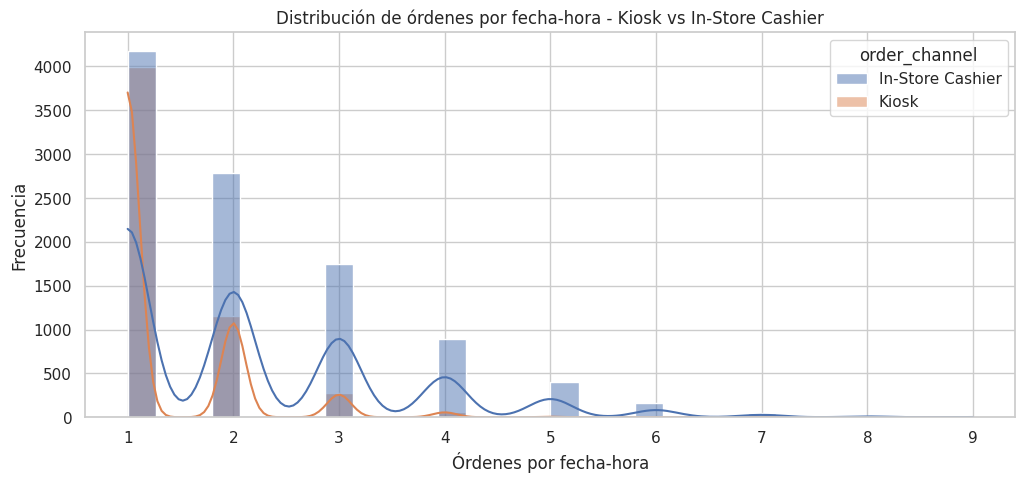

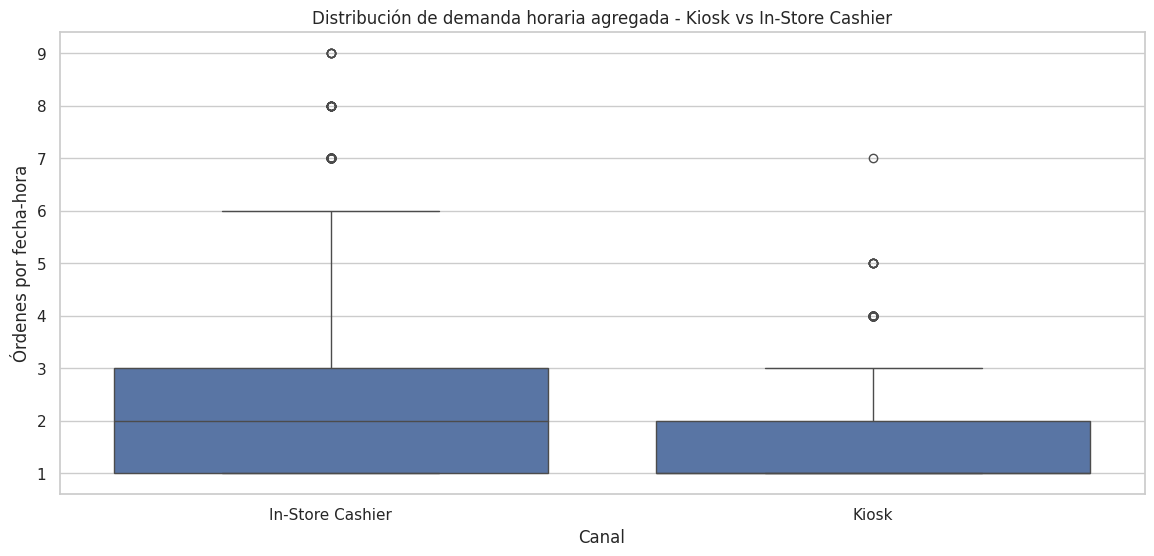

In [14]:
# =========================================================
# 13. DATASET DE DEMANDA HORARIA AGREGADA
# =========================================================

# ---------------------------------------------------------
# 13.1 Agrupar demanda por fecha, hora y canal
# ---------------------------------------------------------

df_demand_hourly = (
    df_model
    .groupby([
        "order_date_only",
        "order_year",
        "order_month",
        "order_week",
        "order_day",
        "order_dayofweek_num",
        "order_day_name",
        "is_weekend",
        "order_hour",
        "order_channel"
    ])
    .agg(
        total_orders=("order_id", "count"),
        avg_cart_size=("cart_size", "mean"),
        avg_num_customizations=("num_customizations", "mean"),
        avg_total_spend=("total_spend", "mean"),
        avg_spend_per_item=("spend_per_item", "mean"),
        avg_customizations_per_item=("customizations_per_item", "mean"),
        pct_rewards_member=("is_rewards_member", "mean"),
        pct_has_food_item=("has_food_item", "mean"),
        pct_order_ahead=("order_ahead", "mean"),
        avg_customer_satisfaction=("customer_satisfaction", "mean"),
        avg_fulfillment_time_min=("fulfillment_time_min", "mean"),
        total_workload_min=("fulfillment_time_min", "sum")
    )
    .reset_index()
)

# ---------------------------------------------------------
# 13.2 Calcular carga en horas
# ---------------------------------------------------------

df_demand_hourly["total_workload_hours"] = (
    df_demand_hourly["total_workload_min"] / 60
)

# ---------------------------------------------------------
# 13.3 Validar dimensiones
# ---------------------------------------------------------

print("Dimensiones del dataset de demanda horaria agregada:")
print(f"Filas: {df_demand_hourly.shape[0]:,}")
print(f"Columnas: {df_demand_hourly.shape[1]:,}")

print("\nPrimeras filas:")
display(df_demand_hourly.head())

# ---------------------------------------------------------
# 13.4 Estadísticas de la variable objetivo total_orders
# ---------------------------------------------------------

print("\nEstadísticas de total_orders en demanda horaria agregada:")
display(df_demand_hourly["total_orders"].describe().to_frame("total_orders"))

# ---------------------------------------------------------
# 13.5 Resumen por canal
# ---------------------------------------------------------

hourly_summary_channel = (
    df_demand_hourly
    .groupby("order_channel")
    .agg(
        total_orders=("total_orders", "sum"),
        total_hour_records=("total_orders", "count"),
        avg_orders_per_hour=("total_orders", "mean"),
        median_orders_per_hour=("total_orders", "median"),
        p90_orders_per_hour=("total_orders", lambda x: x.quantile(0.90)),
        p95_orders_per_hour=("total_orders", lambda x: x.quantile(0.95)),
        max_orders_per_hour=("total_orders", "max"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean"),
        total_workload_min=("total_workload_min", "sum")
    )
    .reset_index()
    .sort_values(by="total_orders", ascending=False)
)

print("\nResumen de demanda horaria agregada por canal:")
display(hourly_summary_channel)

# ---------------------------------------------------------
# 13.6 Foco en Kiosk e In-Store Cashier
# ---------------------------------------------------------

df_demand_hourly_focus = df_demand_hourly[
    df_demand_hourly["order_channel"].isin(["Kiosk", "In-Store Cashier"])
].copy()

hourly_focus_summary = (
    df_demand_hourly_focus
    .groupby("order_channel")
    .agg(
        total_orders=("total_orders", "sum"),
        total_hour_records=("total_orders", "count"),
        avg_orders_per_hour=("total_orders", "mean"),
        median_orders_per_hour=("total_orders", "median"),
        p90_orders_per_hour=("total_orders", lambda x: x.quantile(0.90)),
        p95_orders_per_hour=("total_orders", lambda x: x.quantile(0.95)),
        max_orders_per_hour=("total_orders", "max"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean"),
        total_workload_min=("total_workload_min", "sum")
    )
    .reset_index()
)

print("\nResumen de demanda horaria agregada para canales foco:")
display(hourly_focus_summary)

# ---------------------------------------------------------
# 13.7 Validar totales contra dataset original
# ---------------------------------------------------------

print("\nValidación de totales:")
print(f"Total órdenes en df_model: {df_model.shape[0]:,}")
print(f"Total órdenes agregadas en df_demand_hourly: {df_demand_hourly['total_orders'].sum():,}")

print(f"\nCarga total en minutos en df_model: {df_model['fulfillment_time_min'].sum():,.2f}")
print(f"Carga total en minutos en df_demand_hourly: {df_demand_hourly['total_workload_min'].sum():,.2f}")

# ---------------------------------------------------------
# 13.8 Visualización de demanda horaria agregada
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
sns.histplot(
    data=df_demand_hourly_focus,
    x="total_orders",
    hue="order_channel",
    bins=30,
    kde=True
)
plt.title("Distribución de órdenes por fecha-hora - Kiosk vs In-Store Cashier")
plt.xlabel("Órdenes por fecha-hora")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_demand_hourly_focus,
    x="order_channel",
    y="total_orders"
)
plt.title("Distribución de demanda horaria agregada - Kiosk vs In-Store Cashier")
plt.xlabel("Canal")
plt.ylabel("Órdenes por fecha-hora")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Resumen de los resultados:</strong>
    
1. total_orders promedio: 2.54 órdenes por fecha-hora-canal
2. máximo general: 15 órdenes
3. Kiosk máximo por hora: 7 órdenes
4. In-Store Cashier máximo por hora: 9 órdenes
5. Kiosk + In-Store Cashier será el escenario clave para capacidad

</div>

# 14. CÁLCULO BASE DE KIOSKOS REQUERIDOS SIN MACHINE LEARNING

Parámetros de capacidad:
Minutos por hora: 60
Utilización objetivo: 85%
Capacidad efectiva por kiosko/hora: 51.00 minutos
Resumen de capacidad requerida por escenario:


,scenario,total_orders,avg_orders_per_hour,median_orders_per_hour,p90_orders_per_hour,p95_orders_per_hour,max_orders_per_hour,avg_fulfillment_time_min,total_workload_min,avg_required_kiosks,median_required_kiosks,p90_required_kiosks,p95_required_kiosks,max_required_kiosks
0,Kiosk + In-Store Cashier,29483,2.5887,2.0000,5.0000,6.0000,11,3.4417,"100,468.0000",0.1730,1.0000,1.0000,1.0000,1
1,Solo Kiosk,7420,1.3498,1.0000,2.0000,3.0000,7,4.0141,"29,782.1000",0.1062,1.0000,1.0000,1.0000,1


Top 20 registros con mayor requerimiento de kioskos:


,scenario,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend,order_hour,total_orders,avg_fulfillment_time_min,total_workload_min,total_workload_hours,required_kiosks_exact,required_kiosks
5907,Kiosk + In-Store Cashier,2024-01-27,2024,1,4,27,5,Saturday,1,8,10,4.2143,39.8000,0.6633,0.7804,1
14207,Kiosk + In-Store Cashier,2025-07-12,2025,7,28,12,5,Saturday,1,6,10,4.3881,39.3000,0.6550,0.7706,1
15847,Kiosk + In-Store Cashier,2025-10-24,2025,10,43,24,4,Friday,0,11,8,4.6000,36.8000,0.6133,0.7216,1
10013,Kiosk + In-Store Cashier,2024-10-18,2024,10,42,18,4,Friday,0,12,9,4.2679,35.5000,0.5917,0.6961,1
14674,Kiosk + In-Store Cashier,2025-08-10,2025,8,32,10,6,Sunday,1,16,10,3.7375,35.5000,0.5917,0.6961,1
12753,Kiosk + In-Store Cashier,2025-04-11,2025,4,15,11,4,Friday,0,7,11,3.4972,35.3000,0.5883,0.6922,1
13450,Kiosk + In-Store Cashier,2025-05-25,2025,5,21,25,6,Sunday,1,8,9,3.8750,35.3000,0.5883,0.6922,1
7357,Kiosk + In-Store Cashier,2024-04-30,2024,4,18,30,1,Tuesday,0,11,10,3.9024,34.9000,0.5817,0.6843,1
6434,Kiosk + In-Store Cashier,2024-03-01,2024,3,9,1,4,Friday,0,16,10,3.9722,34.7000,0.5783,0.6804,1
15257,Kiosk + In-Store Cashier,2025-09-16,2025,9,38,16,1,Tuesday,0,6,11,3.7361,34.7000,0.5783,0.6804,1


Distribución de kioskos requeridos por escenario:


,scenario,required_kiosks,records,percentage
0,Kiosk + In-Store Cashier,1,11389,100.0000
1,Solo Kiosk,1,5497,100.0000


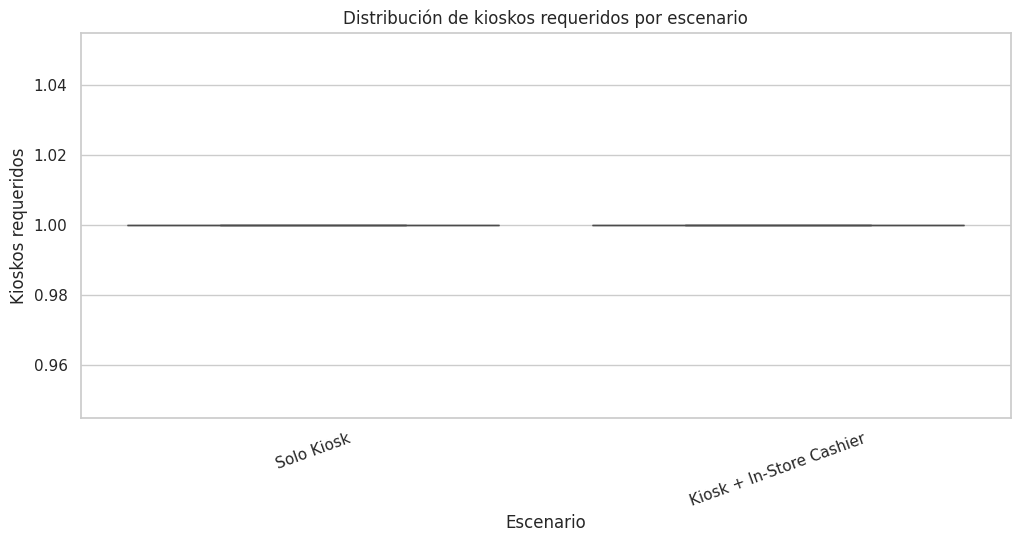

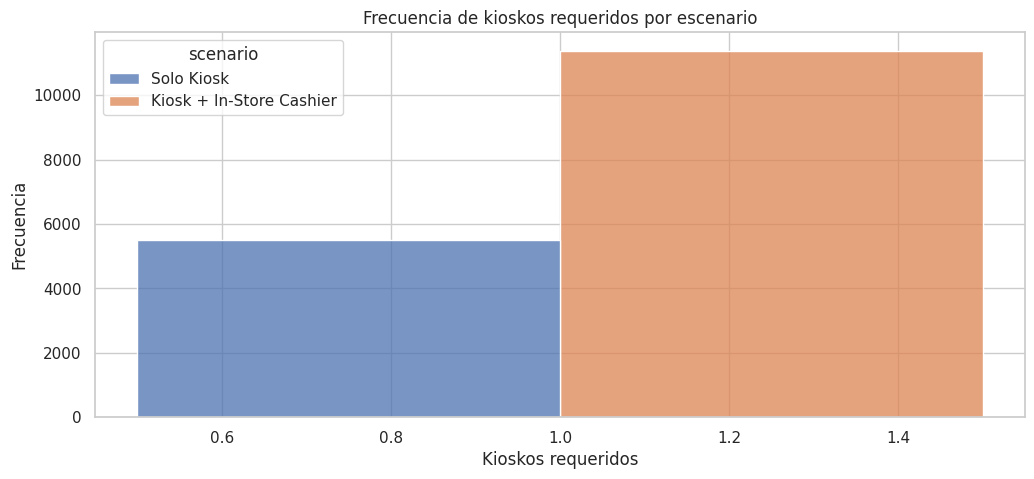

In [15]:
# =========================================================
# 14. CÁLCULO BASE DE KIOSKOS REQUERIDOS SIN MACHINE LEARNING
# =========================================================

# ---------------------------------------------------------
# 14.1 Definir parámetros de capacidad
# ---------------------------------------------------------

# Minutos disponibles por hora
minutes_per_hour = 60

# Utilización objetivo del kiosko
# 0.85 significa que no queremos planear el kiosko al 100%,
# sino dejar margen operativo para variabilidad, espera y congestión.
target_utilization = 0.85

# Capacidad efectiva de un kiosko por hora
effective_capacity_per_kiosk = minutes_per_hour * target_utilization

print("Parámetros de capacidad:")
print(f"Minutos por hora: {minutes_per_hour}")
print(f"Utilización objetivo: {target_utilization:.0%}")
print(f"Capacidad efectiva por kiosko/hora: {effective_capacity_per_kiosk:.2f} minutos")

# ---------------------------------------------------------
# 14.2 Escenario 1: Solo órdenes actuales del canal Kiosk
# ---------------------------------------------------------

df_scenario_kiosk = df_demand_hourly[
    df_demand_hourly["order_channel"] == "Kiosk"
].copy()

df_scenario_kiosk["scenario"] = "Solo Kiosk"

# En este escenario usamos la carga real observada del canal Kiosk
df_scenario_kiosk["required_kiosks_exact"] = (
    df_scenario_kiosk["total_workload_min"] / effective_capacity_per_kiosk
)

df_scenario_kiosk["required_kiosks"] = np.ceil(
    df_scenario_kiosk["required_kiosks_exact"]
).astype(int)

# ---------------------------------------------------------
# 14.3 Escenario 2: Kiosk + In-Store Cashier
# ---------------------------------------------------------

df_scenario_combined = (
    df_demand_hourly[
        df_demand_hourly["order_channel"].isin(["Kiosk", "In-Store Cashier"])
    ]
    .groupby([
        "order_date_only",
        "order_year",
        "order_month",
        "order_week",
        "order_day",
        "order_dayofweek_num",
        "order_day_name",
        "is_weekend",
        "order_hour"
    ])
    .agg(
        total_orders=("total_orders", "sum"),
        total_workload_min=("total_workload_min", "sum"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean")
    )
    .reset_index()
)

df_scenario_combined["scenario"] = "Kiosk + In-Store Cashier"

df_scenario_combined["total_workload_hours"] = (
    df_scenario_combined["total_workload_min"] / 60
)

df_scenario_combined["required_kiosks_exact"] = (
    df_scenario_combined["total_workload_min"] / effective_capacity_per_kiosk
)

df_scenario_combined["required_kiosks"] = np.ceil(
    df_scenario_combined["required_kiosks_exact"]
).astype(int)

# ---------------------------------------------------------
# 14.4 Unificar escenarios
# ---------------------------------------------------------

cols_capacity = [
    "scenario",
    "order_date_only",
    "order_year",
    "order_month",
    "order_week",
    "order_day",
    "order_dayofweek_num",
    "order_day_name",
    "is_weekend",
    "order_hour",
    "total_orders",
    "avg_fulfillment_time_min",
    "total_workload_min",
    "total_workload_hours",
    "required_kiosks_exact",
    "required_kiosks"
]

df_capacity_scenarios = pd.concat([
    df_scenario_kiosk[cols_capacity],
    df_scenario_combined[cols_capacity]
], ignore_index=True)

# ---------------------------------------------------------
# 14.5 Resumen general por escenario
# ---------------------------------------------------------

capacity_summary = (
    df_capacity_scenarios
    .groupby("scenario")
    .agg(
        total_orders=("total_orders", "sum"),
        avg_orders_per_hour=("total_orders", "mean"),
        median_orders_per_hour=("total_orders", "median"),
        p90_orders_per_hour=("total_orders", lambda x: x.quantile(0.90)),
        p95_orders_per_hour=("total_orders", lambda x: x.quantile(0.95)),
        max_orders_per_hour=("total_orders", "max"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean"),
        total_workload_min=("total_workload_min", "sum"),
        avg_required_kiosks=("required_kiosks_exact", "mean"),
        median_required_kiosks=("required_kiosks", "median"),
        p90_required_kiosks=("required_kiosks", lambda x: x.quantile(0.90)),
        p95_required_kiosks=("required_kiosks", lambda x: x.quantile(0.95)),
        max_required_kiosks=("required_kiosks", "max")
    )
    .reset_index()
)

print("Resumen de capacidad requerida por escenario:")
display(capacity_summary)

# ---------------------------------------------------------
# 14.6 Top horas con mayor requerimiento de kioskos
# ---------------------------------------------------------

top_capacity_hours = (
    df_capacity_scenarios
    .sort_values(
        by=["required_kiosks", "total_workload_min"],
        ascending=False
    )
    .head(20)
)

print("Top 20 registros con mayor requerimiento de kioskos:")
display(top_capacity_hours)

# ---------------------------------------------------------
# 14.7 Distribución de kioskos requeridos por escenario
# ---------------------------------------------------------

kiosk_distribution = (
    df_capacity_scenarios
    .groupby(["scenario", "required_kiosks"])
    .agg(records=("required_kiosks", "count"))
    .reset_index()
)

kiosk_distribution["percentage"] = (
    kiosk_distribution["records"] /
    kiosk_distribution.groupby("scenario")["records"].transform("sum")
) * 100

print("Distribución de kioskos requeridos por escenario:")
display(kiosk_distribution)

# ---------------------------------------------------------
# 14.8 Visualización de kioskos requeridos
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_capacity_scenarios,
    x="scenario",
    y="required_kiosks"
)
plt.title("Distribución de kioskos requeridos por escenario")
plt.xlabel("Escenario")
plt.ylabel("Kioskos requeridos")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(
    data=df_capacity_scenarios,
    x="required_kiosks",
    hue="scenario",
    discrete=True,
    multiple="dodge"
)
plt.title("Frecuencia de kioskos requeridos por escenario")
plt.xlabel("Kioskos requeridos")
plt.ylabel("Frecuencia")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Resumen análisis con estadistica descriptiva:</strong> 

Capacidad efectiva por kiosko = 51 minutos por hora

| Escenario                | Órdenes totales | Máximo de órdenes por hora | Carga máxima observada | Kioskos requeridos |
| ------------------------ | --------------: | -------------------------: | ---------------------: | -----------------: |
| Solo Kiosk               |           7.420 |                          7 |    Menor a 51 min/hora |                  1 |
| Kiosk + In-Store Cashier |          29.483 |                         11 |    Menor a 51 min/hora |                  1 |
    
</div>

<div class="alert alert-block alert-info">
    <strong>Interpretación:</strong> 

Como conclusión tenemos que incluso en la hora de mayor carga, el workload máximo no supera la capacidad efectiva de un kiosko.

total_workload_min = 39.8 minutos
required_kiosks_exact = 0.78
required_kiosks = 1

1 kiosko sería suficiente para cubrir las órdenes actuales del canal Kiosk.
    
</div>

<div class="alert alert-block alert-info">
    <strong>Conclusión preliminar de negocio:</strong>
    
Con la demanda actual del dataset: 1 kiosko sería suficiente para cubrir las órdenes actuales del canal Kiosk.

Y también:

1 kiosko sería suficiente para cubrir las órdenes actuales combinadas de Kiosk + In-Store Cashier,
bajo la demanda observada y con una utilización objetivo del 85%.

Para que el modelo sea más útil, vamoa a probar escenarios futuros con crecimiento de demanda de:

+25%
+50%
+100%
+200%
+300%

Así podremos responder algo más estratégico:

¿En qué punto de crecimiento o migración se necesitarían más kioskos?
</div>

# 15. SIMULACIÓN DE CRECIMIENTO DE DEMANDA Y KIOSKOS REQUERIDOS

Resumen de kioskos requeridos por escenario de crecimiento:


,growth_scenario,growth_factor,avg_projected_orders,p90_projected_orders,p95_projected_orders,max_projected_orders,avg_projected_workload_min,p90_projected_workload_min,p95_projected_workload_min,max_projected_workload_min,avg_required_kiosks,median_required_kiosks,p90_required_kiosks,p95_required_kiosks,max_required_kiosks
0,Actual,1.0000,2.5887,5.0000,6.0000,11.0000,8.8215,17.0000,20.1000,39.8000,0.1730,1.0000,1.0000,1.0000,1
3,Crecimiento +25%,1.2500,3.2359,6.2500,7.5000,13.7500,11.0269,21.2500,25.1250,49.7500,0.2162,1.0000,1.0000,1.0000,1
5,Crecimiento +50%,1.5000,3.8831,7.5000,9.0000,16.5000,13.2322,25.5000,30.1500,59.7000,0.2595,1.0000,1.0000,1.0000,2
1,Crecimiento +100%,2.0000,5.1775,10.0000,12.0000,22.0000,17.6430,34.0000,40.2000,79.6000,0.3459,1.0000,1.0000,1.0000,2
2,Crecimiento +200%,3.0000,7.7662,15.0000,18.0000,33.0000,26.4645,51.0000,60.3000,119.4000,0.5189,1.0000,1.0000,2.0000,3
4,Crecimiento +300%,4.0000,10.3549,20.0000,24.0000,44.0000,35.2860,68.0000,80.4000,159.2000,0.6919,1.0000,2.0000,2.0000,4


Distribución de kioskos requeridos por escenario de crecimiento:


,growth_scenario,growth_factor,required_kiosks,records,percentage
0,Actual,1.0000,1,11389,100.0000
6,Crecimiento +25%,1.2500,1,11389,100.0000
11,Crecimiento +50%,1.5000,1,11377,99.8946
12,Crecimiento +50%,1.5000,2,12,0.1054
1,Crecimiento +100%,2.0000,1,11241,98.7005
2,Crecimiento +100%,2.0000,2,148,1.2995
3,Crecimiento +200%,3.0000,1,10265,90.1308
4,Crecimiento +200%,3.0000,2,1112,9.7638
5,Crecimiento +200%,3.0000,3,12,0.1054
7,Crecimiento +300%,4.0000,1,8859,77.7856


Top 20 casos con mayor requerimiento de kioskos en escenarios de crecimiento:


,growth_scenario,growth_factor,order_date_only,order_day_name,is_weekend,order_hour,total_orders,projected_orders,avg_fulfillment_time_min,projected_workload_min,required_kiosks_exact,required_kiosks
57355,Crecimiento +300%,4.0000,2024-01-27,Saturday,1,8,10,40.0000,4.2143,159.2000,3.1216,4
65655,Crecimiento +300%,4.0000,2025-07-12,Saturday,1,6,10,40.0000,4.3881,157.2000,3.0824,4
67295,Crecimiento +300%,4.0000,2025-10-24,Friday,0,11,8,32.0000,4.6000,147.2000,2.8863,3
61461,Crecimiento +300%,4.0000,2024-10-18,Friday,0,12,9,36.0000,4.2679,142.0000,2.7843,3
66122,Crecimiento +300%,4.0000,2025-08-10,Sunday,1,16,10,40.0000,3.7375,142.0000,2.7843,3
64201,Crecimiento +300%,4.0000,2025-04-11,Friday,0,7,11,44.0000,3.4972,141.2000,2.7686,3
64898,Crecimiento +300%,4.0000,2025-05-25,Sunday,1,8,9,36.0000,3.8750,141.2000,2.7686,3
58805,Crecimiento +300%,4.0000,2024-04-30,Tuesday,0,11,10,40.0000,3.9024,139.6000,2.7373,3
57882,Crecimiento +300%,4.0000,2024-03-01,Friday,0,16,10,40.0000,3.9722,138.8000,2.7216,3
66705,Crecimiento +300%,4.0000,2025-09-16,Tuesday,0,6,11,44.0000,3.7361,138.8000,2.7216,3


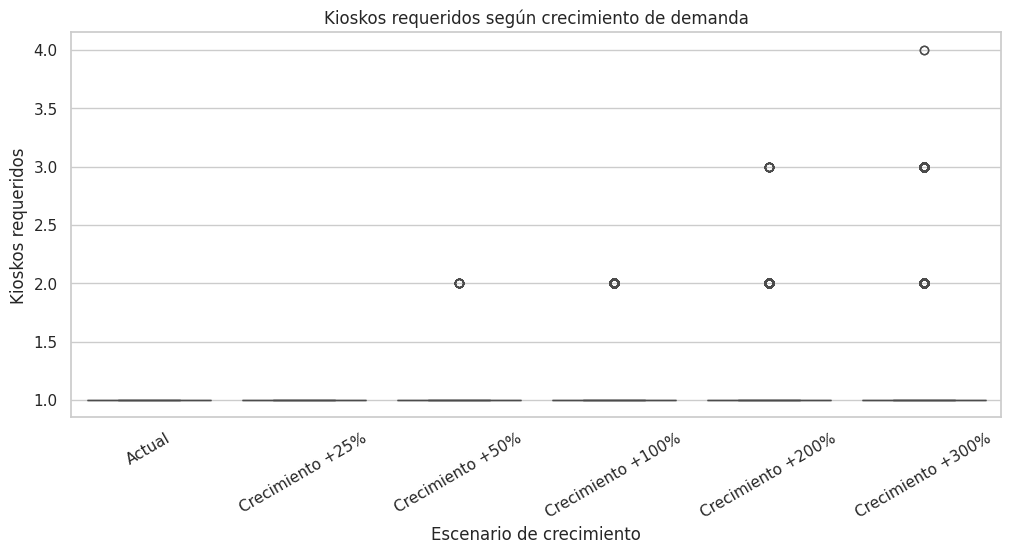

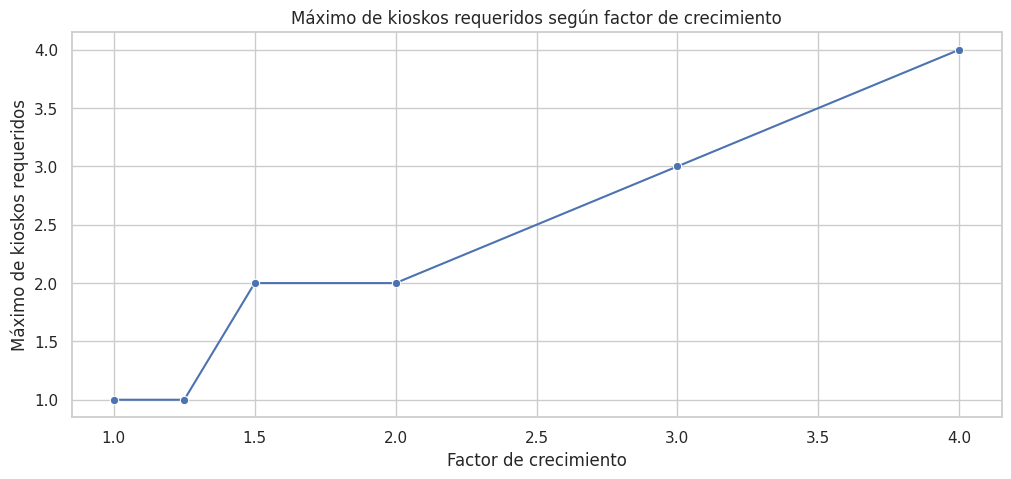

In [16]:
# =========================================================
# 15. SIMULACIÓN DE CRECIMIENTO DE DEMANDA Y KIOSKOS REQUERIDOS
# =========================================================

# ---------------------------------------------------------
# 15.1 Definir escenarios de crecimiento
# ---------------------------------------------------------

growth_scenarios = {
    "Actual": 1.00,
    "Crecimiento +25%": 1.25,
    "Crecimiento +50%": 1.50,
    "Crecimiento +100%": 2.00,
    "Crecimiento +200%": 3.00,
    "Crecimiento +300%": 4.00
}

# ---------------------------------------------------------
# 15.2 Tomar como base el escenario combinado Kiosk + In-Store Cashier
# ---------------------------------------------------------

df_growth_base = df_scenario_combined.copy()

growth_results = []

for scenario_name, growth_factor in growth_scenarios.items():
    
    temp = df_growth_base.copy()
    temp["growth_scenario"] = scenario_name
    temp["growth_factor"] = growth_factor
    
    # Escalar demanda y carga operativa
    temp["projected_orders"] = temp["total_orders"] * growth_factor
    temp["projected_workload_min"] = temp["total_workload_min"] * growth_factor
    
    # Calcular kioskos requeridos
    temp["required_kiosks_exact"] = (
        temp["projected_workload_min"] / effective_capacity_per_kiosk
    )
    
    temp["required_kiosks"] = np.ceil(
        temp["required_kiosks_exact"]
    ).astype(int)
    
    growth_results.append(temp)

df_growth_scenarios = pd.concat(growth_results, ignore_index=True)

# ---------------------------------------------------------
# 15.3 Resumen por escenario de crecimiento
# ---------------------------------------------------------

growth_summary = (
    df_growth_scenarios
    .groupby("growth_scenario")
    .agg(
        growth_factor=("growth_factor", "first"),
        avg_projected_orders=("projected_orders", "mean"),
        p90_projected_orders=("projected_orders", lambda x: x.quantile(0.90)),
        p95_projected_orders=("projected_orders", lambda x: x.quantile(0.95)),
        max_projected_orders=("projected_orders", "max"),
        avg_projected_workload_min=("projected_workload_min", "mean"),
        p90_projected_workload_min=("projected_workload_min", lambda x: x.quantile(0.90)),
        p95_projected_workload_min=("projected_workload_min", lambda x: x.quantile(0.95)),
        max_projected_workload_min=("projected_workload_min", "max"),
        avg_required_kiosks=("required_kiosks_exact", "mean"),
        median_required_kiosks=("required_kiosks", "median"),
        p90_required_kiosks=("required_kiosks", lambda x: x.quantile(0.90)),
        p95_required_kiosks=("required_kiosks", lambda x: x.quantile(0.95)),
        max_required_kiosks=("required_kiosks", "max")
    )
    .reset_index()
    .sort_values(by="growth_factor")
)

print("Resumen de kioskos requeridos por escenario de crecimiento:")
display(growth_summary)

# ---------------------------------------------------------
# 15.4 Distribución de kioskos requeridos por escenario
# ---------------------------------------------------------

growth_distribution = (
    df_growth_scenarios
    .groupby(["growth_scenario", "growth_factor", "required_kiosks"])
    .agg(records=("required_kiosks", "count"))
    .reset_index()
)

growth_distribution["percentage"] = (
    growth_distribution["records"] /
    growth_distribution.groupby("growth_scenario")["records"].transform("sum")
) * 100

growth_distribution = growth_distribution.sort_values(
    by=["growth_factor", "required_kiosks"]
)

print("Distribución de kioskos requeridos por escenario de crecimiento:")
display(growth_distribution)

# ---------------------------------------------------------
# 15.5 Top casos con mayor requerimiento en escenarios de crecimiento
# ---------------------------------------------------------

top_growth_cases = (
    df_growth_scenarios
    .sort_values(
        by=["required_kiosks", "projected_workload_min"],
        ascending=False
    )
    .head(20)
)

print("Top 20 casos con mayor requerimiento de kioskos en escenarios de crecimiento:")
display(top_growth_cases[
    [
        "growth_scenario",
        "growth_factor",
        "order_date_only",
        "order_day_name",
        "is_weekend",
        "order_hour",
        "total_orders",
        "projected_orders",
        "avg_fulfillment_time_min",
        "projected_workload_min",
        "required_kiosks_exact",
        "required_kiosks"
    ]
])

# ---------------------------------------------------------
# 15.6 Visualización
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_growth_scenarios,
    x="growth_scenario",
    y="required_kiosks"
)
plt.title("Kioskos requeridos según crecimiento de demanda")
plt.xlabel("Escenario de crecimiento")
plt.ylabel("Kioskos requeridos")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=growth_summary,
    x="growth_factor",
    y="max_required_kiosks",
    marker="o"
)
plt.title("Máximo de kioskos requeridos según factor de crecimiento")
plt.xlabel("Factor de crecimiento")
plt.ylabel("Máximo de kioskos requeridos")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong> 


Con la demanda actual y capacidad efectiva de 51 min/hora por kiosko:

| Escenario     | Resultado principal                                                        |
| ------------- | -------------------------------------------------------------------------- |
| Actual        | 1 kiosko cubre el 100% de los casos                                        |
| +25% demanda  | 1 kiosko sigue cubriendo el 100%                                           |
| +50% demanda  | Aparecen pocos casos con 2 kioskos, solo 0.10%                             |
| +100% demanda | 2 kioskos en 1.30% de los casos                                            |
| +200% demanda | 2 kioskos en 9.76% y 3 kioskos en 0.10%                                    |
| +300% demanda | 2 kioskos en 20.91%, 3 kioskos en 1.28% y 4 kioskos en casos muy puntuales |

</div>

# 16. MODELO PREDICTIVO DE DURACIÓN - OPTIMIZADO

In [17]:
# =========================================================
# 16. MODELO PREDICTIVO DE DURACIÓN - OPTIMIZADO
# =========================================================

# ---------------------------------------------------------
# 16.1 Imports para modelado
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ---------------------------------------------------------
# 16.2 Definir variable objetivo
# ---------------------------------------------------------

target_duration = "fulfillment_time_min"

features_duration = [
    "order_channel",
    "store_location_type",
    "region",
    "customer_age_group",
    "customer_gender",
    "is_rewards_member",
    "cart_size",
    "num_customizations",
    "total_spend",
    "drink_category",
    "has_food_item",
    "order_ahead",
    "customer_satisfaction",
    "order_month",
    "order_hour",
    "order_dayofweek_num",
    "is_weekend",
    "spend_per_item",
    "customizations_per_item",
    "high_customization_order",
    "large_order",
    "high_spend_order"
]

X_duration = df_model[features_duration].copy()
y_duration = df_model[target_duration].copy()

# ---------------------------------------------------------
# 16.3 Separar variables categóricas y numéricas
# ---------------------------------------------------------

categorical_features_duration = X_duration.select_dtypes(include=["object"]).columns.tolist()
numeric_features_duration = X_duration.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()

# ---------------------------------------------------------
# 16.4 División train/test
# ---------------------------------------------------------

X_train_dur, X_test_dur, y_train_dur, y_test_dur = train_test_split(
    X_duration,
    y_duration,
    test_size=0.20,
    random_state=42
)

# ---------------------------------------------------------
# 16.5 Preprocesamiento
# ---------------------------------------------------------

preprocessor_duration = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_duration),
        ("num", StandardScaler(), numeric_features_duration)
    ]
)

# ---------------------------------------------------------
# 16.6 Modelos optimizados para ejecución rápida
# ---------------------------------------------------------

models_duration = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        max_depth=8,
        min_samples_leaf=20
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=42,
        n_estimators=80,
        max_depth=3,
        learning_rate=0.08
    )
}

# ---------------------------------------------------------
# 16.7 Entrenar y evaluar modelos
# ---------------------------------------------------------

duration_results = []
trained_duration_models = {}

for model_name, model in models_duration.items():
    
    print(f"Entrenando modelo: {model_name}")
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_duration),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train_dur, y_train_dur)
    
    y_pred_dur = pipeline.predict(X_test_dur)
    
    mae = mean_absolute_error(y_test_dur, y_pred_dur)
    rmse = np.sqrt(mean_squared_error(y_test_dur, y_pred_dur))
    r2 = r2_score(y_test_dur, y_pred_dur)
    
    duration_results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    trained_duration_models[model_name] = pipeline

df_duration_results = pd.DataFrame(duration_results).sort_values(by="MAE")

print("Resultados del modelo de duración:")
display(df_duration_results)

# ---------------------------------------------------------
# 16.8 Seleccionar mejor modelo
# ---------------------------------------------------------

best_duration_model_name = df_duration_results.iloc[0]["model"]
best_duration_model = trained_duration_models[best_duration_model_name]

print(f"Mejor modelo de duración según MAE: {best_duration_model_name}")

# ---------------------------------------------------------
# 16.9 Comparación real vs predicho
# ---------------------------------------------------------

y_pred_best_dur = best_duration_model.predict(X_test_dur)

comparison_duration = pd.DataFrame({
    "real_fulfillment_time_min": y_test_dur.values,
    "predicted_fulfillment_time_min": y_pred_best_dur
})

comparison_duration["error"] = (
    comparison_duration["real_fulfillment_time_min"] -
    comparison_duration["predicted_fulfillment_time_min"]
)

comparison_duration["abs_error"] = comparison_duration["error"].abs()

print("\nComparación de valores reales vs predichos:")
display(comparison_duration.head(20))

print("\nEstadísticas del error absoluto:")
display(comparison_duration["abs_error"].describe().to_frame("abs_error"))

Entrenando modelo: Linear Regression
Entrenando modelo: Random Forest Regressor
Entrenando modelo: Gradient Boosting Regressor
Resultados del modelo de duración:


,model,MAE,RMSE,R2
2,Gradient Boosting Regressor,0.9825,1.2407,0.3587
0,Linear Regression,0.9825,1.2408,0.3586
1,Random Forest Regressor,0.9834,1.2416,0.3577


Mejor modelo de duración según MAE: Gradient Boosting Regressor

Comparación de valores reales vs predichos:


,real_fulfillment_time_min,predicted_fulfillment_time_min,error,abs_error
0,4.8000,4.4752,0.3248,0.3248
1,4.4000,4.0226,0.3774,0.3774
2,7.2000,5.7714,1.4286,1.4286
3,3.7000,4.5103,-0.8103,0.8103
4,2.3000,3.2218,-0.9218,0.9218
5,2.3000,4.5100,-2.2100,2.2100
6,4.4000,5.7940,-1.3940,1.3940
7,4.2000,5.8178,-1.6178,1.6178
8,6.0000,5.8063,0.1937,0.1937
9,4.5000,4.5055,-0.0055,0.0055



Estadísticas del error absoluto:


,abs_error
count,"20,000.0000"
mean,0.9825
std,0.7576
min,0.0000
25%,0.3927
50%,0.8129
75%,1.4102
max,5.5383


<div class="alert alert-block alert-info">
    <strong>Interpretación de resultados:</strong> 

El mejor modelo fue: Gradient Boosting Regressor

| Modelo                      |    MAE |   RMSE |     R² |
| --------------------------- | -----: | -----: | -----: |
| Gradient Boosting Regressor | 0.9825 | 1.2407 | 0.3587 |
| Linear Regression           | 0.9825 | 1.2408 | 0.3586 |
| Random Forest Regressor     | 0.9834 | 1.2416 | 0.3577 |


El modelo se equivoca en promedio en aproximadamente 0.98 minutos. Es decir, alrededor de 1 minuto de error promedio al estimar el tiempo de atención de una orden.

El R² = 0.3587 indica que el modelo explica aproximadamente el 35.9% de la variabilidad del tiempo de atención. No es un R² alto, pero para este caso es aceptable como modelo operativo inicial, porque el tiempo de atención puede depender de factores que no están en el dataset, como: cantidad de empleados disponibles, fallas o lentitud del kiosko, experiencia del cliente usando el kiosko entre otros.
</div>

# 17. MODELO PREDICTIVO DE DEMANDA HORARIA

Variables categóricas:
['order_channel']

Variables numéricas:
['order_year', 'order_month', 'order_week', 'order_day', 'order_dayofweek_num', 'is_weekend', 'order_hour', 'avg_cart_size', 'avg_num_customizations', 'avg_total_spend', 'avg_spend_per_item', 'avg_customizations_per_item', 'pct_rewards_member', 'pct_has_food_item', 'pct_order_ahead', 'avg_customer_satisfaction', 'avg_fulfillment_time_min']

Dimensiones:
X_train: (31525, 18)
X_test: (7882, 18)
y_train: (31525,)
y_test: (7882,)
Entrenando modelo: Linear Regression
Entrenando modelo: Poisson Regressor
Entrenando modelo: Random Forest Regressor
Entrenando modelo: Gradient Boosting Regressor
Resultados del modelo de demanda horaria:


,model,MAE,RMSE,R2
2,Random Forest Regressor,0.3123,0.6360,0.8726
3,Gradient Boosting Regressor,0.5007,0.7739,0.8114
0,Linear Regression,1.2510,1.6378,0.1553
1,Poisson Regressor,1.2648,1.6491,0.1436


Mejor modelo de demanda según MAE: Random Forest Regressor

Comparación de demanda real vs predicha:


,real_total_orders,predicted_total_orders,error,abs_error
0,2,2.1711,-0.1711,0.1711
1,1,1.3651,-0.3651,0.3651
2,1,1.0372,-0.0372,0.0372
3,4,2.3174,1.6826,1.6826
4,1,1.0497,-0.0497,0.0497
5,4,4.0042,-0.0042,0.0042
6,1,1.1123,-0.1123,0.1123
7,2,2.0689,-0.0689,0.0689
8,4,4.0453,-0.0453,0.0453
9,1,1.0906,-0.0906,0.0906



Estadísticas del error absoluto:


,abs_error
count,"7,882.0000"
mean,0.3123
std,0.5540
min,0.0000
25%,0.0681
50%,0.1457
75%,0.2917
max,7.8894


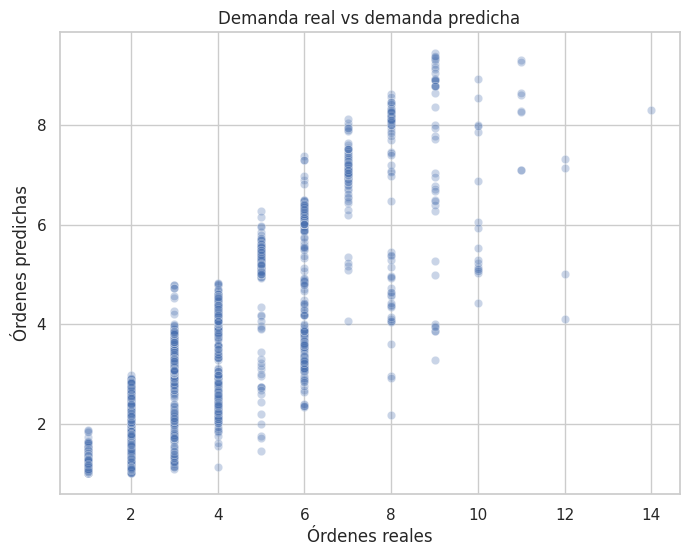

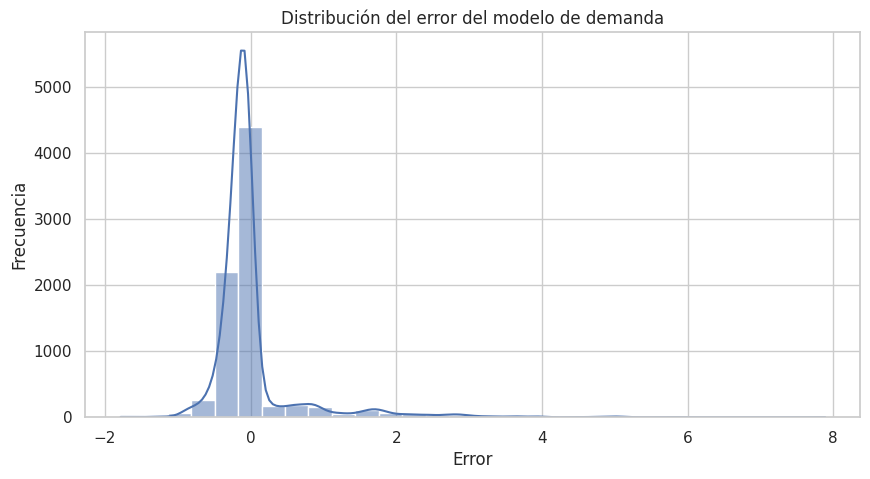

In [18]:
# =========================================================
# 17. MODELO PREDICTIVO DE DEMANDA HORARIA
# =========================================================

# ---------------------------------------------------------
# 17.1 Imports para modelado de demanda
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ---------------------------------------------------------
# 17.2 Definir dataset base para demanda
# ---------------------------------------------------------

df_demand_ml = df_demand_hourly.copy()

# ---------------------------------------------------------
# 17.3 Definir variable objetivo
# ---------------------------------------------------------

target_demand = "total_orders"

# ---------------------------------------------------------
# 17.4 Definir variables predictoras
# ---------------------------------------------------------

features_demand = [
    "order_year",
    "order_month",
    "order_week",
    "order_day",
    "order_dayofweek_num",
    "is_weekend",
    "order_hour",
    "order_channel",
    "avg_cart_size",
    "avg_num_customizations",
    "avg_total_spend",
    "avg_spend_per_item",
    "avg_customizations_per_item",
    "pct_rewards_member",
    "pct_has_food_item",
    "pct_order_ahead",
    "avg_customer_satisfaction",
    "avg_fulfillment_time_min"
]

X_demand = df_demand_ml[features_demand].copy()
y_demand = df_demand_ml[target_demand].copy()

# ---------------------------------------------------------
# 17.5 Separar variables categóricas y numéricas
# ---------------------------------------------------------

categorical_features_demand = X_demand.select_dtypes(include=["object"]).columns.tolist()
numeric_features_demand = X_demand.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()

print("Variables categóricas:")
print(categorical_features_demand)

print("\nVariables numéricas:")
print(numeric_features_demand)

# ---------------------------------------------------------
# 17.6 División train/test
# ---------------------------------------------------------

X_train_dem, X_test_dem, y_train_dem, y_test_dem = train_test_split(
    X_demand,
    y_demand,
    test_size=0.20,
    random_state=42
)

print("\nDimensiones:")
print(f"X_train: {X_train_dem.shape}")
print(f"X_test: {X_test_dem.shape}")
print(f"y_train: {y_train_dem.shape}")
print(f"y_test: {y_test_dem.shape}")

# ---------------------------------------------------------
# 17.7 Preprocesamiento
# ---------------------------------------------------------

preprocessor_demand = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_demand),
        ("num", StandardScaler(), numeric_features_demand)
    ]
)

# ---------------------------------------------------------
# 17.8 Definir modelos
# ---------------------------------------------------------

models_demand = {
    "Linear Regression": LinearRegression(),
    "Poisson Regressor": PoissonRegressor(
        alpha=0.1,
        max_iter=1000
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=80,
        random_state=42,
        n_jobs=-1,
        max_depth=10,
        min_samples_leaf=10
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.08
    )
}

# ---------------------------------------------------------
# 17.9 Entrenar y evaluar modelos
# ---------------------------------------------------------

demand_results = []
trained_demand_models = {}

for model_name, model in models_demand.items():
    
    print(f"Entrenando modelo: {model_name}")
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_demand),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train_dem, y_train_dem)
    
    y_pred_dem = pipeline.predict(X_test_dem)
    
    # Evitar predicciones negativas en modelos lineales
    y_pred_dem = np.maximum(y_pred_dem, 0)
    
    mae = mean_absolute_error(y_test_dem, y_pred_dem)
    rmse = np.sqrt(mean_squared_error(y_test_dem, y_pred_dem))
    r2 = r2_score(y_test_dem, y_pred_dem)
    
    demand_results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    trained_demand_models[model_name] = pipeline

df_demand_results = pd.DataFrame(demand_results).sort_values(by="MAE")

print("Resultados del modelo de demanda horaria:")
display(df_demand_results)

# ---------------------------------------------------------
# 17.10 Seleccionar mejor modelo
# ---------------------------------------------------------

best_demand_model_name = df_demand_results.iloc[0]["model"]
best_demand_model = trained_demand_models[best_demand_model_name]

print(f"Mejor modelo de demanda según MAE: {best_demand_model_name}")

# ---------------------------------------------------------
# 17.11 Comparación real vs predicho
# ---------------------------------------------------------

y_pred_best_dem = best_demand_model.predict(X_test_dem)
y_pred_best_dem = np.maximum(y_pred_best_dem, 0)

comparison_demand = pd.DataFrame({
    "real_total_orders": y_test_dem.values,
    "predicted_total_orders": y_pred_best_dem
})

comparison_demand["error"] = (
    comparison_demand["real_total_orders"] -
    comparison_demand["predicted_total_orders"]
)

comparison_demand["abs_error"] = comparison_demand["error"].abs()

print("\nComparación de demanda real vs predicha:")
display(comparison_demand.head(20))

print("\nEstadísticas del error absoluto:")
display(comparison_demand["abs_error"].describe().to_frame("abs_error"))

# ---------------------------------------------------------
# 17.12 Visualizaciones
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=comparison_demand["real_total_orders"],
    y=comparison_demand["predicted_total_orders"],
    alpha=0.3
)
plt.title("Demanda real vs demanda predicha")
plt.xlabel("Órdenes reales")
plt.ylabel("Órdenes predichas")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(
    comparison_demand["error"],
    bins=30,
    kde=True
)
plt.title("Distribución del error del modelo de demanda")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Interpretación del modelo de demanda:</strong> 


El mejor modelo fue: Random Forest Regressor

| Modelo                      |    MAE |   RMSE |     R² |
| --------------------------- | -----: | -----: | -----: |
| Random Forest Regressor     | 0.3123 | 0.6360 | 0.8726 |
| Gradient Boosting Regressor | 0.5007 | 0.7739 | 0.8114 |
| Linear Regression           | 1.2510 | 1.6378 | 0.1553 |
| Poisson Regressor           | 1.2648 | 1.6491 | 0.1436 |


El modelo se equivoca en promedio en 0.31 órdenes por fecha-hora-canal.

El R² = 0.8726 indica que el modelo explica aproximadamente el 87.3% de la variabilidad de la demanda horaria.

El modelo se equivoca en promedio en 0.31 órdenes por fecha-hora-canal.

El R² = 0.8726 indica que el modelo explica aproximadamente el 87.3% de la variabilidad de la demanda horaria.

</div>

# 18. INTEGRACIÓN DEL MODELO DE DEMANDA CON CÁLCULO DE CAPACIDAD

Resumen de capacidad predicha por escenario ML:


,scenario,total_predicted_orders,avg_predicted_orders_per_hour,median_predicted_orders_per_hour,p90_predicted_orders_per_hour,p95_predicted_orders_per_hour,max_predicted_orders_per_hour,avg_fulfillment_time_min,total_predicted_workload_min,avg_required_kiosks,median_required_kiosks,p90_required_kiosks,p95_required_kiosks,max_required_kiosks
0,Kiosk + In-Store Cashier - ML,"29,735.8646",2.6109,2.2250,5.0213,5.3956,10.2935,3.4417,"101,488.5803",0.1747,1.0000,1.0000,1.0000,1
1,Solo Kiosk - ML,"7,687.0426",1.3984,1.1074,2.1524,3.0394,7.0474,4.0141,"30,851.4703",0.1100,1.0000,1.0000,1.0000,1


Distribución de kioskos requeridos según predicción ML:


,scenario,predicted_required_kiosks,records,percentage
0,Kiosk + In-Store Cashier - ML,1,11389,100.0000
1,Solo Kiosk - ML,1,5497,100.0000


Top 20 casos con mayor requerimiento predicho de kioskos:


,scenario,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend,order_hour,predicted_total_orders,avg_fulfillment_time_min,predicted_workload_min,predicted_workload_hours,predicted_required_kiosks_exact,predicted_required_kiosks
5907,Kiosk + In-Store Cashier - ML,2024-01-27,2024,1,4,27,5,Saturday,1,8,10.2935,4.2143,41.1734,0.6862,0.8073,1
10013,Kiosk + In-Store Cashier - ML,2024-10-18,2024,10,42,18,4,Friday,0,12,9.2847,4.2679,36.7605,0.6127,0.7208,1
13450,Kiosk + In-Store Cashier - ML,2025-05-25,2025,5,21,25,6,Sunday,1,8,9.0931,3.8750,35.6631,0.5944,0.6993,1
7357,Kiosk + In-Store Cashier - ML,2024-04-30,2024,4,18,30,1,Tuesday,0,11,10.0665,3.9024,35.1776,0.5863,0.6898,1
14207,Kiosk + In-Store Cashier - ML,2025-07-12,2025,7,28,12,5,Saturday,1,6,9.2115,4.3881,34.9282,0.5821,0.6849,1
5507,Kiosk + In-Store Cashier - ML,2024-01-01,2024,1,1,1,0,Monday,0,16,7.3535,4.6292,34.8403,0.5807,0.6831,1
14674,Kiosk + In-Store Cashier - ML,2025-08-10,2025,8,32,10,6,Sunday,1,16,9.6807,3.7375,34.7534,0.5792,0.6814,1
8478,Kiosk + In-Store Cashier - ML,2024-07-10,2024,7,28,10,2,Wednesday,0,8,9.1023,3.8950,34.7364,0.5789,0.6811,1
15215,Kiosk + In-Store Cashier - ML,2025-09-13,2025,9,37,13,5,Saturday,1,15,10.2056,3.3900,34.5905,0.5765,0.6782,1
15888,Kiosk + In-Store Cashier - ML,2025-10-27,2025,10,44,27,0,Monday,0,6,8.3417,4.3071,34.0971,0.5683,0.6686,1


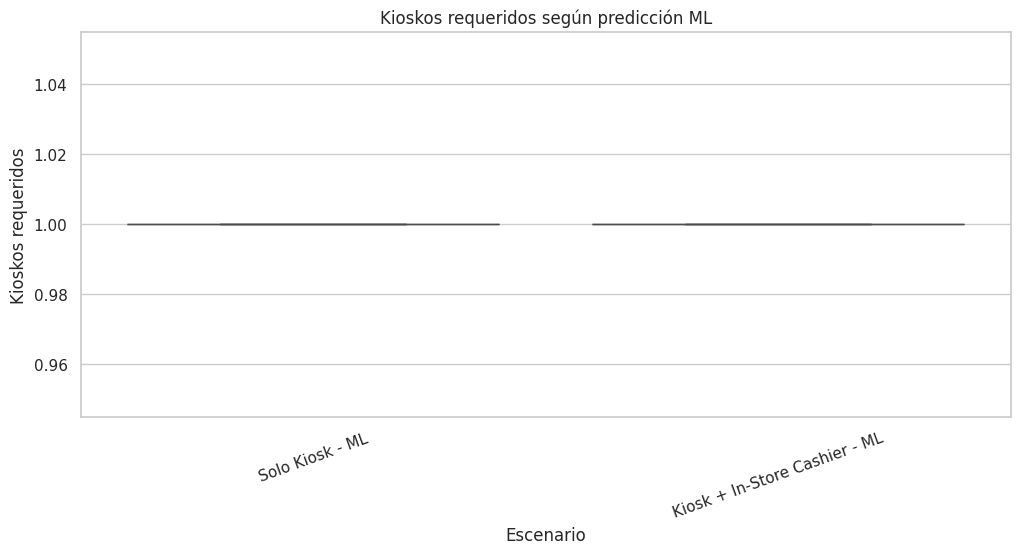

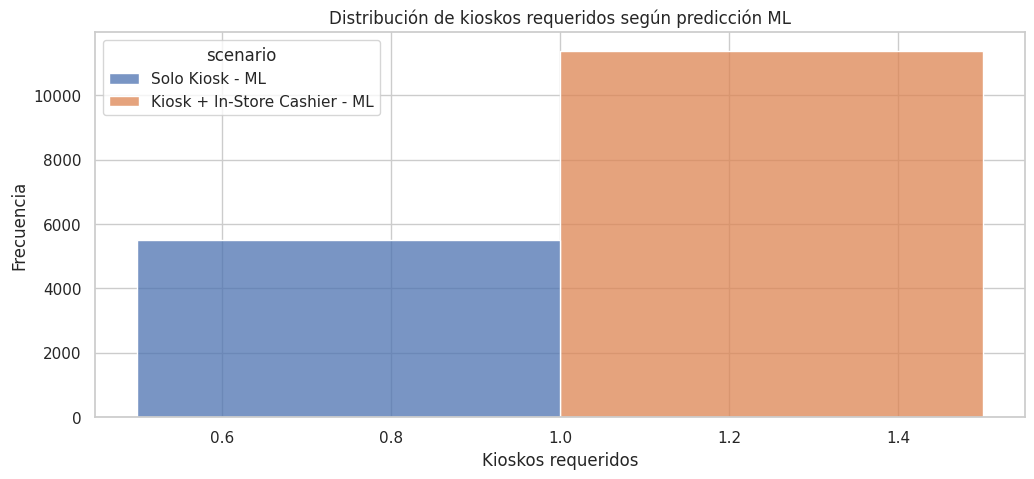

In [19]:
# =========================================================
# 18. INTEGRACIÓN DEL MODELO DE DEMANDA CON CÁLCULO DE CAPACIDAD
# =========================================================

# ---------------------------------------------------------
# 18.1 Crear dataset base para predicción de demanda
# ---------------------------------------------------------

df_capacity_ml = df_demand_hourly.copy()

# ---------------------------------------------------------
# 18.2 Predecir demanda horaria con el mejor modelo
# ---------------------------------------------------------

X_capacity_ml = df_capacity_ml[features_demand].copy()

df_capacity_ml["predicted_total_orders"] = best_demand_model.predict(X_capacity_ml)

# Evitar predicciones negativas
df_capacity_ml["predicted_total_orders"] = np.maximum(
    df_capacity_ml["predicted_total_orders"],
    0
)

# ---------------------------------------------------------
# 18.3 Calcular carga operativa predicha
# ---------------------------------------------------------

df_capacity_ml["predicted_workload_min"] = (
    df_capacity_ml["predicted_total_orders"] *
    df_capacity_ml["avg_fulfillment_time_min"]
)

df_capacity_ml["predicted_workload_hours"] = (
    df_capacity_ml["predicted_workload_min"] / 60
)

# ---------------------------------------------------------
# 18.4 Calcular kioskos requeridos por canal
# ---------------------------------------------------------

df_capacity_ml["predicted_required_kiosks_exact"] = (
    df_capacity_ml["predicted_workload_min"] /
    effective_capacity_per_kiosk
)

df_capacity_ml["predicted_required_kiosks"] = np.ceil(
    df_capacity_ml["predicted_required_kiosks_exact"]
).astype(int)

# ---------------------------------------------------------
# 18.5 Escenario 1: Solo Kiosk
# ---------------------------------------------------------

df_ml_kiosk = df_capacity_ml[
    df_capacity_ml["order_channel"] == "Kiosk"
].copy()

df_ml_kiosk["scenario"] = "Solo Kiosk - ML"

# ---------------------------------------------------------
# 18.6 Escenario 2: Kiosk + In-Store Cashier
# ---------------------------------------------------------

df_ml_combined = (
    df_capacity_ml[
        df_capacity_ml["order_channel"].isin(["Kiosk", "In-Store Cashier"])
    ]
    .groupby([
        "order_date_only",
        "order_year",
        "order_month",
        "order_week",
        "order_day",
        "order_dayofweek_num",
        "order_day_name",
        "is_weekend",
        "order_hour"
    ])
    .agg(
        predicted_total_orders=("predicted_total_orders", "sum"),
        predicted_workload_min=("predicted_workload_min", "sum"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean")
    )
    .reset_index()
)

df_ml_combined["scenario"] = "Kiosk + In-Store Cashier - ML"

df_ml_combined["predicted_workload_hours"] = (
    df_ml_combined["predicted_workload_min"] / 60
)

df_ml_combined["predicted_required_kiosks_exact"] = (
    df_ml_combined["predicted_workload_min"] /
    effective_capacity_per_kiosk
)

df_ml_combined["predicted_required_kiosks"] = np.ceil(
    df_ml_combined["predicted_required_kiosks_exact"]
).astype(int)

# ---------------------------------------------------------
# 18.7 Unificar escenarios ML
# ---------------------------------------------------------

cols_ml_capacity = [
    "scenario",
    "order_date_only",
    "order_year",
    "order_month",
    "order_week",
    "order_day",
    "order_dayofweek_num",
    "order_day_name",
    "is_weekend",
    "order_hour",
    "predicted_total_orders",
    "avg_fulfillment_time_min",
    "predicted_workload_min",
    "predicted_workload_hours",
    "predicted_required_kiosks_exact",
    "predicted_required_kiosks"
]

df_ml_scenarios = pd.concat([
    df_ml_kiosk[cols_ml_capacity],
    df_ml_combined[cols_ml_capacity]
], ignore_index=True)

# ---------------------------------------------------------
# 18.8 Resumen de capacidad predicha por escenario
# ---------------------------------------------------------

ml_capacity_summary = (
    df_ml_scenarios
    .groupby("scenario")
    .agg(
        total_predicted_orders=("predicted_total_orders", "sum"),
        avg_predicted_orders_per_hour=("predicted_total_orders", "mean"),
        median_predicted_orders_per_hour=("predicted_total_orders", "median"),
        p90_predicted_orders_per_hour=("predicted_total_orders", lambda x: x.quantile(0.90)),
        p95_predicted_orders_per_hour=("predicted_total_orders", lambda x: x.quantile(0.95)),
        max_predicted_orders_per_hour=("predicted_total_orders", "max"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean"),
        total_predicted_workload_min=("predicted_workload_min", "sum"),
        avg_required_kiosks=("predicted_required_kiosks_exact", "mean"),
        median_required_kiosks=("predicted_required_kiosks", "median"),
        p90_required_kiosks=("predicted_required_kiosks", lambda x: x.quantile(0.90)),
        p95_required_kiosks=("predicted_required_kiosks", lambda x: x.quantile(0.95)),
        max_required_kiosks=("predicted_required_kiosks", "max")
    )
    .reset_index()
)

print("Resumen de capacidad predicha por escenario ML:")
display(ml_capacity_summary)

# ---------------------------------------------------------
# 18.9 Distribución de kioskos predichos por escenario
# ---------------------------------------------------------

ml_kiosk_distribution = (
    df_ml_scenarios
    .groupby(["scenario", "predicted_required_kiosks"])
    .agg(records=("predicted_required_kiosks", "count"))
    .reset_index()
)

ml_kiosk_distribution["percentage"] = (
    ml_kiosk_distribution["records"] /
    ml_kiosk_distribution.groupby("scenario")["records"].transform("sum")
) * 100

print("Distribución de kioskos requeridos según predicción ML:")
display(ml_kiosk_distribution)

# ---------------------------------------------------------
# 18.10 Top casos con mayor capacidad predicha
# ---------------------------------------------------------

top_ml_capacity = (
    df_ml_scenarios
    .sort_values(
        by=["predicted_required_kiosks", "predicted_workload_min"],
        ascending=False
    )
    .head(20)
)

print("Top 20 casos con mayor requerimiento predicho de kioskos:")
display(top_ml_capacity)

# ---------------------------------------------------------
# 18.11 Visualizaciones
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_ml_scenarios,
    x="scenario",
    y="predicted_required_kiosks"
)
plt.title("Kioskos requeridos según predicción ML")
plt.xlabel("Escenario")
plt.ylabel("Kioskos requeridos")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(
    data=df_ml_scenarios,
    x="predicted_required_kiosks",
    hue="scenario",
    discrete=True,
    multiple="dodge"
)
plt.title("Distribución de kioskos requeridos según predicción ML")
plt.xlabel("Kioskos requeridos")
plt.ylabel("Frecuencia")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Interpretación de los resultados:</strong> 

| Escenario                | Órdenes reales aprox. | Órdenes predichas | Kioskos requeridos |
| ------------------------ | --------------------: | ----------------: | -----------------: |
| Solo Kiosk               |                 7.420 |             7.687 |                  1 |
| Kiosk + In-Store Cashier |                29.483 |            29.736 |                  1 |


1. El modelo predice una demanda muy cercana a la demanda real observada. Para el escenario combinado, predice aproximadamente: 29.736 órdenes frente a las 29.483 órdenes reales

2. Esto es una diferencia baja y valida que el modelo está capturando bien el comportamiento de demanda.

La conclusión es:

Con la demanda actual predicha por ML, 1 kiosko es suficiente para atender:

1. Solo Kiosk.
2. Kiosk + In-Store Cashier.

Además, el caso con mayor carga predicha tiene:

predicted_workload_min = 41.17 minutos
capacidad efectiva = 51 minutos
required_kiosks_exact = 0.8073
required_kiosks = 1

Es decir, incluso en el mayor caso estimado por el modelo, la carga no supera la capacidad efectiva de un kiosko.
   
</div>


# 19. ESCENARIOS FUTUROS CON PREDICCIÓN ML

Resumen de escenarios futuros con predicción ML:


,growth_scenario,growth_factor,avg_projected_orders,p90_projected_orders,p95_projected_orders,max_projected_orders,avg_projected_workload_min,p90_projected_workload_min,p95_projected_workload_min,max_projected_workload_min,avg_required_kiosks,median_required_kiosks,p90_required_kiosks,p95_required_kiosks,max_required_kiosks
0,Actual ML,1.0000,2.6109,5.0213,5.3956,10.2935,8.9111,16.7558,19.6095,41.1734,0.1747,1.0000,1.0000,1.0000,1
3,ML +25%,1.2500,3.2637,6.2766,6.7445,12.8669,11.1389,20.9448,24.5118,51.4668,0.2184,1.0000,1.0000,1.0000,2
5,ML +50%,1.5000,3.9164,7.5319,8.0934,15.4403,13.3667,25.1337,29.4142,61.7601,0.2621,1.0000,1.0000,1.0000,2
1,ML +100%,2.0000,5.2219,10.0425,10.7913,20.5871,17.8222,33.5116,39.2189,82.3468,0.3495,1.0000,1.0000,1.0000,2
2,ML +200%,3.0000,7.8328,15.0638,16.1869,30.8806,26.7333,50.2675,58.8284,123.5203,0.5242,1.0000,1.0000,2.0000,3
4,ML +300%,4.0000,10.4437,20.0851,21.5825,41.1741,35.6444,67.0233,78.4379,164.6937,0.6989,1.0000,2.0000,2.0000,4


Distribución de kioskos requeridos por escenario futuro ML:


,growth_scenario,growth_factor,required_kiosks,records,percentage
0,Actual ML,1.0000,1,11389,100.0000
6,ML +25%,1.2500,1,11388,99.9912
7,ML +25%,1.2500,2,1,0.0088
12,ML +50%,1.5000,1,11378,99.9034
13,ML +50%,1.5000,2,11,0.0966
1,ML +100%,2.0000,1,11265,98.9112
2,ML +100%,2.0000,2,124,1.0888
3,ML +200%,3.0000,1,10320,90.6138
4,ML +200%,3.0000,2,1058,9.2897
5,ML +200%,3.0000,3,11,0.0966


Top 20 casos con mayor requerimiento futuro ML:


,growth_scenario,growth_factor,order_date_only,order_day_name,is_weekend,order_hour,predicted_total_orders,projected_predicted_orders,avg_fulfillment_time_min,projected_predicted_workload_min,required_kiosks_exact,required_kiosks
57355,ML +300%,4.0000,2024-01-27,Saturday,1,8,10.2935,41.1741,4.2143,164.6937,3.2293,4
61461,ML +300%,4.0000,2024-10-18,Friday,0,12,9.2847,37.1389,4.2679,147.0420,2.8832,3
64898,ML +300%,4.0000,2025-05-25,Sunday,1,8,9.0931,36.3725,3.8750,142.6522,2.7971,3
58805,ML +300%,4.0000,2024-04-30,Tuesday,0,11,10.0665,40.2660,3.9024,140.7104,2.7590,3
65655,ML +300%,4.0000,2025-07-12,Saturday,1,6,9.2115,36.8461,4.3881,139.7128,2.7395,3
56955,ML +300%,4.0000,2024-01-01,Monday,0,16,7.3535,29.4141,4.6292,139.3612,2.7326,3
66122,ML +300%,4.0000,2025-08-10,Sunday,1,16,9.6807,38.7228,3.7375,139.0135,2.7258,3
59926,ML +300%,4.0000,2024-07-10,Wednesday,0,8,9.1023,36.4092,3.8950,138.9456,2.7244,3
66663,ML +300%,4.0000,2025-09-13,Saturday,1,15,10.2056,40.8224,3.3900,138.3619,2.7130,3
67336,ML +300%,4.0000,2025-10-27,Monday,0,6,8.3417,33.3670,4.3071,136.3885,2.6743,3


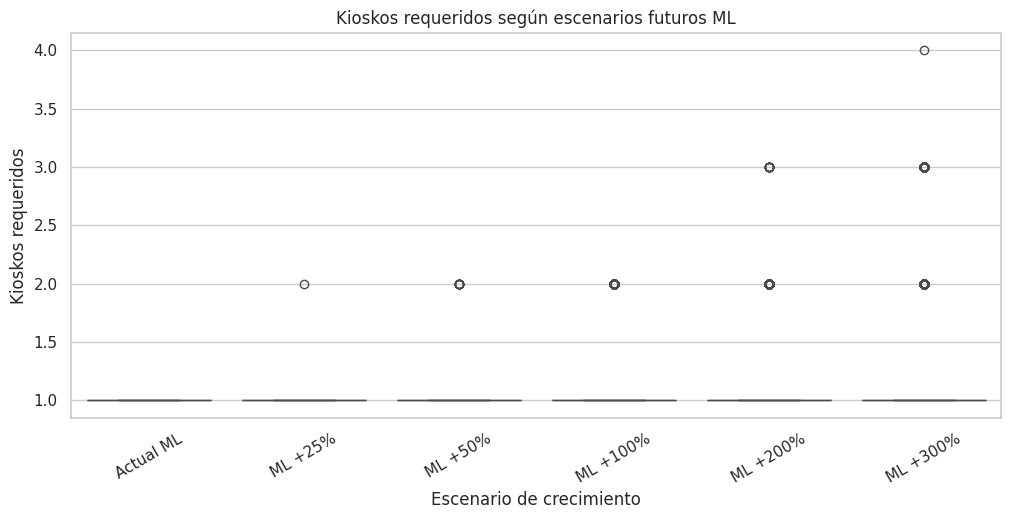

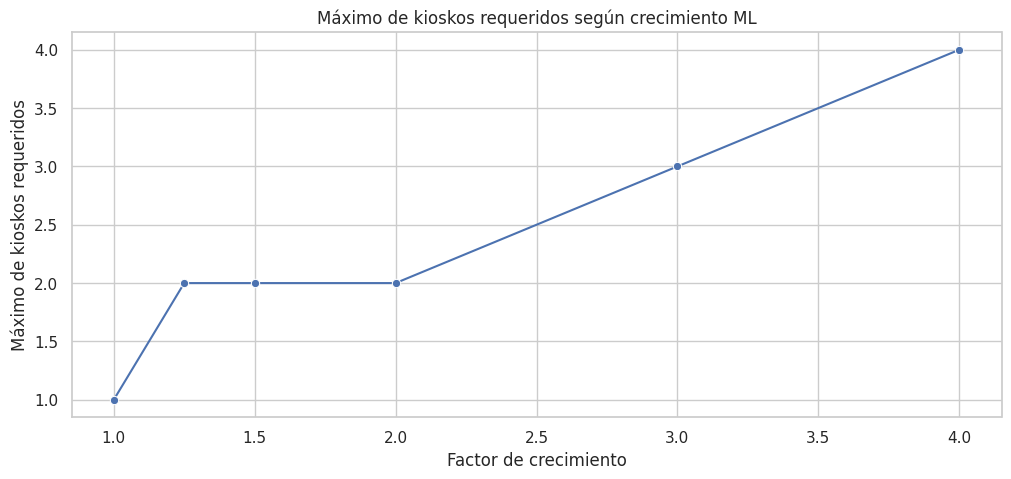

In [20]:
# =========================================================
# 19. ESCENARIOS FUTUROS CON PREDICCIÓN ML
# =========================================================

# ---------------------------------------------------------
# 19.1 Definir escenarios de crecimiento
# ---------------------------------------------------------

ml_growth_scenarios = {
    "Actual ML": 1.00,
    "ML +25%": 1.25,
    "ML +50%": 1.50,
    "ML +100%": 2.00,
    "ML +200%": 3.00,
    "ML +300%": 4.00
}

# ---------------------------------------------------------
# 19.2 Usar como base el escenario combinado predicho por ML
# ---------------------------------------------------------

df_ml_growth_base = df_ml_combined.copy()

ml_growth_results = []

for scenario_name, growth_factor in ml_growth_scenarios.items():
    
    temp = df_ml_growth_base.copy()
    
    temp["growth_scenario"] = scenario_name
    temp["growth_factor"] = growth_factor
    
    # Proyectar demanda y carga operativa
    temp["projected_predicted_orders"] = (
        temp["predicted_total_orders"] * growth_factor
    )
    
    temp["projected_predicted_workload_min"] = (
        temp["predicted_workload_min"] * growth_factor
    )
    
    temp["projected_predicted_workload_hours"] = (
        temp["projected_predicted_workload_min"] / 60
    )
    
    # Calcular kioskos requeridos
    temp["required_kiosks_exact"] = (
        temp["projected_predicted_workload_min"] /
        effective_capacity_per_kiosk
    )
    
    temp["required_kiosks"] = np.ceil(
        temp["required_kiosks_exact"]
    ).astype(int)
    
    ml_growth_results.append(temp)

df_ml_growth_scenarios = pd.concat(ml_growth_results, ignore_index=True)

# ---------------------------------------------------------
# 19.3 Resumen por escenario de crecimiento ML
# ---------------------------------------------------------

ml_growth_summary = (
    df_ml_growth_scenarios
    .groupby("growth_scenario")
    .agg(
        growth_factor=("growth_factor", "first"),
        avg_projected_orders=("projected_predicted_orders", "mean"),
        p90_projected_orders=("projected_predicted_orders", lambda x: x.quantile(0.90)),
        p95_projected_orders=("projected_predicted_orders", lambda x: x.quantile(0.95)),
        max_projected_orders=("projected_predicted_orders", "max"),
        avg_projected_workload_min=("projected_predicted_workload_min", "mean"),
        p90_projected_workload_min=("projected_predicted_workload_min", lambda x: x.quantile(0.90)),
        p95_projected_workload_min=("projected_predicted_workload_min", lambda x: x.quantile(0.95)),
        max_projected_workload_min=("projected_predicted_workload_min", "max"),
        avg_required_kiosks=("required_kiosks_exact", "mean"),
        median_required_kiosks=("required_kiosks", "median"),
        p90_required_kiosks=("required_kiosks", lambda x: x.quantile(0.90)),
        p95_required_kiosks=("required_kiosks", lambda x: x.quantile(0.95)),
        max_required_kiosks=("required_kiosks", "max")
    )
    .reset_index()
    .sort_values(by="growth_factor")
)

print("Resumen de escenarios futuros con predicción ML:")
display(ml_growth_summary)

# ---------------------------------------------------------
# 19.4 Distribución de kioskos por escenario ML
# ---------------------------------------------------------

ml_growth_distribution = (
    df_ml_growth_scenarios
    .groupby(["growth_scenario", "growth_factor", "required_kiosks"])
    .agg(records=("required_kiosks", "count"))
    .reset_index()
)

ml_growth_distribution["percentage"] = (
    ml_growth_distribution["records"] /
    ml_growth_distribution.groupby("growth_scenario")["records"].transform("sum")
) * 100

ml_growth_distribution = ml_growth_distribution.sort_values(
    by=["growth_factor", "required_kiosks"]
)

print("Distribución de kioskos requeridos por escenario futuro ML:")
display(ml_growth_distribution)

# ---------------------------------------------------------
# 19.5 Top casos con mayor requerimiento futuro ML
# ---------------------------------------------------------

top_ml_growth_cases = (
    df_ml_growth_scenarios
    .sort_values(
        by=["required_kiosks", "projected_predicted_workload_min"],
        ascending=False
    )
    .head(20)
)

print("Top 20 casos con mayor requerimiento futuro ML:")
display(top_ml_growth_cases[
    [
        "growth_scenario",
        "growth_factor",
        "order_date_only",
        "order_day_name",
        "is_weekend",
        "order_hour",
        "predicted_total_orders",
        "projected_predicted_orders",
        "avg_fulfillment_time_min",
        "projected_predicted_workload_min",
        "required_kiosks_exact",
        "required_kiosks"
    ]
])

# ---------------------------------------------------------
# 19.6 Visualización de escenarios futuros ML
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_ml_growth_scenarios,
    x="growth_scenario",
    y="required_kiosks"
)
plt.title("Kioskos requeridos según escenarios futuros ML")
plt.xlabel("Escenario de crecimiento")
plt.ylabel("Kioskos requeridos")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=ml_growth_summary,
    x="growth_factor",
    y="max_required_kiosks",
    marker="o"
)
plt.title("Máximo de kioskos requeridos según crecimiento ML")
plt.xlabel("Factor de crecimiento")
plt.ylabel("Máximo de kioskos requeridos")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Interpretación de escenarios futuros ML:</strong> 

| Escenario | Resultado principal                                                   |
| --------- | --------------------------------------------------------------------- |
| Actual ML | 1 kiosko cubre el 100% de los casos                                   |
| ML +25%   | Casi todos los casos requieren 1 kiosko; solo 1 caso requiere 2       |
| ML +50%   | 2 kioskos aparecen en 0.10% de los casos                              |
| ML +100%  | 2 kioskos aparecen en 1.09% de los casos                              |
| ML +200%  | 2 kioskos aparecen en 9.29% y 3 kioskos en 0.10%                      |
| ML +300%  | 2 kioskos aparecen en 20.84%, 3 kioskos en 1.08% y 4 kioskos en 0.01% |


1. Con la demanda actual predicha, 1 kiosko es suficiente.
2. Con crecimiento moderado de hasta 100%, 1 kiosko sigue cubriendo la mayoría de los casos.
3. A partir de +200% empieza a observarse una necesidad operativa más relevante de 2 kioskos.
4. Con +300%, 2 kioskos ya serían necesarios en cerca del 21% de los casos, y 3 kioskos en casos puntuales.

El escenario actual no presenta saturación de capacidad, ya que la carga máxima predicha no supera los 51 minutos efectivos por hora disponibles por kiosko. Por esta razón, se incorporaron escenarios de crecimiento de demanda como prueba de sensibilidad. Estos escenarios permiten identificar los umbrales a partir de los cuales la operación requeriría más de un kiosko. Bajo la predicción ML, el requerimiento de 2 kioskos empieza a aparecer marginalmente desde un crecimiento del 25%, pero se vuelve más relevante a partir de un crecimiento del 200%. En un escenario de estrés de +300%, aproximadamente el 20.84% de los registros horarios requerirían 2 kioskos

    
</div>

# 20. TABLA FINAL COMPARATIVA DE RESULTADOS

In [21]:
# =========================================================
# 20. TABLA FINAL COMPARATIVA DE RESULTADOS
# =========================================================

# ---------------------------------------------------------
# 20.1 Resumen observado: demanda real
# ---------------------------------------------------------

observed_summary_final = capacity_summary.copy()

observed_summary_final["method"] = "Cálculo observado"
observed_summary_final["scenario_group"] = observed_summary_final["scenario"]

observed_summary_final = observed_summary_final.rename(columns={
    "total_orders": "total_orders_estimated",
    "total_workload_min": "total_workload_min_estimated",
    "max_required_kiosks": "max_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "median_required_kiosks": "median_kiosks_required"
})

observed_summary_final = observed_summary_final[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 20.2 Resumen ML: demanda predicha actual
# ---------------------------------------------------------

ml_summary_final = ml_capacity_summary.copy()

ml_summary_final["method"] = "Predicción ML"
ml_summary_final["scenario_group"] = ml_summary_final["scenario"]

ml_summary_final = ml_summary_final.rename(columns={
    "total_predicted_orders": "total_orders_estimated",
    "avg_predicted_orders_per_hour": "avg_orders_per_hour",
    "p95_predicted_orders_per_hour": "p95_orders_per_hour",
    "max_predicted_orders_per_hour": "max_orders_per_hour",
    "total_predicted_workload_min": "total_workload_min_estimated",
    "max_required_kiosks": "max_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "median_required_kiosks": "median_kiosks_required"
})

ml_summary_final = ml_summary_final[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 20.3 Resumen ML: escenarios futuros
# ---------------------------------------------------------

ml_growth_summary_final = ml_growth_summary.copy()

ml_growth_summary_final["method"] = "Escenario futuro ML"
ml_growth_summary_final["scenario_group"] = ml_growth_summary_final["growth_scenario"]

ml_growth_summary_final = ml_growth_summary_final.rename(columns={
    "avg_projected_orders": "avg_orders_per_hour",
    "p95_projected_orders": "p95_orders_per_hour",
    "max_projected_orders": "max_orders_per_hour",
    "avg_projected_workload_min": "avg_workload_min",
    "max_projected_workload_min": "max_workload_min",
    "max_required_kiosks": "max_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "median_required_kiosks": "median_kiosks_required"
})

# En escenarios futuros no tenemos un total acumulado equivalente directo en esta tabla,
# lo calculamos desde df_ml_growth_scenarios.
total_orders_by_growth = (
    df_ml_growth_scenarios
    .groupby("growth_scenario")
    .agg(
        total_orders_estimated=("projected_predicted_orders", "sum"),
        total_workload_min_estimated=("projected_predicted_workload_min", "sum")
    )
    .reset_index()
)

ml_growth_summary_final = ml_growth_summary_final.merge(
    total_orders_by_growth,
    on="growth_scenario",
    how="left"
)

ml_growth_summary_final["avg_fulfillment_time_min"] = (
    ml_growth_summary_final["total_workload_min_estimated"] /
    ml_growth_summary_final["total_orders_estimated"]
)

ml_growth_summary_final = ml_growth_summary_final[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 20.4 Unificar tabla final
# ---------------------------------------------------------

final_comparison_table = pd.concat(
    [
        observed_summary_final,
        ml_summary_final,
        ml_growth_summary_final
    ],
    ignore_index=True
)

# Redondear columnas numéricas
numeric_cols_final = final_comparison_table.select_dtypes(include=["float64", "int64"]).columns

final_comparison_table[numeric_cols_final] = final_comparison_table[numeric_cols_final].round(4)

print("Tabla final comparativa de resultados:")
display(final_comparison_table)

# ---------------------------------------------------------
# 20.5 Exportar tabla final a CSV
# ---------------------------------------------------------

output_path = "tabla_final_dimensionamiento_kioskos.csv"
final_comparison_table.to_csv(output_path, index=False)

print(f"Tabla final exportada como: {output_path}")

Tabla final comparativa de resultados:


,method,scenario_group,total_orders_estimated,avg_orders_per_hour,p95_orders_per_hour,max_orders_per_hour,avg_fulfillment_time_min,total_workload_min_estimated,median_kiosks_required,p90_kiosks_required,p95_kiosks_required,max_kiosks_required
0,Cálculo observado,Kiosk + In-Store Cashier,"29,483.0000",2.5887,6.0000,11.0000,3.4417,"100,468.0000",1.0000,1.0000,1.0000,1
1,Cálculo observado,Solo Kiosk,"7,420.0000",1.3498,3.0000,7.0000,4.0141,"29,782.1000",1.0000,1.0000,1.0000,1
2,Predicción ML,Kiosk + In-Store Cashier - ML,"29,735.8646",2.6109,5.3956,10.2935,3.4417,"101,488.5803",1.0000,1.0000,1.0000,1
3,Predicción ML,Solo Kiosk - ML,"7,687.0426",1.3984,3.0394,7.0474,4.0141,"30,851.4703",1.0000,1.0000,1.0000,1
4,Escenario futuro ML,Actual ML,"29,735.8646",2.6109,5.3956,10.2935,3.4130,"101,488.5803",1.0000,1.0000,1.0000,1
5,Escenario futuro ML,ML +25%,"37,169.8307",3.2637,6.7445,12.8669,3.4130,"126,860.7254",1.0000,1.0000,1.0000,2
6,Escenario futuro ML,ML +50%,"44,603.7968",3.9164,8.0934,15.4403,3.4130,"152,232.8705",1.0000,1.0000,1.0000,2
7,Escenario futuro ML,ML +100%,"59,471.7291",5.2219,10.7913,20.5871,3.4130,"202,977.1607",1.0000,1.0000,1.0000,2
8,Escenario futuro ML,ML +200%,"89,207.5937",7.8328,16.1869,30.8806,3.4130,"304,465.7410",1.0000,1.0000,2.0000,3
9,Escenario futuro ML,ML +300%,"118,943.4582",10.4437,21.5825,41.1741,3.4130,"405,954.3214",1.0000,2.0000,2.0000,4


Tabla final exportada como: tabla_final_dimensionamiento_kioskos.csv


<div class="alert alert-block alert-info">
    <strong>Respuesta a las preguntas de negocio:</strong> 


Pregunta 1: ¿Cuántos equipos se utilizan o requieren para satisfacer las órdenes actuales que entran por order_channel = Kiosk?

Respuesta: De acuerdo con la demanda observada del dataset, el canal Kiosk registra 7.420 órdenes. Considerando una capacidad efectiva de 51 minutos por hora por kiosko, derivada de una utilización objetivo del 85%, el análisis muestra que 1 kiosko es suficiente para satisfacer la demanda actual del canal Kiosk.

Pregunta 2: ¿Cuántos kioskos se requieren para satisfacer las órdenes actuales que entran por Kiosk + In-Store Cashier?

Respuesta: Al combinar las órdenes actuales de Kiosk e In-Store Cashier, el volumen total asciende a 29.483 órdenes observadas. Bajo las condiciones actuales de demanda y tiempos de atención, el cálculo de capacidad indica que 1 kiosko también sería suficiente para atender este escenario ampliado.
    
</div>

<div class="alert alert-block alert-info">
    <strong>Resumen de los modelos generados:</strong> 

El análisis permitió construir un modelo híbrido compuesto por técnicas de Machine Learning y un modelo determinístico de capacidad operativa. En primer lugar, se entrenó un modelo de regresión para estimar el tiempo de atención de las órdenes, utilizando como variable objetivo fulfillment_time_min. Posteriormente, se construyó un modelo de demanda horaria para predecir el número de órdenes por fecha, hora y canal, siendo Random Forest Regressor el modelo con mejor desempeño, con un MAE de 0.3123 órdenes y un R² de 0.8726.

A partir de las predicciones de demanda y los tiempos promedio de atención, se calculó la carga operativa en minutos y se estimó el número de kioskos requeridos considerando una capacidad efectiva de 51 minutos por hora por equipo, equivalente a una utilización objetivo del 85%.

Los resultados muestran que, bajo la demanda actual observada, 1 kiosko es suficiente para atender tanto las órdenes actuales del canal Kiosk como el escenario ampliado Kiosk + In-Store Cashier. No obstante, los escenarios de crecimiento permiten identificar umbrales futuros de capacidad. En particular, a partir de un crecimiento del 200% el percentil 95 de la operación requiere 2 kioskos, mientras que en un escenario extremo de crecimiento del 300% el requerimiento máximo puede llegar hasta 4 kioskos.
    
</div>

<div class="alert alert-block alert-info">
    <strong>Aclaración:</strong> 

El modelo ML no se utiliza para justificar artificialmente una mayor demanda, sino para estimar la demanda esperada y evaluar escenarios futuros. Los escenarios de +25%, +50%, +100%, +200% y +300% corresponden a simulaciones de sensibilidad operativa, útiles para analizar posibles incrementos por migración de órdenes desde caja física hacia kioskos, expansión de adopción del canal o crecimiento del volumen transaccional.
    
</div>

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong> 

Ahora y como parte de nuestro trabajo, vamos a generar un nuevo escenario ML partiendo de que todas las órdenes, sin importar su canal original, son atendidas por kiosko. Es decir, toda la demanda va a ser atendida por kioskos. 

Usaremos dos componentes:

1. Modelo de duración:
   Simula cuánto tardaría cada orden si fuera atendida por Kiosk.

2. Modelo de demanda:
   Predice cuántas órdenes totales llegarían por fecha y hora, usando varios modelos ML.
    
</div>

# 21. ESCENARIO ML: TODAS LAS ÓRDENES ATENDIDAS POR KIOSKO

In [22]:
# =========================================================
# 21. ESCENARIO ML: TODAS LAS ÓRDENES ATENDIDAS POR KIOSKO
# =========================================================

# ---------------------------------------------------------
# 21.1 Crear copia del dataset a nivel orden
# ---------------------------------------------------------

df_all_orders_kiosk = df_model.copy()

# Simulamos que todas las órdenes, sin importar su canal original,
# serán atendidas por el canal Kiosk
df_all_orders_kiosk["original_order_channel"] = df_all_orders_kiosk["order_channel"]
df_all_orders_kiosk["order_channel"] = "Kiosk"

# ---------------------------------------------------------
# 21.2 Predecir duración como si todas las órdenes fueran Kiosk
# ---------------------------------------------------------

X_all_orders_kiosk_duration = df_all_orders_kiosk[features_duration].copy()

df_all_orders_kiosk["predicted_kiosk_fulfillment_time_min"] = (
    best_duration_model.predict(X_all_orders_kiosk_duration)
)

# Evitar tiempos negativos por seguridad
df_all_orders_kiosk["predicted_kiosk_fulfillment_time_min"] = np.maximum(
    df_all_orders_kiosk["predicted_kiosk_fulfillment_time_min"],
    0
)

print("Validación de duración predicha si todas las órdenes fueran Kiosk:")
display(
    df_all_orders_kiosk["predicted_kiosk_fulfillment_time_min"]
    .describe()
    .to_frame("predicted_kiosk_fulfillment_time_min")
)

# ---------------------------------------------------------
# 21.3 Construir dataset horario con todas las órdenes
# ---------------------------------------------------------

df_all_kiosk_hourly = (
    df_all_orders_kiosk
    .groupby([
        "order_date_only",
        "order_year",
        "order_month",
        "order_week",
        "order_day",
        "order_dayofweek_num",
        "order_day_name",
        "is_weekend",
        "order_hour"
    ])
    .agg(
        total_orders=("order_id", "count"),
        avg_cart_size=("cart_size", "mean"),
        avg_num_customizations=("num_customizations", "mean"),
        avg_total_spend=("total_spend", "mean"),
        avg_spend_per_item=("spend_per_item", "mean"),
        avg_customizations_per_item=("customizations_per_item", "mean"),
        pct_rewards_member=("is_rewards_member", "mean"),
        pct_has_food_item=("has_food_item", "mean"),
        pct_order_ahead=("order_ahead", "mean"),
        avg_customer_satisfaction=("customer_satisfaction", "mean"),
        avg_predicted_kiosk_fulfillment_time_min=("predicted_kiosk_fulfillment_time_min", "mean"),
        total_predicted_kiosk_workload_min=("predicted_kiosk_fulfillment_time_min", "sum")
    )
    .reset_index()
)

df_all_kiosk_hourly["total_predicted_kiosk_workload_hours"] = (
    df_all_kiosk_hourly["total_predicted_kiosk_workload_min"] / 60
)

print("Dimensiones del dataset horario - todas las órdenes como Kiosk:")
print(f"Filas: {df_all_kiosk_hourly.shape[0]:,}")
print(f"Columnas: {df_all_kiosk_hourly.shape[1]:,}")

print("\nPrimeras filas:")
display(df_all_kiosk_hourly.head())

print("\nEstadísticas de total_orders:")
display(df_all_kiosk_hourly["total_orders"].describe().to_frame("total_orders"))

# ---------------------------------------------------------
# 21.4 Definir variable objetivo y variables predictoras
# ---------------------------------------------------------

target_all_kiosk = "total_orders"

features_all_kiosk = [
    "order_year",
    "order_month",
    "order_week",
    "order_day",
    "order_dayofweek_num",
    "is_weekend",
    "order_hour",
    "avg_cart_size",
    "avg_num_customizations",
    "avg_total_spend",
    "avg_spend_per_item",
    "avg_customizations_per_item",
    "pct_rewards_member",
    "pct_has_food_item",
    "pct_order_ahead",
    "avg_customer_satisfaction",
    "avg_predicted_kiosk_fulfillment_time_min"
]

X_all_kiosk = df_all_kiosk_hourly[features_all_kiosk].copy()
y_all_kiosk = df_all_kiosk_hourly[target_all_kiosk].copy()

# ---------------------------------------------------------
# 21.5 Separar train/test
# ---------------------------------------------------------

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_kiosk,
    y_all_kiosk,
    test_size=0.20,
    random_state=42
)

print("\nDimensiones train/test:")
print(f"X_train: {X_train_all.shape}")
print(f"X_test: {X_test_all.shape}")
print(f"y_train: {y_train_all.shape}")
print(f"y_test: {y_test_all.shape}")

# ---------------------------------------------------------
# 21.6 Preprocesamiento
# ---------------------------------------------------------

categorical_features_all = X_all_kiosk.select_dtypes(include=["object"]).columns.tolist()
numeric_features_all = X_all_kiosk.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()

preprocessor_all_kiosk = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_all),
        ("num", StandardScaler(), numeric_features_all)
    ]
)

# ---------------------------------------------------------
# 21.7 Definir varios modelos ML
# ---------------------------------------------------------

models_all_kiosk = {
    "Linear Regression": LinearRegression(),
    "Poisson Regressor": PoissonRegressor(
        alpha=0.1,
        max_iter=1000
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=10,
        min_samples_leaf=10
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=42,
        n_estimators=120,
        max_depth=3,
        learning_rate=0.08
    )
}

# ---------------------------------------------------------
# 21.8 Entrenar y evaluar modelos
# ---------------------------------------------------------

all_kiosk_results = []
trained_all_kiosk_models = {}

for model_name, model in models_all_kiosk.items():
    
    print(f"Entrenando modelo: {model_name}")
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_all_kiosk),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train_all, y_train_all)
    
    y_pred_all = pipeline.predict(X_test_all)
    y_pred_all = np.maximum(y_pred_all, 0)
    
    mae = mean_absolute_error(y_test_all, y_pred_all)
    rmse = np.sqrt(mean_squared_error(y_test_all, y_pred_all))
    r2 = r2_score(y_test_all, y_pred_all)
    
    all_kiosk_results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    trained_all_kiosk_models[model_name] = pipeline

df_all_kiosk_results = pd.DataFrame(all_kiosk_results).sort_values(by="MAE")

print("Resultados de modelos ML - todas las órdenes atendidas por Kiosk:")
display(df_all_kiosk_results)

# ---------------------------------------------------------
# 21.9 Seleccionar mejor modelo
# ---------------------------------------------------------

best_all_kiosk_model_name = df_all_kiosk_results.iloc[0]["model"]
best_all_kiosk_model = trained_all_kiosk_models[best_all_kiosk_model_name]

print(f"Mejor modelo según MAE: {best_all_kiosk_model_name}")

# ---------------------------------------------------------
# 21.10 Comparación real vs predicho
# ---------------------------------------------------------

y_pred_best_all = best_all_kiosk_model.predict(X_test_all)
y_pred_best_all = np.maximum(y_pred_best_all, 0)

comparison_all_kiosk = pd.DataFrame({
    "real_total_orders": y_test_all.values,
    "predicted_total_orders": y_pred_best_all
})

comparison_all_kiosk["error"] = (
    comparison_all_kiosk["real_total_orders"] -
    comparison_all_kiosk["predicted_total_orders"]
)

comparison_all_kiosk["abs_error"] = comparison_all_kiosk["error"].abs()

print("\nComparación real vs predicho:")
display(comparison_all_kiosk.head(20))

print("\nEstadísticas del error absoluto:")
display(comparison_all_kiosk["abs_error"].describe().to_frame("abs_error"))

Validación de duración predicha si todas las órdenes fueran Kiosk:


,predicted_kiosk_fulfillment_time_min
count,"100,000.0000"
mean,4.0176
std,0.0234
min,3.6357
25%,4.0096
50%,4.0172
75%,4.0260
max,4.4386


Dimensiones del dataset horario - todas las órdenes como Kiosk:
Filas: 14,725
Columnas: 22

Primeras filas:


,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend,order_hour,total_orders,avg_cart_size,avg_num_customizations,avg_total_spend,avg_spend_per_item,avg_customizations_per_item,pct_rewards_member,pct_has_food_item,pct_order_ahead,avg_customer_satisfaction,avg_predicted_kiosk_fulfillment_time_min,total_predicted_kiosk_workload_min,total_predicted_kiosk_workload_hours
0,2024-01-01,2024,1,1,1,0,Monday,0,0,1,8.0000,1.0000,22.3800,2.7975,0.1250,0.0000,0.0000,0.0000,1.0000,4.0399,4.0399,0.0673
1,2024-01-01,2024,1,1,1,0,Monday,0,4,1,5.0000,1.0000,17.3700,3.4740,0.2000,1.0000,0.0000,1.0000,4.0000,4.0158,4.0158,0.0669
2,2024-01-01,2024,1,1,1,0,Monday,0,5,2,2.0000,2.5000,8.7250,4.3625,1.2500,0.0000,0.0000,0.0000,3.0000,4.0167,8.0334,0.1339
3,2024-01-01,2024,1,1,1,0,Monday,0,6,9,3.3333,2.3333,14.6589,4.6991,0.7944,0.5556,0.5556,0.4444,2.8889,4.0209,36.1882,0.6031
4,2024-01-01,2024,1,1,1,0,Monday,0,7,10,3.9000,1.9000,14.7490,3.9867,0.5110,0.5000,0.0000,0.1000,3.6000,4.0232,40.2321,0.6705



Estadísticas de total_orders:


...

,model,MAE,RMSE,R2
3,Gradient Boosting Regressor,1.3847,1.9457,0.8197
2,Random Forest Regressor,1.4801,2.1835,0.7729
0,Linear Regression,3.7106,4.4857,0.0417
1,Poisson Regressor,3.7397,4.5157,0.0289


Mejor modelo según MAE: Gradient Boosting Regressor

Comparación real vs predicho:


,real_total_orders,predicted_total_orders,error,abs_error
0,6,10.0548,-4.0548,4.0548
1,2,2.1380,-0.1380,0.1380
2,2,2.8403,-0.8403,0.8403
3,5,5.2297,-0.2297,0.2297
4,4,4.3684,-0.3684,0.3684
5,3,2.3417,0.6583,0.6583
6,11,11.0479,-0.0479,0.0479
7,12,8.8041,3.1959,3.1959
8,1,0.3847,0.6153,0.6153
9,11,10.2219,0.7781,0.7781



Estadísticas del error absoluto:


,abs_error
count,"2,945.0000"
mean,1.3847
std,1.3671
min,0.0002
25%,0.3366
50%,0.9884
75%,2.0033
max,11.5980


<div class="alert alert-block alert-info">
    <strong>Interpretación:</strong> 

Ahora el escenario es más exigente por el escenario planteado: Todas las órdenes del dataset, sin importar si venían de Mobile App, Drive-Thru, In-Store Cashier o Kiosk, serán atendidas por kiosko.

El dataset horario queda con:

14.725 registros fecha-hora
100.000 órdenes totales
Promedio: 6.79 órdenes por hora
Máximo: 27 órdenes por hora

El mejor modelo fue: Gradient Boosting Regressor.

Con:

MAE = 1.3847 órdenes
RMSE = 1.9457
R² = 0.8197

Esto significa que el modelo explica aproximadamente el 82% de la variabilidad de la demanda horaria total y se equivoca en promedio en 1.38 órdenes por hora. Para este escenario agregado es un resultado aceptable.

Un punto importante: la duración predicha como kiosko quedó muy concentrada alrededor de 4.01 minutos. Esto ocurre porque forzamos todas las órdenes a comportarse como Kiosk, y el modelo de duración aprendió que ese canal tiene tiempos bastante estables.

Ahora calculamos cuántos kioskos se requieren usando el mejor modelo de este escenario.
    
</div>

# 22. CÁLCULO DE KIOSKOS PARA ESCENARIO TOTAL CON ML

Resumen de capacidad ML - todos los canales atendidos por Kiosk:


,scenario,total_predicted_orders,avg_predicted_orders_per_hour,median_predicted_orders_per_hour,p90_predicted_orders_per_hour,p95_predicted_orders_per_hour,max_predicted_orders_per_hour,avg_predicted_kiosk_fulfillment_time_min,total_predicted_workload_min,avg_required_kiosks,median_required_kiosks,p90_required_kiosks,p95_required_kiosks,max_required_kiosks
0,Todos los canales atendidos por Kiosk - ML,"99,977.4452",6.7896,7.3874,11.7982,12.8974,18.1773,4.0197,"401,664.4071",0.5349,1.0000,1.0000,2.0000,2


Distribución de kioskos requeridos - todos los canales ML:


,required_kiosks,records,percentage
0,1,13896,94.3701
1,2,829,5.6299


Top 20 horas con mayor requerimiento de kioskos - todos los canales ML:


,scenario,order_date_only,order_day_name,is_weekend,order_hour,total_orders,predicted_total_orders,avg_predicted_kiosk_fulfillment_time_min,predicted_workload_min,required_kiosks_exact,required_kiosks
9976,Todos los canales atendidos por Kiosk - ML,2025-05-11,Sunday,1,7,20,18.1773,4.0090,72.8735,1.4289,2
11357,Todos los canales atendidos por Kiosk - ML,2025-07-18,Friday,0,7,17,17.7891,4.0219,71.5463,1.4029,2
5704,Todos los canales atendidos por Kiosk - ML,2024-10-10,Thursday,0,7,19,17.6221,4.0166,70.7803,1.3878,2
1372,Todos los canales atendidos por Kiosk - ML,2024-03-09,Saturday,1,7,17,17.4502,4.0131,70.0291,1.3731,2
13788,Todos los canales atendidos por Kiosk - ML,2025-11-15,Saturday,1,7,23,17.3048,4.0169,69.5120,1.3630,2
9375,Todos los canales atendidos por Kiosk - ML,2025-04-11,Friday,0,7,22,17.3152,4.0093,69.4213,1.3612,2
918,Todos los canales atendidos por Kiosk - ML,2024-02-15,Thursday,0,7,19,17.0582,4.0211,68.5924,1.3449,2
10116,Todos los canales atendidos por Kiosk - ML,2025-05-18,Sunday,1,7,22,16.9486,4.0155,68.0567,1.3344,2
8571,Todos los canales atendidos por Kiosk - ML,2025-03-02,Sunday,1,8,15,16.8217,4.0236,67.6844,1.3271,2
9208,Todos los canales atendidos por Kiosk - ML,2025-04-03,Thursday,0,7,17,16.9030,3.9999,67.6105,1.3257,2


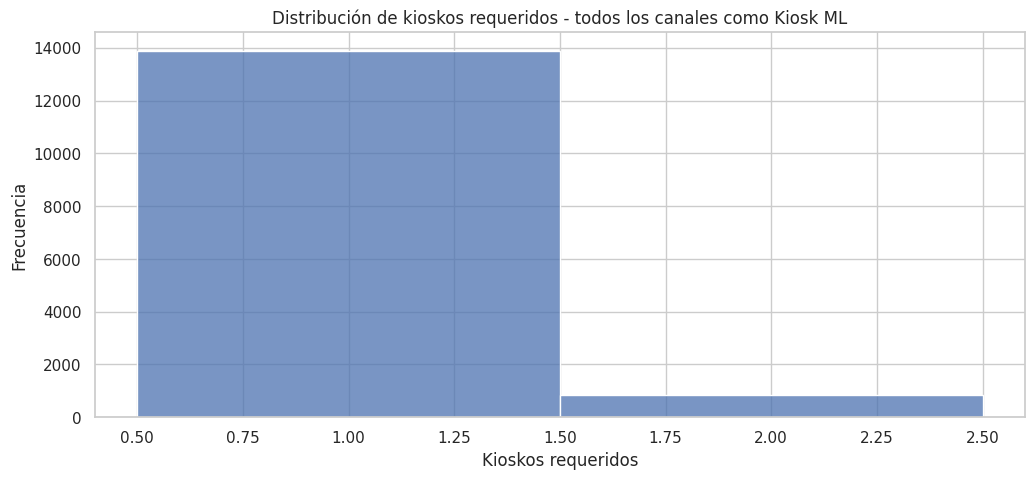

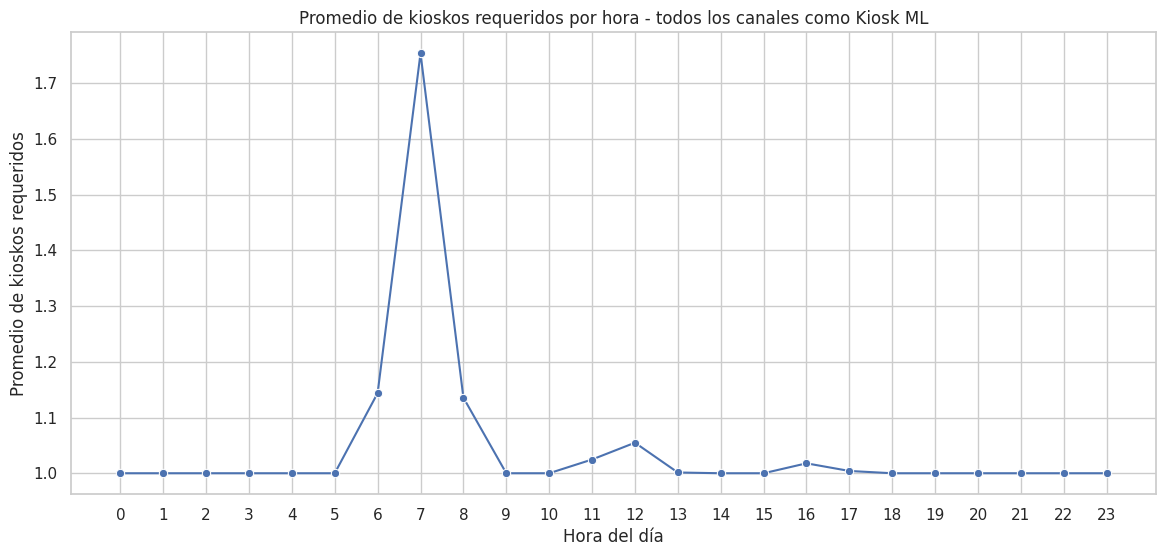

In [23]:
# =========================================================
# 22. CÁLCULO DE KIOSKOS PARA ESCENARIO TOTAL CON ML
# =========================================================

# ---------------------------------------------------------
# 22.1 Crear copia del dataset horario total
# ---------------------------------------------------------

df_all_kiosk_capacity_ml = df_all_kiosk_hourly.copy()

# ---------------------------------------------------------
# 22.2 Predecir demanda total horaria con el mejor modelo
# ---------------------------------------------------------

X_all_kiosk_capacity = df_all_kiosk_capacity_ml[features_all_kiosk].copy()

df_all_kiosk_capacity_ml["predicted_total_orders"] = (
    best_all_kiosk_model.predict(X_all_kiosk_capacity)
)

# Evitar predicciones negativas
df_all_kiosk_capacity_ml["predicted_total_orders"] = np.maximum(
    df_all_kiosk_capacity_ml["predicted_total_orders"],
    0
)

# ---------------------------------------------------------
# 22.3 Calcular workload predicho
# ---------------------------------------------------------

df_all_kiosk_capacity_ml["predicted_workload_min"] = (
    df_all_kiosk_capacity_ml["predicted_total_orders"] *
    df_all_kiosk_capacity_ml["avg_predicted_kiosk_fulfillment_time_min"]
)

df_all_kiosk_capacity_ml["predicted_workload_hours"] = (
    df_all_kiosk_capacity_ml["predicted_workload_min"] / 60
)

# ---------------------------------------------------------
# 22.4 Calcular kioskos requeridos
# ---------------------------------------------------------

df_all_kiosk_capacity_ml["required_kiosks_exact"] = (
    df_all_kiosk_capacity_ml["predicted_workload_min"] /
    effective_capacity_per_kiosk
)

df_all_kiosk_capacity_ml["required_kiosks"] = np.ceil(
    df_all_kiosk_capacity_ml["required_kiosks_exact"]
).astype(int)

df_all_kiosk_capacity_ml["scenario"] = "Todos los canales atendidos por Kiosk - ML"

# ---------------------------------------------------------
# 22.5 Resumen general del escenario
# ---------------------------------------------------------

all_kiosk_ml_summary = (
    df_all_kiosk_capacity_ml
    .groupby("scenario")
    .agg(
        total_predicted_orders=("predicted_total_orders", "sum"),
        avg_predicted_orders_per_hour=("predicted_total_orders", "mean"),
        median_predicted_orders_per_hour=("predicted_total_orders", "median"),
        p90_predicted_orders_per_hour=("predicted_total_orders", lambda x: x.quantile(0.90)),
        p95_predicted_orders_per_hour=("predicted_total_orders", lambda x: x.quantile(0.95)),
        max_predicted_orders_per_hour=("predicted_total_orders", "max"),
        avg_predicted_kiosk_fulfillment_time_min=("avg_predicted_kiosk_fulfillment_time_min", "mean"),
        total_predicted_workload_min=("predicted_workload_min", "sum"),
        avg_required_kiosks=("required_kiosks_exact", "mean"),
        median_required_kiosks=("required_kiosks", "median"),
        p90_required_kiosks=("required_kiosks", lambda x: x.quantile(0.90)),
        p95_required_kiosks=("required_kiosks", lambda x: x.quantile(0.95)),
        max_required_kiosks=("required_kiosks", "max")
    )
    .reset_index()
)

print("Resumen de capacidad ML - todos los canales atendidos por Kiosk:")
display(all_kiosk_ml_summary)

# ---------------------------------------------------------
# 22.6 Distribución de kioskos requeridos
# ---------------------------------------------------------

all_kiosk_ml_distribution = (
    df_all_kiosk_capacity_ml
    .groupby("required_kiosks")
    .agg(records=("required_kiosks", "count"))
    .reset_index()
)

all_kiosk_ml_distribution["percentage"] = (
    all_kiosk_ml_distribution["records"] /
    all_kiosk_ml_distribution["records"].sum()
) * 100

print("Distribución de kioskos requeridos - todos los canales ML:")
display(all_kiosk_ml_distribution)

# ---------------------------------------------------------
# 22.7 Top 20 casos con mayor requerimiento
# ---------------------------------------------------------

top_all_kiosk_ml_capacity = (
    df_all_kiosk_capacity_ml
    .sort_values(
        by=["required_kiosks", "predicted_workload_min"],
        ascending=False
    )
    .head(20)
)

print("Top 20 horas con mayor requerimiento de kioskos - todos los canales ML:")
display(top_all_kiosk_ml_capacity[
    [
        "scenario",
        "order_date_only",
        "order_day_name",
        "is_weekend",
        "order_hour",
        "total_orders",
        "predicted_total_orders",
        "avg_predicted_kiosk_fulfillment_time_min",
        "predicted_workload_min",
        "required_kiosks_exact",
        "required_kiosks"
    ]
])

# ---------------------------------------------------------
# 22.8 Visualizaciones
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
sns.histplot(
    data=df_all_kiosk_capacity_ml,
    x="required_kiosks",
    discrete=True
)
plt.title("Distribución de kioskos requeridos - todos los canales como Kiosk ML")
plt.xlabel("Kioskos requeridos")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_all_kiosk_capacity_ml.groupby("order_hour")
    .agg(avg_required_kiosks=("required_kiosks", "mean"))
    .reset_index(),
    x="order_hour",
    y="avg_required_kiosks",
    marker="o"
)
plt.title("Promedio de kioskos requeridos por hora - todos los canales como Kiosk ML")
plt.xlabel("Hora del día")
plt.ylabel("Promedio de kioskos requeridos")
plt.xticks(range(0, 24))
plt.show()

<div class="alert alert-block alert-info">
    <strong>Resultados:</strong> 

A la pregunta ¿Qué pasaría si toda la demanda actual de la tienda fuera atendida por kioskos? tenemos:

| Métrica                             |   Resultado |
| ----------------------------------- | ----------: |
| Órdenes predichas totales           |      99.977 |
| Promedio de órdenes por hora        |        6.79 |
| P95 de órdenes por hora             |       12.90 |
| Máximo de órdenes por hora          |       18.18 |
| Tiempo promedio estimado como Kiosk |    4.02 min |
| Carga total predicha                | 401.664 min |
| P95 de kioskos requeridos           |           2 |
| Máximo de kioskos requeridos        |           2 |


La distribución muestra:

| Kioskos requeridos | Registros | Porcentaje |
| -----------------: | --------: | ---------: |
|                  1 |    13.896 |     94.37% |
|                  2 |       829 |      5.63% |
    
</div>

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong>
Comparación con escenarios anteriores

| Escenario                    | Canales considerados | Máximo kioskos requeridos |
| ---------------------------- | -------------------- | ------------------------: |
| Solo Kiosk                   | Kiosk                |                         1 |
| Kiosk + In-Store Cashier     | Kiosk + caja física  |                         1 |
| Todos los canales como Kiosk | Todos los canales    |                         2 |

</div>

<div class="alert alert-block alert-info">
    <strong>Conclusión del escenario:</strong> 

Bajo este escenario total, donde todas las órdenes se atienden por kiosko, el resultado cambia frente a los escenarios anteriores:

La mayoría de las horas todavía podrían ser atendidas con 1 kiosko. Sin embargo, en el 5.63% de los registros horarios ya se requieren 2 kioskos.

Esto significa que, si toda la operación migrara a kioskos, ya no sería recomendable dimensionar únicamente con 1 equipo, porque habría un conjunto de horas pico donde la capacidad se superaría.

La conclusión operativa es:

Para una operación totalmente migrada a kioskos, el dimensionamiento recomendado sería considerar 2 kioskos para cubrir las horas de mayor demanda, especialmente en la franja de la mañana.


Mientras la demanda se limite a Kiosk o a Kiosk + In-Store Cashier, 1 kiosko es suficiente bajo las condiciones actuales. Sin embargo, si toda la demanda de la tienda se trasladara a kioskos, el modelo predice que se requerirían hasta 2 kioskos en las horas de mayor carga.

</div>

<div class="alert alert-block alert-info">
    <strong>Conclusión del modelo:</strong> 

Como escenario adicional, se simuló una migración total de la demanda hacia kioskos, considerando que todas las órdenes, independientemente de su canal original, serían atendidas mediante este tipo de equipo. Para ello, se utilizó el modelo de duración entrenado previamente, forzando el canal de atención a Kiosk, y posteriormente se entrenaron distintos modelos de demanda horaria.

El mejor desempeño fue obtenido por Gradient Boosting Regressor, con un MAE de 1.3847 órdenes y un R² de 0.8197. A partir de sus predicciones, se calculó la carga operativa considerando una capacidad efectiva de 51 minutos por hora por kiosko.

Los resultados muestran que, bajo una migración total de la demanda, el 94.37% de los registros horarios podrían ser atendidos con 1 kiosko. Sin embargo, el 5.63% de los registros requeriría 2 kioskos, especialmente en horas pico de la mañana, alrededor de las 7:00 a.m. Por lo tanto, para un escenario de atención total por kioskos, el dimensionamiento recomendado debería considerar 2 equipos para cubrir los picos de demanda.

    
</div>

# 23. TABLA FINAL COMPARATIVA ACTUALIZADA

In [24]:
# =========================================================
# 23. TABLA FINAL COMPARATIVA ACTUALIZADA
# =========================================================

# ---------------------------------------------------------
# 23.1 Resumen observado: demanda real
# ---------------------------------------------------------

observed_summary_final = capacity_summary.copy()

observed_summary_final["method"] = "Cálculo observado"
observed_summary_final["scenario_group"] = observed_summary_final["scenario"]

observed_summary_final = observed_summary_final.rename(columns={
    "total_orders": "total_orders_estimated",
    "total_workload_min": "total_workload_min_estimated",
    "max_required_kiosks": "max_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "median_required_kiosks": "median_kiosks_required"
})

observed_summary_final = observed_summary_final[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 23.2 Resumen ML: demanda predicha actual
# ---------------------------------------------------------

ml_summary_final = ml_capacity_summary.copy()

ml_summary_final["method"] = "Predicción ML"
ml_summary_final["scenario_group"] = ml_summary_final["scenario"]

ml_summary_final = ml_summary_final.rename(columns={
    "total_predicted_orders": "total_orders_estimated",
    "avg_predicted_orders_per_hour": "avg_orders_per_hour",
    "p95_predicted_orders_per_hour": "p95_orders_per_hour",
    "max_predicted_orders_per_hour": "max_orders_per_hour",
    "total_predicted_workload_min": "total_workload_min_estimated",
    "max_required_kiosks": "max_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "median_required_kiosks": "median_kiosks_required"
})

ml_summary_final = ml_summary_final[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 23.3 Resumen ML: escenarios futuros Kiosk + In-Store Cashier
# ---------------------------------------------------------

ml_growth_summary_final = ml_growth_summary.copy()

ml_growth_summary_final["method"] = "Escenario futuro ML"
ml_growth_summary_final["scenario_group"] = ml_growth_summary_final["growth_scenario"]

ml_growth_summary_final = ml_growth_summary_final.rename(columns={
    "avg_projected_orders": "avg_orders_per_hour",
    "p95_projected_orders": "p95_orders_per_hour",
    "max_projected_orders": "max_orders_per_hour",
    "max_required_kiosks": "max_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "median_required_kiosks": "median_kiosks_required"
})

total_orders_by_growth = (
    df_ml_growth_scenarios
    .groupby("growth_scenario")
    .agg(
        total_orders_estimated=("projected_predicted_orders", "sum"),
        total_workload_min_estimated=("projected_predicted_workload_min", "sum")
    )
    .reset_index()
)

ml_growth_summary_final = ml_growth_summary_final.merge(
    total_orders_by_growth,
    on="growth_scenario",
    how="left"
)

ml_growth_summary_final["avg_fulfillment_time_min"] = (
    ml_growth_summary_final["total_workload_min_estimated"] /
    ml_growth_summary_final["total_orders_estimated"]
)

ml_growth_summary_final = ml_growth_summary_final[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 23.4 Nuevo resumen ML: todos los canales atendidos por Kiosk
# ---------------------------------------------------------

all_kiosk_summary_final = all_kiosk_ml_summary.copy()

all_kiosk_summary_final["method"] = "Escenario total ML"
all_kiosk_summary_final["scenario_group"] = all_kiosk_summary_final["scenario"]

all_kiosk_summary_final = all_kiosk_summary_final.rename(columns={
    "total_predicted_orders": "total_orders_estimated",
    "avg_predicted_orders_per_hour": "avg_orders_per_hour",
    "p95_predicted_orders_per_hour": "p95_orders_per_hour",
    "max_predicted_orders_per_hour": "max_orders_per_hour",
    "avg_predicted_kiosk_fulfillment_time_min": "avg_fulfillment_time_min",
    "total_predicted_workload_min": "total_workload_min_estimated",
    "max_required_kiosks": "max_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "median_required_kiosks": "median_kiosks_required"
})

all_kiosk_summary_final = all_kiosk_summary_final[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 23.5 Unificar tabla final actualizada
# ---------------------------------------------------------

final_comparison_table_updated = pd.concat(
    [
        observed_summary_final,
        ml_summary_final,
        ml_growth_summary_final,
        all_kiosk_summary_final
    ],
    ignore_index=True
)

# ---------------------------------------------------------
# 23.6 Redondear columnas numéricas
# ---------------------------------------------------------

numeric_cols_final = final_comparison_table_updated.select_dtypes(
    include=["float64", "int64"]
).columns

final_comparison_table_updated[numeric_cols_final] = (
    final_comparison_table_updated[numeric_cols_final].round(4)
)

print("Tabla final comparativa actualizada:")
display(final_comparison_table_updated)

# ---------------------------------------------------------
# 23.7 Exportar tabla final actualizada
# ---------------------------------------------------------

output_path_updated = "tabla_final_dimensionamiento_kioskos_actualizada.csv"

final_comparison_table_updated.to_csv(
    output_path_updated,
    index=False
)

print(f"Tabla final actualizada exportada como: {output_path_updated}")

Tabla final comparativa actualizada:


,method,scenario_group,total_orders_estimated,avg_orders_per_hour,p95_orders_per_hour,max_orders_per_hour,avg_fulfillment_time_min,total_workload_min_estimated,median_kiosks_required,p90_kiosks_required,p95_kiosks_required,max_kiosks_required
0,Cálculo observado,Kiosk + In-Store Cashier,"29,483.0000",2.5887,6.0000,11.0000,3.4417,"100,468.0000",1.0000,1.0000,1.0000,1
1,Cálculo observado,Solo Kiosk,"7,420.0000",1.3498,3.0000,7.0000,4.0141,"29,782.1000",1.0000,1.0000,1.0000,1
2,Predicción ML,Kiosk + In-Store Cashier - ML,"29,735.8646",2.6109,5.3956,10.2935,3.4417,"101,488.5803",1.0000,1.0000,1.0000,1
3,Predicción ML,Solo Kiosk - ML,"7,687.0426",1.3984,3.0394,7.0474,4.0141,"30,851.4703",1.0000,1.0000,1.0000,1
4,Escenario futuro ML,Actual ML,"29,735.8646",2.6109,5.3956,10.2935,3.4130,"101,488.5803",1.0000,1.0000,1.0000,1
5,Escenario futuro ML,ML +25%,"37,169.8307",3.2637,6.7445,12.8669,3.4130,"126,860.7254",1.0000,1.0000,1.0000,2
6,Escenario futuro ML,ML +50%,"44,603.7968",3.9164,8.0934,15.4403,3.4130,"152,232.8705",1.0000,1.0000,1.0000,2
7,Escenario futuro ML,ML +100%,"59,471.7291",5.2219,10.7913,20.5871,3.4130,"202,977.1607",1.0000,1.0000,1.0000,2
8,Escenario futuro ML,ML +200%,"89,207.5937",7.8328,16.1869,30.8806,3.4130,"304,465.7410",1.0000,1.0000,2.0000,3
9,Escenario futuro ML,ML +300%,"118,943.4582",10.4437,21.5825,41.1741,3.4130,"405,954.3214",1.0000,2.0000,2.0000,4


Tabla final actualizada exportada como: tabla_final_dimensionamiento_kioskos_actualizada.csv


<div class="alert alert-block alert-info">
    <strong>Interpretación Tabla final comparativa:</strong> 
    
La tabla final comparativa permite consolidar los resultados del análisis observado, la predicción mediante Machine Learning y los escenarios de simulación. Bajo la demanda actual, tanto el escenario Solo Kiosk como el escenario Kiosk + In-Store Cashier requieren únicamente 1 kiosko, considerando una capacidad efectiva de 51 minutos por hora por equipo y una utilización objetivo del 85%.

El modelo de Machine Learning confirma esta conclusión, al estimar una demanda cercana a la observada y mantener el requerimiento máximo en 1 kiosko para los escenarios actuales. No obstante, los escenarios futuros muestran que el requerimiento de capacidad aumenta ante incrementos significativos de demanda. En particular, a partir de un crecimiento del 200%, el percentil 95 requiere 2 kioskos, mientras que en el escenario de crecimiento del 300% el requerimiento máximo puede alcanzar 4 kioskos.

Adicionalmente, se evaluó un escenario de migración total, en el cual todas las órdenes, independientemente de su canal original, serían atendidas por kiosko. En este caso, el modelo predice aproximadamente 99.977 órdenes y un requerimiento de 2 kioskos en el percentil 95 y en el máximo observado. Por lo tanto, si la estrategia de negocio busca migrar toda la demanda hacia kioskos, el dimensionamiento recomendado debería considerar 2 equipos para cubrir adecuadamente los picos operativos.

Escenario actual Kiosk: 1 kiosko
Escenario actual Kiosk + In-Store Cashier: 1 kiosko
Escenario total todos los canales como Kiosk: 2 kioskos

</div>

<div class="alert alert-block alert-info">
    <strong>Respuesta final a las preguntas de negocio:</strong>

1. ¿Cuántos equipos se utilizan para satisfacer las órdenes actuales de Kiosk?

Con base en la demanda actual del dataset, el canal Kiosk registra 7.420 órdenes. El cálculo observado y la predicción ML indican que se requiere 1 kiosko para atender esta demanda bajo una capacidad efectiva de 51 minutos por hora por equipo.

2. ¿Cuántos kioskos se requieren para satisfacer Kiosk + In-Store Cashier?

Al combinar Kiosk + In-Store Cashier, el volumen observado asciende a 29.483 órdenes. El modelo ML predice un valor muy similar, 29.736 órdenes. En ambos casos, el requerimiento sigue siendo 1 kiosko bajo las condiciones actuales.

3. ¿Qué pasa si todas las órdenes se atienden por kiosko?

En el escenario total, donde todas las órdenes de todos los canales se atienden por kiosko, el modelo predice aproximadamente 99.977 órdenes. En este caso, el requerimiento sube a 2 kioskos en el percentil 95 y máximo, por lo que la recomendación operativa sería dimensionar con 2 kioskos si se pretende absorber toda la demanda por este canal.

</div>

<div class="alert alert-block alert-info">
    <strong>Conclusión:</strong>

Con la demanda actual observada, tanto el escenario Solo Kiosk como el escenario Kiosk + In-Store Cashier requieren únicamente 1 kiosko. Esto se debe a que la carga operativa máxima por hora no supera la capacidad efectiva definida de 51 minutos por hora por kiosko, considerando una utilización objetivo del 85%.

El modelo de Machine Learning confirma esta misma conclusión. Para el escenario Kiosk + In-Store Cashier, el modelo predice aproximadamente 29.736 órdenes, muy cercano a las 29.483 órdenes observadas, y mantiene un requerimiento máximo de 1 kiosko.

Sin embargo, cuando se simulan escenarios de crecimiento, el requerimiento cambia. A partir del escenario ML +200%, el percentil 95 ya requiere 2 kioskos, y en el escenario ML +300% el requerimiento máximo alcanza 4 kioskos. Esto indica que, aunque la operación actual no está saturada, el modelo permite anticipar puntos de quiebre ante aumentos significativos de demanda.

El escenario más exigente y estratégico es Todos los canales atendidos por Kiosk - ML. En este caso, se consideran aproximadamente 99.977 órdenes y el modelo estima que el percentil 95 requiere 2 kioskos, con un máximo también de 2 kioskos. Esto significa que, si toda la demanda actual de los canales Mobile App, Drive-Thru, In-Store Cashier y Kiosk migrara a kioskos, ya no sería suficiente dimensionar la operación únicamente con 1 equipo para cubrir los picos de demanda.

</div>

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong> 

Ahora, se construye una extensión de predicción futura calendarizada. El objetivo es proyectar la demanda y la capacidad requerida para un periodo futuro específico, utilizando como base un calendario de enero de 2026. Para ello se generan variables temporales conocidas antes de la operación, como mes, día de la semana, fin de semana y hora.

Posteriormente se entrena un modelo operativo simple de demanda futura, usando únicamente variables calendarizables y el canal de atención. Este enfoque evita depender de variables que no se conocerían antes de la operación, como ticket promedio, tamaño del carrito o satisfacción del cliente.

Con este modelo se evalúan dos escenarios futuros: Kiosk + In-Store Cashier y Todos los canales atendidos por Kiosk. En cada caso se estima la demanda horaria, la carga operativa en minutos y el número de kioskos requeridos. Los resultados permiten identificar si la capacidad actual sería suficiente en un periodo futuro y si los picos horarios requerirían equipos adicionales.
</div>

# 24. CONSTRUCCIÓN DE CALENDARIO FUTURO PARA PREDICCIÓN

In [25]:
# =========================================================
# 24. CONSTRUCCIÓN DE CALENDARIO FUTURO PARA PREDICCIÓN
# =========================================================

# ---------------------------------------------------------
# 24.1 Definir rango de fechas futuras
# ---------------------------------------------------------

# Puedes modificar estas fechas según el periodo que quieras proyectar
future_start_date = "2026-01-01"
future_end_date = "2026-01-31"

future_dates = pd.date_range(
    start=future_start_date,
    end=future_end_date,
    freq="D"
)

# ---------------------------------------------------------
# 24.2 Definir horas operativas a proyectar
# ---------------------------------------------------------

# Usamos las 24 horas porque el dataset histórico tiene registros de 0 a 23
future_hours = list(range(0, 24))

# ---------------------------------------------------------
# 24.3 Crear calendario futuro fecha-hora
# ---------------------------------------------------------

future_calendar = pd.MultiIndex.from_product(
    [future_dates, future_hours],
    names=["future_date", "order_hour"]
).to_frame(index=False)

# ---------------------------------------------------------
# 24.4 Crear variables temporales futuras
# ---------------------------------------------------------

future_calendar["order_date_only"] = future_calendar["future_date"].dt.date
future_calendar["order_year"] = future_calendar["future_date"].dt.year
future_calendar["order_month"] = future_calendar["future_date"].dt.month
future_calendar["order_week"] = future_calendar["future_date"].dt.isocalendar().week.astype(int)
future_calendar["order_day"] = future_calendar["future_date"].dt.day
future_calendar["order_dayofweek_num"] = future_calendar["future_date"].dt.dayofweek
future_calendar["order_day_name"] = future_calendar["future_date"].dt.day_name()
future_calendar["is_weekend"] = future_calendar["order_dayofweek_num"].isin([5, 6]).astype(int)

# ---------------------------------------------------------
# 24.5 Validar calendario futuro
# ---------------------------------------------------------

print("Calendario futuro creado:")
print(f"Fecha inicial: {future_calendar['future_date'].min()}")
print(f"Fecha final: {future_calendar['future_date'].max()}")
print(f"Total registros fecha-hora: {future_calendar.shape[0]:,}")

print("\nPrimeras filas del calendario futuro:")
display(future_calendar.head(10))

print("\nDistribución por día de la semana:")
display(
    future_calendar["order_day_name"]
    .value_counts()
    .to_frame("conteo")
)

print("\nDistribución por hora:")
display(
    future_calendar["order_hour"]
    .value_counts()
    .sort_index()
    .to_frame("conteo")
)

Calendario futuro creado:
Fecha inicial: 2026-01-01 00:00:00
Fecha final: 2026-01-31 00:00:00
Total registros fecha-hora: 744

Primeras filas del calendario futuro:


,future_date,order_hour,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend
0,2026-01-01,0,2026-01-01,2026,1,1,1,3,Thursday,0
1,2026-01-01,1,2026-01-01,2026,1,1,1,3,Thursday,0
2,2026-01-01,2,2026-01-01,2026,1,1,1,3,Thursday,0
3,2026-01-01,3,2026-01-01,2026,1,1,1,3,Thursday,0
4,2026-01-01,4,2026-01-01,2026,1,1,1,3,Thursday,0
5,2026-01-01,5,2026-01-01,2026,1,1,1,3,Thursday,0
6,2026-01-01,6,2026-01-01,2026,1,1,1,3,Thursday,0
7,2026-01-01,7,2026-01-01,2026,1,1,1,3,Thursday,0
8,2026-01-01,8,2026-01-01,2026,1,1,1,3,Thursday,0
9,2026-01-01,9,2026-01-01,2026,1,1,1,3,Thursday,0



Distribución por día de la semana:


,conteo
order_day_name,
Thursday,120
Friday,120
Saturday,120
Sunday,96
Monday,96
Tuesday,96
Wednesday,96



Distribución por hora:


,conteo
order_hour,
0,31
1,31
2,31
3,31
4,31
5,31
6,31
7,31
8,31


# 25. MODELO OPERATIVO SIMPLE PARA PREDICCIÓN FUTURA

In [26]:
# =========================================================
# 25. MODELO OPERATIVO SIMPLE PARA PREDICCIÓN FUTURA
# =========================================================

# ---------------------------------------------------------
# 25.1 Crear dataset base
# ---------------------------------------------------------

df_demand_future_model = df_demand_hourly.copy()

# ---------------------------------------------------------
# 25.2 Definir target y variables predictoras calendarizables
# ---------------------------------------------------------

target_future_demand = "total_orders"

features_future_simple = [
    "order_month",
    "order_dayofweek_num",
    "is_weekend",
    "order_hour",
    "order_channel"
]

X_future_simple = df_demand_future_model[features_future_simple].copy()
y_future_simple = df_demand_future_model[target_future_demand].copy()

# ---------------------------------------------------------
# 25.3 Separar variables categóricas y numéricas
# ---------------------------------------------------------

categorical_features_future_simple = X_future_simple.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features_future_simple = X_future_simple.select_dtypes(
    include=["int64", "int32", "float64"]
).columns.tolist()

print("Variables categóricas:")
print(categorical_features_future_simple)

print("\nVariables numéricas:")
print(numeric_features_future_simple)

# ---------------------------------------------------------
# 25.4 Train/test
# ---------------------------------------------------------

X_train_future, X_test_future, y_train_future, y_test_future = train_test_split(
    X_future_simple,
    y_future_simple,
    test_size=0.20,
    random_state=42
)

# ---------------------------------------------------------
# 25.5 Preprocesamiento
# ---------------------------------------------------------

preprocessor_future_simple = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_future_simple),
        ("num", StandardScaler(), numeric_features_future_simple)
    ]
)

# ---------------------------------------------------------
# 25.6 Modelos a comparar
# ---------------------------------------------------------

models_future_simple = {
    "Linear Regression": LinearRegression(),
    "Poisson Regressor": PoissonRegressor(
        alpha=0.1,
        max_iter=1000
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=8,
        min_samples_leaf=20
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.08
    )
}

# ---------------------------------------------------------
# 25.7 Entrenar y evaluar modelos
# ---------------------------------------------------------

future_simple_results = []
trained_future_simple_models = {}

for model_name, model in models_future_simple.items():
    
    print(f"Entrenando modelo: {model_name}")
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_future_simple),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train_future, y_train_future)
    
    y_pred_future = pipeline.predict(X_test_future)
    y_pred_future = np.maximum(y_pred_future, 0)
    
    mae = mean_absolute_error(y_test_future, y_pred_future)
    rmse = np.sqrt(mean_squared_error(y_test_future, y_pred_future))
    r2 = r2_score(y_test_future, y_pred_future)
    
    future_simple_results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    trained_future_simple_models[model_name] = pipeline

df_future_simple_results = pd.DataFrame(future_simple_results).sort_values(by="MAE")

print("Resultados del modelo operativo simple para futuro:")
display(df_future_simple_results)

# ---------------------------------------------------------
# 25.8 Seleccionar mejor modelo
# ---------------------------------------------------------

best_future_simple_model_name = df_future_simple_results.iloc[0]["model"]
best_future_simple_model = trained_future_simple_models[best_future_simple_model_name]

print(f"Mejor modelo operativo simple: {best_future_simple_model_name}")

Variables categóricas:
['order_channel']

Variables numéricas:
['order_month', 'order_dayofweek_num', 'is_weekend', 'order_hour']
Entrenando modelo: Linear Regression
Entrenando modelo: Poisson Regressor
Entrenando modelo: Random Forest Regressor
Entrenando modelo: Gradient Boosting Regressor
Resultados del modelo operativo simple para futuro:


,model,MAE,RMSE,R2
2,Random Forest Regressor,1.0034,1.3717,0.4075
3,Gradient Boosting Regressor,1.0072,1.3704,0.4086
0,Linear Regression,1.2506,1.6376,0.1555
1,Poisson Regressor,1.2621,1.6434,0.1495


Mejor modelo operativo simple: Random Forest Regressor


<div class="alert alert-block alert-info">
    <strong>Interpretación del resultado:</strong> 



Para enero de 2026, en el escenario:

Futuro Kiosk + In-Store Cashier - Modelo simple

el modelo predice:

| Métrica                      |    Resultado |
| ---------------------------- | -----------: |
| Órdenes futuras estimadas    |     2.288,74 |
| Promedio de órdenes por hora |         3,08 |
| P95 órdenes por hora         |         4,19 |
| Máximo órdenes por hora      |         4,76 |
| Tiempo promedio estimado     |     3,61 min |
| Workload total estimado      | 8.090,59 min |
| P95 kioskos requeridos       |            1 |
| Máximo kioskos requeridos    |            1 |

La distribución es:

| Kioskos requeridos | Registros | Porcentaje |
| -----------------: | --------: | ---------: |
|                  1 |       744 |       100% |


</div>

<div class="alert alert-block alert-info">
    <strong>Conslusión:</strong> 
    
Como extensión del análisis, se construyó una predicción calendarizada futura para enero de 2026. Para evitar problemas de extrapolación con variables no disponibles en el futuro, se entrenó un modelo operativo simple utilizando únicamente variables calendarizables: mes, día de la semana, indicador de fin de semana, hora y canal.

A diferencia del primer intento de predicción futura, este enfoque generó un patrón horario coherente con el comportamiento histórico, concentrando la mayor carga en la franja de la mañana, especialmente alrededor de las 7:00 a.m.

Los resultados muestran que, para el escenario futuro Kiosk + In-Store Cashier, el modelo estima 2.288,74 órdenes durante enero de 2026, con un promedio de 3,08 órdenes por hora y una carga máxima aproximada de 16,53 minutos por hora. Bajo una capacidad efectiva de 51 minutos por hora por kiosko, el requerimiento máximo sigue siendo de 1 kiosko. Por lo tanto, la predicción calendarizada futura confirma que un kiosko sería suficiente para cubrir la demanda esperada de este escenario.

# 26. PREDICCIÓN FUTURA - KIOSK + IN-STORE CASHIER

Resumen futuro corregido - Kiosk + In-Store Cashier:


,scenario,total_predicted_orders,avg_predicted_orders_per_hour,p90_predicted_orders_per_hour,p95_predicted_orders_per_hour,max_predicted_orders_per_hour,avg_fulfillment_time_min,total_predicted_workload_min,median_required_kiosks,p90_required_kiosks,p95_required_kiosks,max_required_kiosks
0,Futuro Kiosk + In-Store Cashier - Modelo simple,"2,288.7373",3.0763,4.1340,4.1904,4.7617,3.6088,"8,090.5921",1.0000,1.0000,1.0000,1


Distribución futura corregida de kioskos requeridos:


,required_kiosks,records,percentage
0,1,744,100.0000


Top 20 horas futuras corregidas con mayor carga:


,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend,order_hour,predicted_total_orders,predicted_workload_min,avg_fulfillment_time_min,predicted_workload_hours,required_kiosks_exact,required_kiosks,scenario
127,2026-01-06,2026,1,2,6,1,Tuesday,0,7,4.7617,16.5281,3.6088,0.2755,0.3241,1,Futuro Kiosk + In-Store Cashier - Modelo simple
295,2026-01-13,2026,1,3,13,1,Tuesday,0,7,4.7617,16.5281,3.6088,0.2755,0.3241,1,Futuro Kiosk + In-Store Cashier - Modelo simple
463,2026-01-20,2026,1,4,20,1,Tuesday,0,7,4.7617,16.5281,3.6088,0.2755,0.3241,1,Futuro Kiosk + In-Store Cashier - Modelo simple
631,2026-01-27,2026,1,5,27,1,Tuesday,0,7,4.7617,16.5281,3.6088,0.2755,0.3241,1,Futuro Kiosk + In-Store Cashier - Modelo simple
103,2026-01-05,2026,1,2,5,0,Monday,0,7,4.7600,16.5213,3.6088,0.2754,0.3239,1,Futuro Kiosk + In-Store Cashier - Modelo simple
271,2026-01-12,2026,1,3,12,0,Monday,0,7,4.7600,16.5213,3.6088,0.2754,0.3239,1,Futuro Kiosk + In-Store Cashier - Modelo simple
439,2026-01-19,2026,1,4,19,0,Monday,0,7,4.7600,16.5213,3.6088,0.2754,0.3239,1,Futuro Kiosk + In-Store Cashier - Modelo simple
607,2026-01-26,2026,1,5,26,0,Monday,0,7,4.7600,16.5213,3.6088,0.2754,0.3239,1,Futuro Kiosk + In-Store Cashier - Modelo simple
151,2026-01-07,2026,1,2,7,2,Wednesday,0,7,4.7504,16.4825,3.6088,0.2747,0.3232,1,Futuro Kiosk + In-Store Cashier - Modelo simple
319,2026-01-14,2026,1,3,14,2,Wednesday,0,7,4.7504,16.4825,3.6088,0.2747,0.3232,1,Futuro Kiosk + In-Store Cashier - Modelo simple


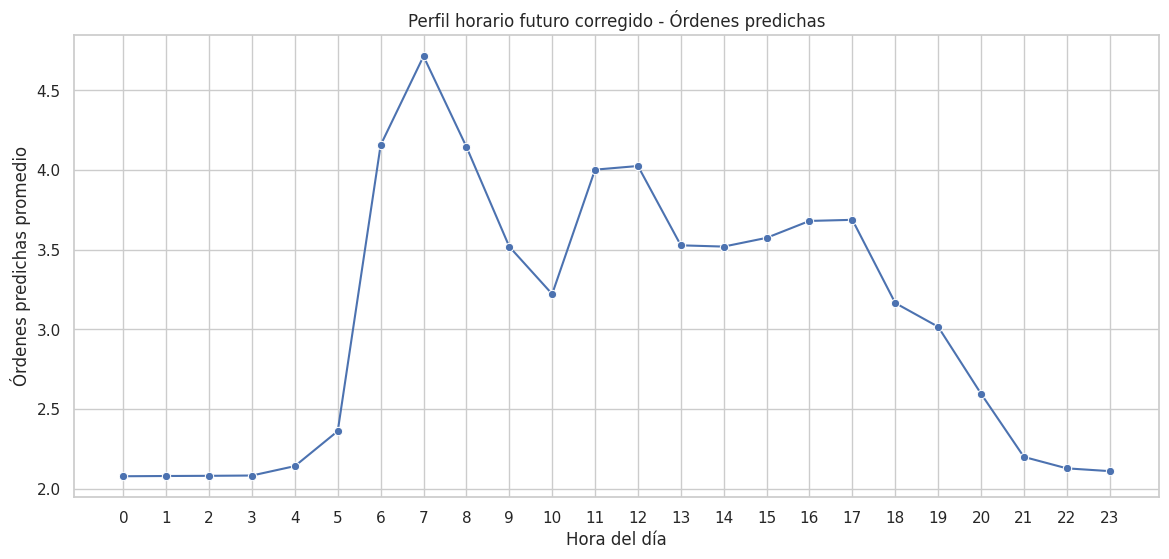

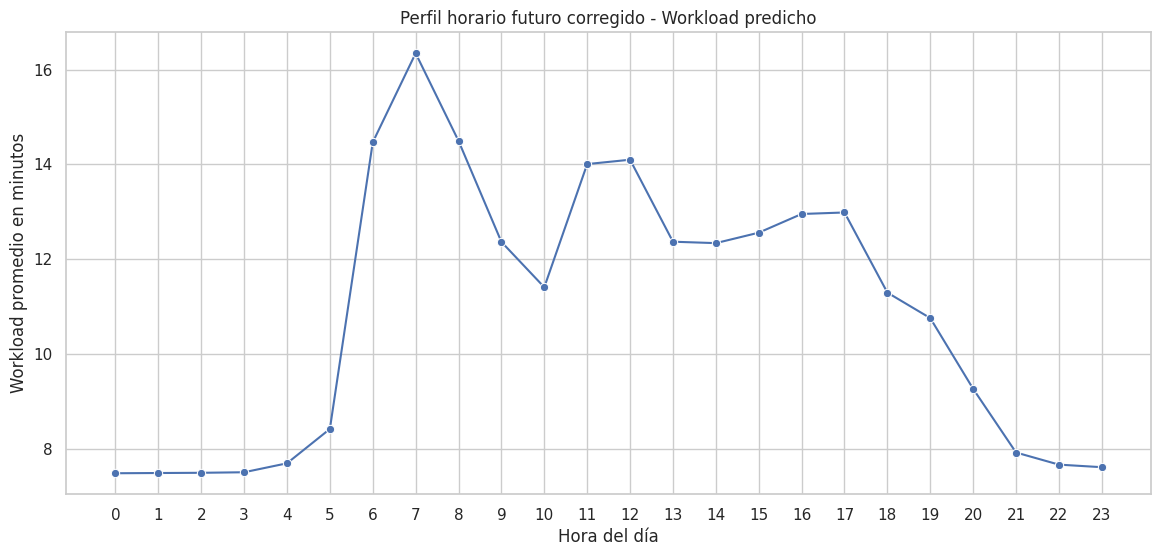

In [27]:
# =========================================================
# 26. PREDICCIÓN FUTURA - KIOSK + IN-STORE CASHIER
# =========================================================

# ---------------------------------------------------------
# 26.1 Crear registros futuros por canal
# ---------------------------------------------------------

future_channels_focus = ["Kiosk", "In-Store Cashier"]

future_focus_simple = future_calendar.merge(
    pd.DataFrame({"order_channel": future_channels_focus}),
    how="cross"
)

# ---------------------------------------------------------
# 26.2 Predecir demanda futura con modelo operativo simple
# ---------------------------------------------------------

X_future_focus_simple = future_focus_simple[features_future_simple].copy()

future_focus_simple["predicted_total_orders"] = (
    best_future_simple_model.predict(X_future_focus_simple)
)

future_focus_simple["predicted_total_orders"] = np.maximum(
    future_focus_simple["predicted_total_orders"],
    0
)

# ---------------------------------------------------------
# 26.3 Asignar tiempo promedio histórico por canal
# ---------------------------------------------------------

avg_time_by_channel = (
    df_model
    .groupby("order_channel")
    .agg(avg_fulfillment_time_min=("fulfillment_time_min", "mean"))
    .reset_index()
)

future_focus_simple = future_focus_simple.merge(
    avg_time_by_channel,
    on="order_channel",
    how="left"
)

# ---------------------------------------------------------
# 26.4 Calcular workload futuro por canal
# ---------------------------------------------------------

future_focus_simple["predicted_workload_min"] = (
    future_focus_simple["predicted_total_orders"] *
    future_focus_simple["avg_fulfillment_time_min"]
)

# ---------------------------------------------------------
# 28.5 Consolidar Kiosk + In-Store Cashier por fecha-hora
# ---------------------------------------------------------

future_focus_capacity_simple = (
    future_focus_simple
    .groupby([
        "order_date_only",
        "order_year",
        "order_month",
        "order_week",
        "order_day",
        "order_dayofweek_num",
        "order_day_name",
        "is_weekend",
        "order_hour"
    ])
    .agg(
        predicted_total_orders=("predicted_total_orders", "sum"),
        predicted_workload_min=("predicted_workload_min", "sum"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean")
    )
    .reset_index()
)

future_focus_capacity_simple["predicted_workload_hours"] = (
    future_focus_capacity_simple["predicted_workload_min"] / 60
)

future_focus_capacity_simple["required_kiosks_exact"] = (
    future_focus_capacity_simple["predicted_workload_min"] /
    effective_capacity_per_kiosk
)

future_focus_capacity_simple["required_kiosks"] = np.ceil(
    future_focus_capacity_simple["required_kiosks_exact"]
).astype(int)

future_focus_capacity_simple["scenario"] = "Futuro Kiosk + In-Store Cashier - Modelo simple"

# ---------------------------------------------------------
# 26.6 Resumen corregido
# ---------------------------------------------------------

future_focus_summary_simple = (
    future_focus_capacity_simple
    .groupby("scenario")
    .agg(
        total_predicted_orders=("predicted_total_orders", "sum"),
        avg_predicted_orders_per_hour=("predicted_total_orders", "mean"),
        p90_predicted_orders_per_hour=("predicted_total_orders", lambda x: x.quantile(0.90)),
        p95_predicted_orders_per_hour=("predicted_total_orders", lambda x: x.quantile(0.95)),
        max_predicted_orders_per_hour=("predicted_total_orders", "max"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean"),
        total_predicted_workload_min=("predicted_workload_min", "sum"),
        median_required_kiosks=("required_kiosks", "median"),
        p90_required_kiosks=("required_kiosks", lambda x: x.quantile(0.90)),
        p95_required_kiosks=("required_kiosks", lambda x: x.quantile(0.95)),
        max_required_kiosks=("required_kiosks", "max")
    )
    .reset_index()
)

print("Resumen futuro corregido - Kiosk + In-Store Cashier:")
display(future_focus_summary_simple)

# ---------------------------------------------------------
# 26.7 Distribución corregida de kioskos requeridos
# ---------------------------------------------------------

future_focus_distribution_simple = (
    future_focus_capacity_simple
    .groupby("required_kiosks")
    .agg(records=("required_kiosks", "count"))
    .reset_index()
)

future_focus_distribution_simple["percentage"] = (
    future_focus_distribution_simple["records"] /
    future_focus_distribution_simple["records"].sum()
) * 100

print("Distribución futura corregida de kioskos requeridos:")
display(future_focus_distribution_simple)

# ---------------------------------------------------------
# 26.8 Top 20 horas futuras con mayor carga
# ---------------------------------------------------------

top_future_focus_simple = (
    future_focus_capacity_simple
    .sort_values(
        by=["required_kiosks", "predicted_workload_min"],
        ascending=False
    )
    .head(20)
)

print("Top 20 horas futuras corregidas con mayor carga:")
display(top_future_focus_simple)

# ---------------------------------------------------------
# 26.9 Visualización por hora
# ---------------------------------------------------------

future_hourly_profile_simple = (
    future_focus_capacity_simple
    .groupby("order_hour")
    .agg(
        avg_predicted_orders=("predicted_total_orders", "mean"),
        avg_predicted_workload_min=("predicted_workload_min", "mean"),
        avg_required_kiosks=("required_kiosks", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=future_hourly_profile_simple,
    x="order_hour",
    y="avg_predicted_orders",
    marker="o"
)
plt.title("Perfil horario futuro corregido - Órdenes predichas")
plt.xlabel("Hora del día")
plt.ylabel("Órdenes predichas promedio")
plt.xticks(range(0, 24))
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=future_hourly_profile_simple,
    x="order_hour",
    y="avg_predicted_workload_min",
    marker="o"
)
plt.title("Perfil horario futuro corregido - Workload predicho")
plt.xlabel("Hora del día")
plt.ylabel("Workload promedio en minutos")
plt.xticks(range(0, 24))
plt.show()

<div class="alert alert-block alert-info">
    <strong>Interpretación:</strong>

Como extensión del análisis, se construyó una predicción calendarizada futura para enero de 2026. Para evitar problemas de extrapolación con variables no disponibles en el futuro, se entrenó un modelo operativo simple utilizando únicamente variables calendarizables: mes, día de la semana, indicador de fin de semana, hora y canal.

Este enfoque generó un patrón horario coherente con el comportamiento histórico, concentrando la mayor carga en la franja de la mañana, especialmente alrededor de las 7:00 a.m.

Los resultados muestran que, para el escenario futuro Kiosk + In-Store Cashier, el modelo estima 2.288,74 órdenes durante enero de 2026, con un promedio de 3,08 órdenes por hora y una carga máxima aproximada de 16,53 minutos por hora. Bajo una capacidad efectiva de 51 minutos por hora por kiosko, el requerimiento máximo sigue siendo de 1 kiosko. Por lo tanto, la predicción calendarizada futura confirma que un kiosko sería suficiente para cubrir la demanda esperada de este escenario.

</div>

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong> 

El siguiente paso lógico sería hacer la misma predicción calendarizada futura para:

Todos los canales atendidos por Kiosk
</div>

# 27. PREDICCIÓN FUTURA CORREGIDA - TODOS LOS CANALES COMO KIOSK

Dataset futuro para todos los canales:
Filas: 2,976
Columnas: 11


,future_date,order_hour,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend,order_channel
0,2026-01-01,0,2026-01-01,2026,1,1,1,3,Thursday,0,Kiosk
1,2026-01-01,0,2026-01-01,2026,1,1,1,3,Thursday,0,In-Store Cashier
2,2026-01-01,0,2026-01-01,2026,1,1,1,3,Thursday,0,Mobile App
3,2026-01-01,0,2026-01-01,2026,1,1,1,3,Thursday,0,Drive-Thru
4,2026-01-01,1,2026-01-01,2026,1,1,1,3,Thursday,0,Kiosk


Resumen futuro corregido - todos los canales como Kiosk:


,scenario,total_predicted_orders,avg_predicted_orders_per_hour,p90_predicted_orders_per_hour,p95_predicted_orders_per_hour,max_predicted_orders_per_hour,avg_fulfillment_time_min,total_predicted_workload_min,median_required_kiosks,p90_required_kiosks,p95_required_kiosks,max_required_kiosks
0,Futuro todos los canales como Kiosk - Modelo s...,"5,938.6931",7.9821,12.2025,12.5861,14.8817,4.0138,"23,836.4896",1.0000,1.0000,1.0000,2


Distribución futura corregida de kioskos requeridos - todos los canales:


,required_kiosks,records,percentage
0,1,709,95.2957
1,2,35,4.7043


Top 20 horas futuras corregidas con mayor carga - todos los canales:


,order_date_only,order_year,order_month,order_week,order_day,order_dayofweek_num,order_day_name,is_weekend,order_hour,predicted_total_orders,predicted_workload_min,avg_fulfillment_time_min,predicted_workload_hours,required_kiosks_exact,required_kiosks,scenario
7,2026-01-01,2026,1,1,1,3,Thursday,0,7,14.8817,59.7316,4.0138,0.9955,1.1712,2,Futuro todos los canales como Kiosk - Modelo s...
175,2026-01-08,2026,1,2,8,3,Thursday,0,7,14.8817,59.7316,4.0138,0.9955,1.1712,2,Futuro todos los canales como Kiosk - Modelo s...
343,2026-01-15,2026,1,3,15,3,Thursday,0,7,14.8817,59.7316,4.0138,0.9955,1.1712,2,Futuro todos los canales como Kiosk - Modelo s...
511,2026-01-22,2026,1,4,22,3,Thursday,0,7,14.8817,59.7316,4.0138,0.9955,1.1712,2,Futuro todos los canales como Kiosk - Modelo s...
679,2026-01-29,2026,1,5,29,3,Thursday,0,7,14.8817,59.7316,4.0138,0.9955,1.1712,2,Futuro todos los canales como Kiosk - Modelo s...
55,2026-01-03,2026,1,1,3,5,Saturday,1,7,14.8770,59.7127,4.0138,0.9952,1.1708,2,Futuro todos los canales como Kiosk - Modelo s...
223,2026-01-10,2026,1,2,10,5,Saturday,1,7,14.8770,59.7127,4.0138,0.9952,1.1708,2,Futuro todos los canales como Kiosk - Modelo s...
391,2026-01-17,2026,1,3,17,5,Saturday,1,7,14.8770,59.7127,4.0138,0.9952,1.1708,2,Futuro todos los canales como Kiosk - Modelo s...
559,2026-01-24,2026,1,4,24,5,Saturday,1,7,14.8770,59.7127,4.0138,0.9952,1.1708,2,Futuro todos los canales como Kiosk - Modelo s...
727,2026-01-31,2026,1,5,31,5,Saturday,1,7,14.8770,59.7127,4.0138,0.9952,1.1708,2,Futuro todos los canales como Kiosk - Modelo s...


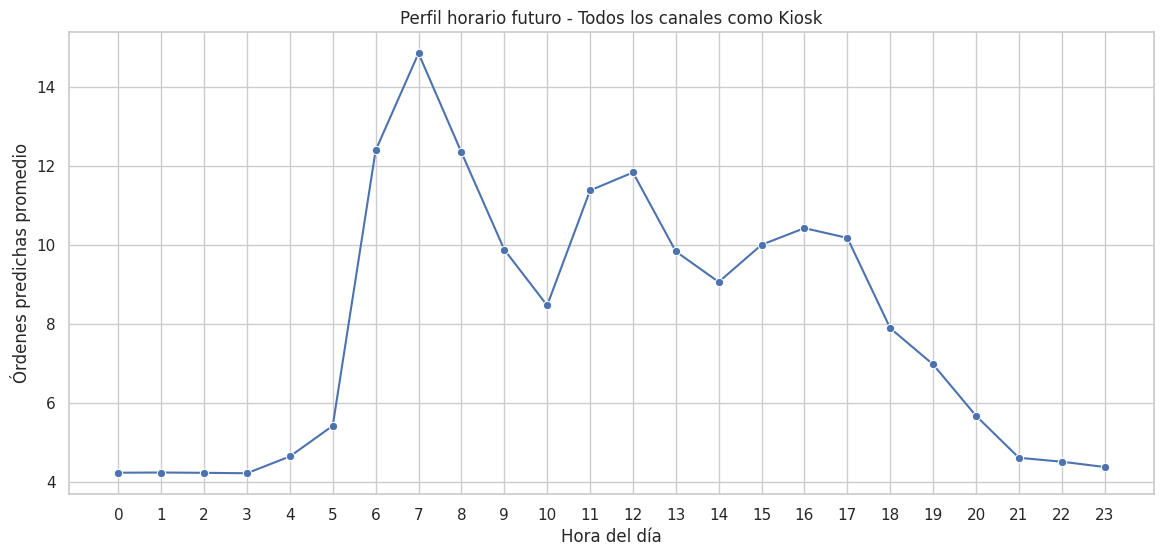

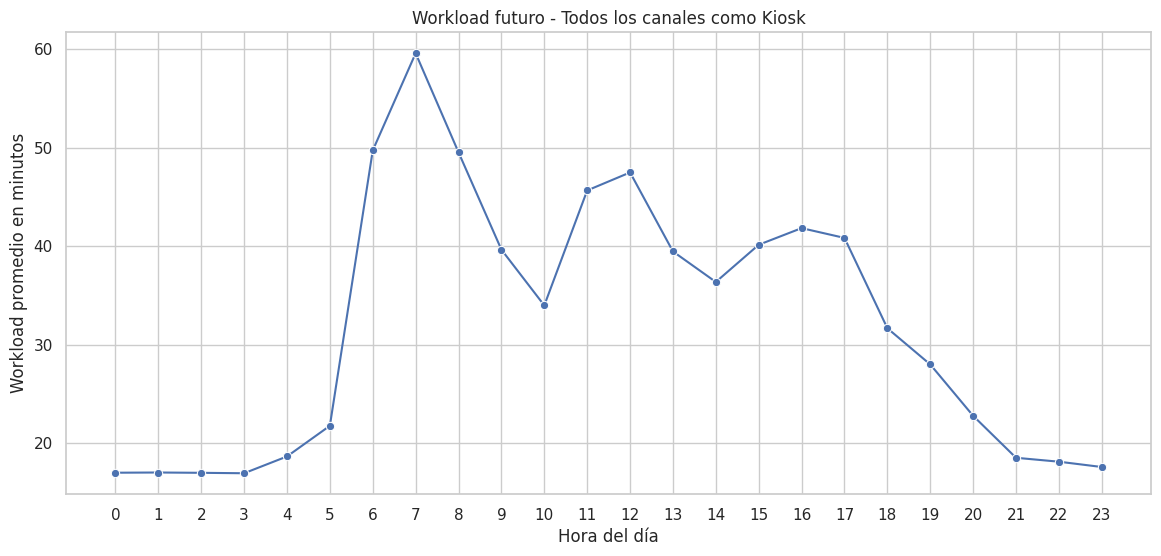

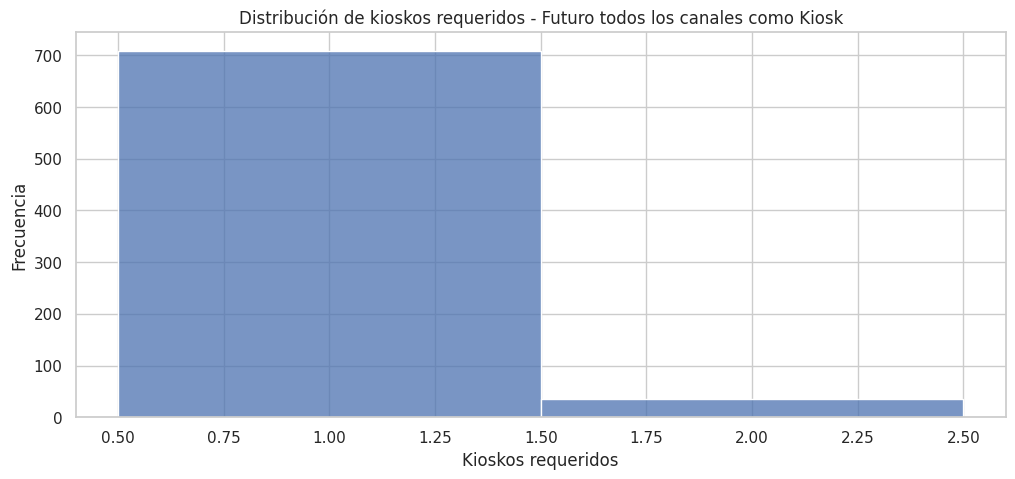

In [28]:
# =========================================================
# 27. PREDICCIÓN FUTURA CORREGIDA - TODOS LOS CANALES COMO KIOSK
# =========================================================

# ---------------------------------------------------------
# 27.1 Crear registros futuros para todos los canales originales
# ---------------------------------------------------------

future_all_channels = ["Kiosk", "In-Store Cashier", "Mobile App", "Drive-Thru"]

future_all_simple = future_calendar.merge(
    pd.DataFrame({"order_channel": future_all_channels}),
    how="cross"
)

print("Dataset futuro para todos los canales:")
print(f"Filas: {future_all_simple.shape[0]:,}")
print(f"Columnas: {future_all_simple.shape[1]:,}")

display(future_all_simple.head())

# ---------------------------------------------------------
# 27.2 Predecir demanda futura por canal usando modelo operativo simple
# ---------------------------------------------------------

X_future_all_simple = future_all_simple[features_future_simple].copy()

future_all_simple["predicted_total_orders"] = (
    best_future_simple_model.predict(X_future_all_simple)
)

future_all_simple["predicted_total_orders"] = np.maximum(
    future_all_simple["predicted_total_orders"],
    0
)

# ---------------------------------------------------------
# 27.3 Simular que todas las órdenes serán atendidas como Kiosk
# ---------------------------------------------------------

# Usamos el tiempo promedio histórico del canal Kiosk como tiempo operativo futuro.
# Esto representa el supuesto: "toda la demanda se atiende bajo lógica de kiosko".

avg_kiosk_time = (
    df_model[df_model["order_channel"] == "Kiosk"]["fulfillment_time_min"]
    .mean()
)

future_all_simple["avg_fulfillment_time_min"] = avg_kiosk_time

# ---------------------------------------------------------
# 27.4 Calcular workload futuro por canal
# ---------------------------------------------------------

future_all_simple["predicted_workload_min"] = (
    future_all_simple["predicted_total_orders"] *
    future_all_simple["avg_fulfillment_time_min"]
)

# ---------------------------------------------------------
# 27.5 Consolidar todos los canales por fecha-hora
# ---------------------------------------------------------

future_all_capacity_simple = (
    future_all_simple
    .groupby([
        "order_date_only",
        "order_year",
        "order_month",
        "order_week",
        "order_day",
        "order_dayofweek_num",
        "order_day_name",
        "is_weekend",
        "order_hour"
    ])
    .agg(
        predicted_total_orders=("predicted_total_orders", "sum"),
        predicted_workload_min=("predicted_workload_min", "sum"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean")
    )
    .reset_index()
)

future_all_capacity_simple["predicted_workload_hours"] = (
    future_all_capacity_simple["predicted_workload_min"] / 60
)

future_all_capacity_simple["required_kiosks_exact"] = (
    future_all_capacity_simple["predicted_workload_min"] /
    effective_capacity_per_kiosk
)

future_all_capacity_simple["required_kiosks"] = np.ceil(
    future_all_capacity_simple["required_kiosks_exact"]
).astype(int)

future_all_capacity_simple["scenario"] = "Futuro todos los canales como Kiosk - Modelo simple"

# ---------------------------------------------------------
# 27.6 Resumen del escenario futuro total
# ---------------------------------------------------------

future_all_summary_simple = (
    future_all_capacity_simple
    .groupby("scenario")
    .agg(
        total_predicted_orders=("predicted_total_orders", "sum"),
        avg_predicted_orders_per_hour=("predicted_total_orders", "mean"),
        p90_predicted_orders_per_hour=("predicted_total_orders", lambda x: x.quantile(0.90)),
        p95_predicted_orders_per_hour=("predicted_total_orders", lambda x: x.quantile(0.95)),
        max_predicted_orders_per_hour=("predicted_total_orders", "max"),
        avg_fulfillment_time_min=("avg_fulfillment_time_min", "mean"),
        total_predicted_workload_min=("predicted_workload_min", "sum"),
        median_required_kiosks=("required_kiosks", "median"),
        p90_required_kiosks=("required_kiosks", lambda x: x.quantile(0.90)),
        p95_required_kiosks=("required_kiosks", lambda x: x.quantile(0.95)),
        max_required_kiosks=("required_kiosks", "max")
    )
    .reset_index()
)

print("Resumen futuro corregido - todos los canales como Kiosk:")
display(future_all_summary_simple)

# ---------------------------------------------------------
# 27.7 Distribución de kioskos requeridos
# ---------------------------------------------------------

future_all_distribution_simple = (
    future_all_capacity_simple
    .groupby("required_kiosks")
    .agg(records=("required_kiosks", "count"))
    .reset_index()
)

future_all_distribution_simple["percentage"] = (
    future_all_distribution_simple["records"] /
    future_all_distribution_simple["records"].sum()
) * 100

print("Distribución futura corregida de kioskos requeridos - todos los canales:")
display(future_all_distribution_simple)

# ---------------------------------------------------------
# 27.8 Top 20 horas futuras con mayor carga
# ---------------------------------------------------------

top_future_all_simple = (
    future_all_capacity_simple
    .sort_values(
        by=["required_kiosks", "predicted_workload_min"],
        ascending=False
    )
    .head(20)
)

print("Top 20 horas futuras corregidas con mayor carga - todos los canales:")
display(top_future_all_simple)

# ---------------------------------------------------------
# 27.9 Perfil horario futuro
# ---------------------------------------------------------

future_all_hourly_profile_simple = (
    future_all_capacity_simple
    .groupby("order_hour")
    .agg(
        avg_predicted_orders=("predicted_total_orders", "mean"),
        avg_predicted_workload_min=("predicted_workload_min", "mean"),
        avg_required_kiosks=("required_kiosks", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=future_all_hourly_profile_simple,
    x="order_hour",
    y="avg_predicted_orders",
    marker="o"
)
plt.title("Perfil horario futuro - Todos los canales como Kiosk")
plt.xlabel("Hora del día")
plt.ylabel("Órdenes predichas promedio")
plt.xticks(range(0, 24))
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=future_all_hourly_profile_simple,
    x="order_hour",
    y="avg_predicted_workload_min",
    marker="o"
)
plt.title("Workload futuro - Todos los canales como Kiosk")
plt.xlabel("Hora del día")
plt.ylabel("Workload promedio en minutos")
plt.xticks(range(0, 24))
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(
    data=future_all_capacity_simple,
    x="required_kiosks",
    discrete=True
)
plt.title("Distribución de kioskos requeridos - Futuro todos los canales como Kiosk")
plt.xlabel("Kioskos requeridos")
plt.ylabel("Frecuencia")
plt.show()

<div class="alert alert-block alert-info">
    <strong>Interpretación del escenario futuro total:</strong> 

En el escenario: Futuro todos los canales como Kiosk - Modelo simple

Resultado principal:

| Métrica                          |         Valor |
| -------------------------------- | ------------: |
| Órdenes futuras estimadas        |      5.938,69 |
| Promedio de órdenes por hora     |          7,98 |
| P95 de órdenes por hora          |         12,59 |
| Máximo de órdenes por hora       |         14,88 |
| Tiempo promedio usado como Kiosk |      4,01 min |
| Workload total estimado          | 23.836,49 min |
| Mediana kioskos requeridos       |             1 |
| P90 kioskos requeridos           |             1 |
| P95 kioskos requeridos           |             1 |
| Máximo kioskos requeridos        |             2 |


La distribución presenta:

| Kioskos requeridos | Registros | Porcentaje |
| -----------------: | --------: | ---------: |
|                  1 |       709 |     95,30% |
|                  2 |        35 |      4,70% |


<div class="alert alert-block alert-info">
    <strong>Conclusión del escenario:</strong>
    
Para enero de 2026, si todas las órdenes futuras de todos los canales fueran atendidas por kiosko, el modelo estima que:

1 kiosko sería suficiente en el 95,30% de las horas.
2 kioskos serían necesarios en el 4,70% de las horas.

El pico principal ocurre nuevamente a las: 7:00 a.m.

En los casos de mayor carga, el modelo predice aproximadamente:

14,88 órdenes por hora
59,73 minutos de workload
1,17 kioskos exactos
2 kioskos requeridos por redondeo operativo

Esto es coherente, porque la carga máxima supera la capacidad efectiva de un kiosko:

Capacidad efectiva de 1 kiosko = 51 minutos/hora
Carga máxima estimada = 59,73 minutos/hora

Por eso el modelo recomienda 2 kioskos en esas horas pico.

</div>

<div class="alert alert-block alert-info">
    <strong>Comparación de los dos escenarios futuros calendarizados:</strong>


| Escenario futuro enero 2026  | Órdenes estimadas | P95 kioskos | Máximo kioskos | Recomendación               |
| ---------------------------- | ----------------: | ----------: | -------------: | --------------------------- |
| Kiosk + In-Store Cashier     |          2.288,74 |           1 |              1 | 1 kiosko                    |
| Todos los canales como Kiosk |          5.938,69 |           1 |              2 | 2 kioskos para cubrir picos |

Para enero de 2026, si solo se considera Kiosk + In-Store Cashier, 1 kiosko sigue siendo suficiente.
Si toda la operación se migra a kioskos, se recomienda considerar 2 kioskos para cubrir los picos de demanda, especialmente a las 7:00 a.m.

Posteriormente, se extendió la predicción calendarizada futura al escenario de migración total, en el cual todas las órdenes futuras, independientemente de su canal original, serían atendidas mediante kioskos. Para este caso se utilizó el modelo operativo simple, basado únicamente en variables conocidas a futuro como mes, día de la semana, fin de semana, hora y canal.

Los resultados para enero de 2026 muestran una demanda estimada de 5.938,69 órdenes, con un promedio de 7,98 órdenes por hora y un máximo de 14,88 órdenes por hora. Al asumir que todas las órdenes se atienden con un tiempo promedio equivalente al canal Kiosk, de 4,01 minutos por orden, la carga máxima estimada alcanza 59,73 minutos por hora.

Dado que la capacidad efectiva definida para un kiosko es de 51 minutos por hora, el modelo indica que 1 kiosko sería suficiente en el 95,30% de los registros horarios, mientras que el 4,70% requeriría 2 kioskos. Por lo tanto, para una migración total de la demanda hacia kioskos, la recomendación operativa es considerar 2 equipos para cubrir adecuadamente los picos de demanda, especialmente en la franja de las 7:00 a.m.

</div>


# 28. TABLA COMPARATIVA FINAL - PREDICCIÓN FUTURA CALENDARIZADA

In [29]:
# =========================================================
# 28. TABLA COMPARATIVA FINAL - PREDICCIÓN FUTURA CALENDARIZADA
# =========================================================

# ---------------------------------------------------------
# 28.1 Preparar resumen futuro Kiosk + In-Store Cashier
# ---------------------------------------------------------

future_focus_summary_table = future_focus_summary_simple.copy()

future_focus_summary_table["method"] = "Predicción futura calendarizada"
future_focus_summary_table["scenario_group"] = future_focus_summary_table["scenario"]

future_focus_summary_table = future_focus_summary_table.rename(columns={
    "total_predicted_orders": "total_orders_estimated",
    "avg_predicted_orders_per_hour": "avg_orders_per_hour",
    "p90_predicted_orders_per_hour": "p90_orders_per_hour",
    "p95_predicted_orders_per_hour": "p95_orders_per_hour",
    "max_predicted_orders_per_hour": "max_orders_per_hour",
    "total_predicted_workload_min": "total_workload_min_estimated",
    "median_required_kiosks": "median_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "max_required_kiosks": "max_kiosks_required"
})

future_focus_summary_table = future_focus_summary_table[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p90_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 28.2 Preparar resumen futuro todos los canales como Kiosk
# ---------------------------------------------------------

future_all_summary_table = future_all_summary_simple.copy()

future_all_summary_table["method"] = "Predicción futura calendarizada"
future_all_summary_table["scenario_group"] = future_all_summary_table["scenario"]

future_all_summary_table = future_all_summary_table.rename(columns={
    "total_predicted_orders": "total_orders_estimated",
    "avg_predicted_orders_per_hour": "avg_orders_per_hour",
    "p90_predicted_orders_per_hour": "p90_orders_per_hour",
    "p95_predicted_orders_per_hour": "p95_orders_per_hour",
    "max_predicted_orders_per_hour": "max_orders_per_hour",
    "total_predicted_workload_min": "total_workload_min_estimated",
    "median_required_kiosks": "median_kiosks_required",
    "p90_required_kiosks": "p90_kiosks_required",
    "p95_required_kiosks": "p95_kiosks_required",
    "max_required_kiosks": "max_kiosks_required"
})

future_all_summary_table = future_all_summary_table[
    [
        "method",
        "scenario_group",
        "total_orders_estimated",
        "avg_orders_per_hour",
        "p90_orders_per_hour",
        "p95_orders_per_hour",
        "max_orders_per_hour",
        "avg_fulfillment_time_min",
        "total_workload_min_estimated",
        "median_kiosks_required",
        "p90_kiosks_required",
        "p95_kiosks_required",
        "max_kiosks_required"
    ]
]

# ---------------------------------------------------------
# 28.3 Unificar tabla futura
# ---------------------------------------------------------

future_calendarized_comparison = pd.concat(
    [
        future_focus_summary_table,
        future_all_summary_table
    ],
    ignore_index=True
)

# ---------------------------------------------------------
# 28.4 Redondear columnas numéricas
# ---------------------------------------------------------

numeric_cols_future = future_calendarized_comparison.select_dtypes(
    include=["float64", "int64"]
).columns

future_calendarized_comparison[numeric_cols_future] = (
    future_calendarized_comparison[numeric_cols_future].round(4)
)

print("Tabla comparativa final - predicción futura calendarizada:")
display(future_calendarized_comparison)

# ---------------------------------------------------------
# 28.5 Exportar tabla futura
# ---------------------------------------------------------

output_future_path = "tabla_prediccion_futura_calendarizada_kioskos.csv"

future_calendarized_comparison.to_csv(
    output_future_path,
    index=False
)

print(f"Tabla futura exportada como: {output_future_path}")

Tabla comparativa final - predicción futura calendarizada:


,method,scenario_group,total_orders_estimated,avg_orders_per_hour,p90_orders_per_hour,p95_orders_per_hour,max_orders_per_hour,avg_fulfillment_time_min,total_workload_min_estimated,median_kiosks_required,p90_kiosks_required,p95_kiosks_required,max_kiosks_required
0,Predicción futura calendarizada,Futuro Kiosk + In-Store Cashier - Modelo simple,"2,288.7373",3.0763,4.1340,4.1904,4.7617,3.6088,"8,090.5921",1.0000,1.0000,1.0000,1
1,Predicción futura calendarizada,Futuro todos los canales como Kiosk - Modelo s...,"5,938.6931",7.9821,12.2025,12.5861,14.8817,4.0138,"23,836.4896",1.0000,1.0000,1.0000,2


Tabla futura exportada como: tabla_prediccion_futura_calendarizada_kioskos.csv
